In [53]:
# ============================================================
# Cell 1: Mount Google Drive and define the project root
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

# Change this only if you want a different location in Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/EEG_ML_Final_Project")

CACHE_DIR = PROJECT_ROOT / "cache"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
SUMMARY_DIR = PROJECT_ROOT / "summary"
FIGURES_DIR = PROJECT_ROOT / "figures"

for d in [PROJECT_ROOT, CACHE_DIR, EXPERIMENTS_DIR, SUMMARY_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cache dir:", CACHE_DIR)
print("Experiments dir:", EXPERIMENTS_DIR)
print("Summary dir:", SUMMARY_DIR)
print("Figures dir:", FIGURES_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/EEG_ML_Final_Project
Cache dir: /content/drive/MyDrive/EEG_ML_Final_Project/cache
Experiments dir: /content/drive/MyDrive/EEG_ML_Final_Project/experiments
Summary dir: /content/drive/MyDrive/EEG_ML_Final_Project/summary
Figures dir: /content/drive/MyDrive/EEG_ML_Final_Project/figures


In [54]:
# ============================================================
# Cell 2: Imports, reproducibility, and global constants
# ============================================================

import json
import time
import random
import shutil
import tempfile
from pathlib import Path
from datetime import datetime ,timezone
from typing import Dict, Any, List, Optional

import numpy as np
import pandas as pd
import joblib

# Optional torch import for deep learning experiments
try:
    import torch
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

RANDOM_SEED = 42

def set_global_seed(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)

    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # More reproducible, sometimes a bit slower
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_global_seed(RANDOM_SEED)

# Dataset constants
FS = 250
WINDOW_SEC = 4
WINDOW_SAMPLES = FS * WINDOW_SEC
OVERLAP = 0.5
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP))

N_CHANNELS = 63
N_BANDS = 4
BANDPOWER_FEATURE_DIM = N_CHANNELS * N_BANDS

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}

print("Seed set to:", RANDOM_SEED)
print("Window samples:", WINDOW_SAMPLES)
print("Step samples:", STEP_SAMPLES)
print("Torch available:", TORCH_AVAILABLE)

Seed set to: 42
Window samples: 1000
Step samples: 500
Torch available: True


In [55]:
# ============================================================
# Cell 3: Cache file definitions and master experiment list
# ============================================================

CACHE_FILES = {
    "design_windows": CACHE_DIR / "design_windows.npz",
    "design_bandpower": CACHE_DIR / "design_bandpower.npz",
    "creativity_windows": CACHE_DIR / "creativity_windows.npz",
    "creativity_bandpower": CACHE_DIR / "creativity_bandpower.npz",
}

MASTER_EXPERIMENTS: List[Dict[str, Any]] = [
    # -------------------------
    # Design
    # -------------------------
    {
        "experiment_name": "design_within_linear_svm",
        "dataset_group": "design",
        "protocol": "within_subject",
        "model_family": "linear_svm",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "design_within_logreg",
        "dataset_group": "design",
        "protocol": "within_subject",
        "model_family": "logreg",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "design_within_rbf_svm",
        "dataset_group": "design",
        "protocol": "within_subject",
        "model_family": "rbf_svm",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "design_within_eegnet",
        "dataset_group": "design",
        "protocol": "within_subject",
        "model_family": "eegnet",
        "input_type": "raw_windows",
    },
    {
        "experiment_name": "design_cross_logreg",
        "dataset_group": "design",
        "protocol": "cross_subject",
        "model_family": "logreg",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "design_cross_eegnet",
        "dataset_group": "creativity",
        "protocol": "cross_subject",
        "model_family": "eegnet",
        "input_type": "raw_windows",
    },

    # -------------------------
    # Creativity
    # -------------------------
    {
        "experiment_name": "creativity_within_rbf_svm",
        "dataset_group": "creativity",
        "protocol": "within_subject",
        "model_family": "rbf_svm",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "creativity_within_linear_svm",
        "dataset_group": "creativity",
        "protocol": "within_subject",
        "model_family": "linear_svm",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "creativity_within_logreg",
        "dataset_group": "creativity",
        "protocol": "within_subject",
        "model_family": "logreg",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "creativity_within_eegnet",
        "dataset_group": "creativity",
        "protocol": "within_subject",
        "model_family": "eegnet",
        "input_type": "raw_windows",
    },
    {
        "experiment_name": "creativity_cross_logreg",
        "dataset_group": "creativity",
        "protocol": "cross_subject",
        "model_family": "logreg",
        "input_type": "bandpower",
    },
    {
        "experiment_name": "creativity_cross_eegnet",
        "dataset_group": "creativity",
        "protocol": "cross_subject",
        "model_family": "eegnet",
        "input_type": "raw_windows",
    },
]

MASTER_EXPERIMENT_NAMES = [x["experiment_name"] for x in MASTER_EXPERIMENTS]

print("Number of tracked experiments:", len(MASTER_EXPERIMENTS))
print(pd.DataFrame(MASTER_EXPERIMENTS))
print("\nCache files:")
for k, v in CACHE_FILES.items():
    print(f"{k}: {v}")

Number of tracked experiments: 12
                 experiment_name dataset_group        protocol model_family  \
0       design_within_linear_svm        design  within_subject   linear_svm   
1           design_within_logreg        design  within_subject       logreg   
2          design_within_rbf_svm        design  within_subject      rbf_svm   
3           design_within_eegnet        design  within_subject       eegnet   
4            design_cross_logreg        design   cross_subject       logreg   
5            design_cross_eegnet    creativity   cross_subject       eegnet   
6      creativity_within_rbf_svm    creativity  within_subject      rbf_svm   
7   creativity_within_linear_svm    creativity  within_subject   linear_svm   
8       creativity_within_logreg    creativity  within_subject       logreg   
9       creativity_within_eegnet    creativity  within_subject       eegnet   
10       creativity_cross_logreg    creativity   cross_subject       logreg   
11       creativit

In [56]:
# ============================================================
# Cell 4: Atomic save/load helpers
# ============================================================

def utc_now_str() -> str:
    return datetime.now(timezone.utc).isoformat(timespec="seconds").replace("+00:00", "Z")


def ensure_parent(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)


def atomic_write_text(path: Path, text: str):
    ensure_parent(path)
    with tempfile.NamedTemporaryFile("w", delete=False, dir=path.parent, encoding="utf-8") as tmp:
        tmp.write(text)
        tmp_path = Path(tmp.name)
    tmp_path.replace(path)


def atomic_write_json(path: Path, obj: Any, indent: int = 2):
    text = json.dumps(obj, indent=indent, ensure_ascii=False)
    atomic_write_text(path, text)


def atomic_save_npy(path: Path, array: np.ndarray):
    ensure_parent(path)
    with tempfile.NamedTemporaryFile(delete=False, dir=path.parent, suffix=".npy") as tmp:
        tmp_path = Path(tmp.name)
    np.save(tmp_path, array)
    tmp_path.replace(path)


def atomic_save_npz(path: Path, **arrays):
    ensure_parent(path)
    with tempfile.NamedTemporaryFile(delete=False, dir=path.parent, suffix=".npz") as tmp:
        tmp_path = Path(tmp.name)
    np.savez_compressed(tmp_path, **arrays)
    tmp_path.replace(path)


def atomic_joblib_dump(path: Path, obj: Any):
    ensure_parent(path)
    with tempfile.NamedTemporaryFile(delete=False, dir=path.parent, suffix=".joblib") as tmp:
        tmp_path = Path(tmp.name)
    joblib.dump(obj, tmp_path)
    tmp_path.replace(path)


def atomic_torch_save(path: Path, obj: Any):
    if not TORCH_AVAILABLE:
        raise RuntimeError("Torch is not available, cannot save torch object.")
    ensure_parent(path)
    with tempfile.NamedTemporaryFile(delete=False, dir=path.parent, suffix=".pt") as tmp:
        tmp_path = Path(tmp.name)
    torch.save(obj, tmp_path)
    tmp_path.replace(path)


def read_json(path: Path, default=None):
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def append_jsonl(path: Path, record: Dict[str, Any]):
    ensure_parent(path)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")


def safe_remove(path: Path):
    if path.exists():
        if path.is_dir():
            shutil.rmtree(path)
        else:
            path.unlink()


print("Atomic save/load helpers are ready.")

Atomic save/load helpers are ready.


In [57]:
# ============================================================
# Cell 5: Experiment folder API and completion rules
# ============================================================

REGISTRY_JSONL = SUMMARY_DIR / "experiment_registry.jsonl"
REGISTRY_CSV = SUMMARY_DIR / "experiment_registry.csv"
FINAL_RESULTS_CSV = SUMMARY_DIR / "final_results_table.csv"

COMMON_REQUIRED_FILES = [
    "metrics.json",
    "config.json",
    "notes.json",
    "confusion_matrix.npy",
    "predictions.npz",
    "history.json",
]

SKLEARN_MODEL_FILE = "model.joblib"
TORCH_MODEL_FILE = "model_state_dict.pt"
TORCH_OPTIMIZER_FILE = "optimizer_state_dict.pt"
DONE_MARKER_FILE = "_DONE"
FAILED_MARKER_FILE = "_FAILED"
RUNNING_MARKER_FILE = "_RUNNING"


def get_experiment_dir(experiment_name: str) -> Path:
    return EXPERIMENTS_DIR / experiment_name


def get_experiment_paths(experiment_name: str) -> Dict[str, Path]:
    exp_dir = get_experiment_dir(experiment_name)
    return {
        "dir": exp_dir,
        "metrics": exp_dir / "metrics.json",
        "config": exp_dir / "config.json",
        "notes": exp_dir / "notes.json",
        "confusion_matrix": exp_dir / "confusion_matrix.npy",
        "predictions": exp_dir / "predictions.npz",
        "history": exp_dir / "history.json",
        "model_joblib": exp_dir / SKLEARN_MODEL_FILE,
        "model_state_dict": exp_dir / TORCH_MODEL_FILE,
        "optimizer_state_dict": exp_dir / TORCH_OPTIMIZER_FILE,
        "done": exp_dir / DONE_MARKER_FILE,
        "failed": exp_dir / FAILED_MARKER_FILE,
        "running": exp_dir / RUNNING_MARKER_FILE,
    }


def experiment_has_required_common_files(experiment_name: str) -> bool:
    paths = get_experiment_paths(experiment_name)
    return all((paths["dir"] / fname).exists() for fname in COMMON_REQUIRED_FILES)


def experiment_has_model_file(experiment_name: str) -> bool:
    paths = get_experiment_paths(experiment_name)
    return paths["model_joblib"].exists() or paths["model_state_dict"].exists()


def experiment_is_complete(experiment_name: str) -> bool:
    paths = get_experiment_paths(experiment_name)
    return (
        paths["done"].exists()
        and experiment_has_required_common_files(experiment_name)
        and experiment_has_model_file(experiment_name)
    )


def experiment_status(experiment_name: str) -> str:
    paths = get_experiment_paths(experiment_name)

    if experiment_is_complete(experiment_name):
        return "completed"

    if paths["failed"].exists():
        return "failed"

    if paths["running"].exists():
        return "running_incomplete"

    if paths["dir"].exists():
        existing_files = list(paths["dir"].glob("*"))
        if len(existing_files) > 0:
            return "partial"

    return "not_started"


def mark_running(experiment_name: str):
    paths = get_experiment_paths(experiment_name)
    paths["dir"].mkdir(parents=True, exist_ok=True)
    atomic_write_text(paths["running"], utc_now_str())


def clear_running_marker(experiment_name: str):
    paths = get_experiment_paths(experiment_name)
    safe_remove(paths["running"])


def mark_failed(experiment_name: str, error_message: str):
    paths = get_experiment_paths(experiment_name)
    atomic_write_text(paths["failed"], error_message)


def clear_failed_marker(experiment_name: str):
    paths = get_experiment_paths(experiment_name)
    safe_remove(paths["failed"])


def mark_done(experiment_name: str):
    paths = get_experiment_paths(experiment_name)
    atomic_write_text(paths["done"], utc_now_str())


def reset_experiment_folder(experiment_name: str):
    exp_dir = get_experiment_dir(experiment_name)
    safe_remove(exp_dir)
    exp_dir.mkdir(parents=True, exist_ok=True)


print("Experiment folder API is ready.")

Experiment folder API is ready.


In [58]:
# ============================================================
# Cell 6: Standardized artifact saving functions
# ============================================================

def save_experiment_metadata(
    experiment_name: str,
    config: Dict[str, Any],
    metrics: Dict[str, Any],
    notes: Optional[Dict[str, Any]] = None,
    history: Optional[Dict[str, Any]] = None,
):
    paths = get_experiment_paths(experiment_name)
    paths["dir"].mkdir(parents=True, exist_ok=True)

    if notes is None:
        notes = {}
    if history is None:
        history = {}

    config = dict(config)
    metrics = dict(metrics)
    notes = dict(notes)
    history = dict(history)

    config["saved_at_utc"] = utc_now_str()
    metrics["saved_at_utc"] = utc_now_str()
    notes["saved_at_utc"] = utc_now_str()
    history["saved_at_utc"] = utc_now_str()

    atomic_write_json(paths["config"], config)
    atomic_write_json(paths["metrics"], metrics)
    atomic_write_json(paths["notes"], notes)
    atomic_write_json(paths["history"], history)


def save_experiment_predictions(
    experiment_name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    **extra_arrays
):
    paths = get_experiment_paths(experiment_name)
    arrays = {
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
    }
    for k, v in extra_arrays.items():
        arrays[k] = np.asarray(v)
    atomic_save_npz(paths["predictions"], **arrays)


def save_experiment_confusion_matrix(
    experiment_name: str,
    confusion_matrix_array: np.ndarray
):
    paths = get_experiment_paths(experiment_name)
    atomic_save_npy(paths["confusion_matrix"], np.asarray(confusion_matrix_array))


def save_sklearn_model(
    experiment_name: str,
    model
):
    paths = get_experiment_paths(experiment_name)
    atomic_joblib_dump(paths["model_joblib"], model)


def save_torch_model_artifacts(
    experiment_name: str,
    model,
    optimizer=None,
    extra_checkpoint: Optional[Dict[str, Any]] = None,
    checkpoint_name: Optional[str] = None,
):
    if not TORCH_AVAILABLE:
        raise RuntimeError("Torch is not available.")

    paths = get_experiment_paths(experiment_name)

    atomic_torch_save(paths["model_state_dict"], model.state_dict())

    if optimizer is not None:
        atomic_torch_save(paths["optimizer_state_dict"], optimizer.state_dict())

    if extra_checkpoint is not None and checkpoint_name is not None:
        checkpoint_path = paths["dir"] / checkpoint_name
        atomic_torch_save(checkpoint_path, extra_checkpoint)


def save_epoch_checkpoint(
    experiment_name: str,
    epoch: int,
    model,
    optimizer=None,
    history: Optional[Dict[str, Any]] = None,
    extra_payload: Optional[Dict[str, Any]] = None,
):
    if not TORCH_AVAILABLE:
        raise RuntimeError("Torch is not available.")

    payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "saved_at_utc": utc_now_str(),
    }

    if optimizer is not None:
        payload["optimizer_state_dict"] = optimizer.state_dict()

    if history is not None:
        payload["history"] = history

    if extra_payload is not None:
        payload.update(extra_payload)

    checkpoint_name = f"checkpoint_epoch_{epoch:03d}.pt"
    checkpoint_path = get_experiment_dir(experiment_name) / checkpoint_name
    atomic_torch_save(checkpoint_path, payload)


def finalize_experiment(
    experiment_name: str,
    config: Dict[str, Any],
    metrics: Dict[str, Any],
    notes: Dict[str, Any],
    history: Dict[str, Any],
    confusion_matrix_array: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sklearn_model=None,
    torch_model=None,
    torch_optimizer=None,
    extra_prediction_arrays: Optional[Dict[str, np.ndarray]] = None,
):
    if extra_prediction_arrays is None:
        extra_prediction_arrays = {}

    save_experiment_metadata(
        experiment_name=experiment_name,
        config=config,
        metrics=metrics,
        notes=notes,
        history=history,
    )

    save_experiment_confusion_matrix(experiment_name, confusion_matrix_array)

    save_experiment_predictions(
        experiment_name=experiment_name,
        y_true=y_true,
        y_pred=y_pred,
        **extra_prediction_arrays
    )

    if sklearn_model is not None:
        save_sklearn_model(experiment_name, sklearn_model)

    if torch_model is not None:
        save_torch_model_artifacts(
            experiment_name=experiment_name,
            model=torch_model,
            optimizer=torch_optimizer
        )

    if not experiment_has_required_common_files(experiment_name):
        raise RuntimeError(f"Experiment {experiment_name} is missing required files after saving.")

    if not experiment_has_model_file(experiment_name):
        raise RuntimeError(f"Experiment {experiment_name} has no saved model file after saving.")

    clear_failed_marker(experiment_name)
    clear_running_marker(experiment_name)
    mark_done(experiment_name)


print("Standardized artifact saving functions are ready.")

Standardized artifact saving functions are ready.


In [59]:
# ============================================================
# Cell 7: Registry logging and status scanner
# ============================================================

def log_registry_event(
    experiment_name: str,
    event_type: str,
    status: str,
    extra: Optional[Dict[str, Any]] = None
):
    if extra is None:
        extra = {}

    master_row = next((x for x in MASTER_EXPERIMENTS if x["experiment_name"] == experiment_name), None)
    if master_row is None:
        raise ValueError(f"Unknown experiment_name: {experiment_name}")

    record = {
        "timestamp_utc": utc_now_str(),
        "experiment_name": experiment_name,
        "event_type": event_type,      # e.g. started, skipped, completed, failed, scanned
        "status": status,              # e.g. completed, partial, failed, not_started
        "dataset_group": master_row["dataset_group"],
        "protocol": master_row["protocol"],
        "model_family": master_row["model_family"],
        "input_type": master_row["input_type"],
    }
    record.update(extra)

    append_jsonl(REGISTRY_JSONL, record)


def build_registry_csv_from_jsonl() -> pd.DataFrame:
    if not REGISTRY_JSONL.exists():
        df = pd.DataFrame(columns=[
            "timestamp_utc", "experiment_name", "event_type", "status",
            "dataset_group", "protocol", "model_family", "input_type"
        ])
        df.to_csv(REGISTRY_CSV, index=False)
        return df

    rows = []
    with open(REGISTRY_JSONL, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))

    df = pd.DataFrame(rows)
    df.to_csv(REGISTRY_CSV, index=False)
    return df


def scan_experiment_status() -> pd.DataFrame:
    rows = []
    for exp in MASTER_EXPERIMENTS:
        name = exp["experiment_name"]
        status = experiment_status(name)
        row = dict(exp)
        row["status"] = status
        row["experiment_dir"] = str(get_experiment_dir(name))
        row["has_done_marker"] = get_experiment_paths(name)["done"].exists()
        row["has_failed_marker"] = get_experiment_paths(name)["failed"].exists()
        row["has_running_marker"] = get_experiment_paths(name)["running"].exists()
        row["has_metrics"] = get_experiment_paths(name)["metrics"].exists()
        row["has_config"] = get_experiment_paths(name)["config"].exists()
        row["has_notes"] = get_experiment_paths(name)["notes"].exists()
        row["has_history"] = get_experiment_paths(name)["history"].exists()
        row["has_predictions"] = get_experiment_paths(name)["predictions"].exists()
        row["has_confusion_matrix"] = get_experiment_paths(name)["confusion_matrix"].exists()
        row["has_model_joblib"] = get_experiment_paths(name)["model_joblib"].exists()
        row["has_model_state_dict"] = get_experiment_paths(name)["model_state_dict"].exists()
        rows.append(row)

        log_registry_event(
            experiment_name=name,
            event_type="scanned",
            status=status
        )

    df = pd.DataFrame(rows)
    return df


def get_missing_experiments() -> List[str]:
    return [
        exp["experiment_name"]
        for exp in MASTER_EXPERIMENTS
        if experiment_status(exp["experiment_name"]) != "completed"
    ]


def get_completed_experiments() -> List[str]:
    return [
        exp["experiment_name"]
        for exp in MASTER_EXPERIMENTS
        if experiment_status(exp["experiment_name"]) == "completed"
    ]


status_df = scan_experiment_status()
registry_df = build_registry_csv_from_jsonl()

print("Completed:", (status_df["status"] == "completed").sum())
print("Missing:", (status_df["status"] != "completed").sum())
display(status_df[[
    "experiment_name", "dataset_group", "protocol", "model_family", "input_type", "status"
]].sort_values(["dataset_group", "protocol", "experiment_name"]).reset_index(drop=True))

Completed: 9
Missing: 3


,experiment_name,dataset_group,protocol,model_family,input_type,status
0,creativity_cross_eegnet,creativity,cross_subject,eegnet,raw_windows,partial
1,creativity_cross_logreg,creativity,cross_subject,logreg,bandpower,completed
2,design_cross_eegnet,creativity,cross_subject,eegnet,raw_windows,running_incomplete
3,creativity_within_eegnet,creativity,within_subject,eegnet,raw_windows,partial
4,creativity_within_linear_svm,creativity,within_subject,linear_svm,bandpower,completed
5,creativity_within_logreg,creativity,within_subject,logreg,bandpower,completed
6,creativity_within_rbf_svm,creativity,within_subject,rbf_svm,bandpower,completed
7,design_cross_logreg,design,cross_subject,logreg,bandpower,completed
8,design_within_eegnet,design,within_subject,eegnet,raw_windows,completed
9,design_within_linear_svm,design,within_subject,linear_svm,bandpower,completed


In [60]:
# ============================================================
# Cell 8: Safe experiment runner wrapper
# ============================================================

def run_experiment_if_needed(
    experiment_name: str,
    run_fn,
    force_rerun: bool = False
):
    """
    Generic safe wrapper.

    Parameters
    ----------
    experiment_name : str
        Name from MASTER_EXPERIMENTS.
    run_fn : callable
        Function with signature:
            result = run_fn(experiment_name)
        It must return a dictionary with the keys needed by finalize_experiment().
    force_rerun : bool
        If True, delete the experiment folder and run again.
    """

    current_status = experiment_status(experiment_name)

    if current_status == "completed" and not force_rerun:
        print(f"[SKIP] {experiment_name} is already completed.")
        log_registry_event(
            experiment_name=experiment_name,
            event_type="skipped",
            status="completed",
            extra={"reason": "already_completed"}
        )
        return "skipped"

    if force_rerun:
        print(f"[RESET] Removing previous folder for {experiment_name}")
        reset_experiment_folder(experiment_name)

    print(f"[START] {experiment_name}")
    mark_running(experiment_name)
    clear_failed_marker(experiment_name)

    log_registry_event(
        experiment_name=experiment_name,
        event_type="started",
        status="running"
    )

    start_time = time.time()

    try:
        result = run_fn(experiment_name)

        required_keys = [
            "config",
            "metrics",
            "notes",
            "history",
            "confusion_matrix_array",
            "y_true",
            "y_pred",
        ]
        for key in required_keys:
            if key not in result:
                raise KeyError(f"run_fn result is missing required key: {key}")

        finalize_experiment(
            experiment_name=experiment_name,
            config=result["config"],
            metrics=result["metrics"],
            notes=result["notes"],
            history=result["history"],
            confusion_matrix_array=result["confusion_matrix_array"],
            y_true=result["y_true"],
            y_pred=result["y_pred"],
            sklearn_model=result.get("sklearn_model", None),
            torch_model=result.get("torch_model", None),
            torch_optimizer=result.get("torch_optimizer", None),
            extra_prediction_arrays=result.get("extra_prediction_arrays", None),
        )

        elapsed_sec = time.time() - start_time
        log_registry_event(
            experiment_name=experiment_name,
            event_type="completed",
            status="completed",
            extra={"elapsed_sec": round(elapsed_sec, 3)}
        )

        print(f"[DONE] {experiment_name} | elapsed_sec={elapsed_sec:.2f}")
        return "completed"

    except Exception as e:
        clear_running_marker(experiment_name)
        mark_failed(experiment_name, str(e))

        elapsed_sec = time.time() - start_time
        log_registry_event(
            experiment_name=experiment_name,
            event_type="failed",
            status="failed",
            extra={
                "elapsed_sec": round(elapsed_sec, 3),
                "error_message": str(e)
            }
        )

        print(f"[FAILED] {experiment_name}: {e}")
        raise

In [61]:
# ============================================================
# Cell 9: Cache status checker and cache manifest helpers
# ============================================================

CACHE_MANIFEST = CACHE_DIR / "cache_manifest.json"

def cache_exists(cache_key: str) -> bool:
    if cache_key not in CACHE_FILES:
        raise KeyError(f"Unknown cache key: {cache_key}")
    return CACHE_FILES[cache_key].exists()


def cache_status_dataframe() -> pd.DataFrame:
    rows = []
    for cache_key, cache_path in CACHE_FILES.items():
        rows.append({
            "cache_key": cache_key,
            "path": str(cache_path),
            "exists": cache_path.exists(),
            "size_mb": round(cache_path.stat().st_size / (1024 ** 2), 3) if cache_path.exists() else None,
        })
    return pd.DataFrame(rows)


def write_cache_manifest(extra: Optional[Dict[str, Any]] = None):
    if extra is None:
        extra = {}

    manifest = {
        "saved_at_utc": utc_now_str(),
        "random_seed": RANDOM_SEED,
        "fs": FS,
        "window_sec": WINDOW_SEC,
        "window_samples": WINDOW_SAMPLES,
        "overlap": OVERLAP,
        "step_samples": STEP_SAMPLES,
        "n_channels": N_CHANNELS,
        "bands": BANDS,
        "cache_files": {k: str(v) for k, v in CACHE_FILES.items()},
    }
    manifest.update(extra)

    atomic_write_json(CACHE_MANIFEST, manifest)


write_cache_manifest()

cache_df = cache_status_dataframe()
display(cache_df)

,cache_key,path,exists,size_mb
0,design_windows,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,7844.716
1,design_bandpower,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,30.013
2,creativity_windows,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,3159.996
3,creativity_bandpower,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,12.079


In [10]:
# ============================================================
# Cell 10: Final results table builder
# ============================================================

def collect_completed_experiment_rows() -> List[Dict[str, Any]]:
    rows = []

    for exp in MASTER_EXPERIMENTS:
        experiment_name = exp["experiment_name"]

        if not experiment_is_complete(experiment_name):
            continue

        paths = get_experiment_paths(experiment_name)
        metrics = read_json(paths["metrics"], default={})
        config = read_json(paths["config"], default={})
        notes = read_json(paths["notes"], default={})
        history = read_json(paths["history"], default={})

        row = dict(exp)
        row["status"] = "completed"

        # Common metrics
        row["balanced_accuracy"] = metrics.get("balanced_accuracy")
        row["accuracy"] = metrics.get("accuracy")
        row["macro_f1"] = metrics.get("macro_f1")

        # Optional metadata
        row["n_train"] = metrics.get("n_train", config.get("n_train"))
        row["n_test"] = metrics.get("n_test", config.get("n_test"))
        row["best_params"] = json.dumps(metrics.get("best_params", config.get("best_params", {})), ensure_ascii=False)
        row["train_time_sec"] = metrics.get("train_time_sec", notes.get("train_time_sec"))
        row["inference_time_sec"] = metrics.get("inference_time_sec", notes.get("inference_time_sec"))
        row["history_summary"] = json.dumps(history, ensure_ascii=False)

        rows.append(row)

    return rows


def build_final_results_table() -> pd.DataFrame:
    rows = collect_completed_experiment_rows()
    df = pd.DataFrame(rows)

    if len(df) == 0:
        df = pd.DataFrame(columns=[
            "experiment_name", "dataset_group", "protocol", "model_family", "input_type",
            "status", "balanced_accuracy", "accuracy", "macro_f1",
            "n_train", "n_test", "best_params", "train_time_sec", "inference_time_sec"
        ])

    sort_cols = [c for c in ["dataset_group", "protocol", "balanced_accuracy"] if c in df.columns]
    ascending = [True, True, False][:len(sort_cols)]

    if len(sort_cols) > 0 and len(df) > 0:
        df = df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

    df.to_csv(FINAL_RESULTS_CSV, index=False)
    return df


final_results_df = build_final_results_table()
display(final_results_df)
print("Saved final results table to:", FINAL_RESULTS_CSV)

,experiment_name,dataset_group,protocol,model_family,input_type,status,balanced_accuracy,accuracy,macro_f1,n_train,n_test,best_params,train_time_sec,inference_time_sec,history_summary
0,creativity_cross_logreg,creativity,cross_subject,logreg,bandpower,completed,0.558001,0.715815,0.560121,14202,14202,"{""clf__C"": 0.1}",584.467,None,"{""fold_rows"": [{""test_subject"": ""creativity_01..."
1,creativity_within_logreg,creativity,within_subject,logreg,bandpower,completed,0.536606,0.702718,0.536322,14202,14202,"{""clf__C"": 0.01}",130.261,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
2,creativity_within_linear_svm,creativity,within_subject,linear_svm,bandpower,completed,0.526377,0.702507,0.523941,14202,14202,"{""clf__C"": 0.01}",103.021,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
3,creativity_within_rbf_svm,creativity,within_subject,rbf_svm,bandpower,completed,0.469059,0.645050,0.460178,14202,14202,"{""clf__C"": 1, ""clf__gamma"": 0.0001}",853.267,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
4,design_cross_logreg,design,cross_subject,logreg,bandpower,completed,0.689227,0.661615,0.681633,35235,35235,"{""clf__C"": 0.1}",3950.397,None,"{""fold_rows"": [{""test_subject"": ""design_01"", ""..."
5,design_within_logreg,design,within_subject,logreg,bandpower,completed,0.757615,0.746303,0.759418,35235,35235,"{""clf__C"": 0.01}",525.752,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
6,design_within_linear_svm,design,within_subject,linear_svm,bandpower,completed,0.728140,0.736257,0.750861,35235,35235,"{""clf__C"": 0.01}",281.482,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
7,design_within_rbf_svm,design,within_subject,rbf_svm,bandpower,completed,0.709048,0.718206,0.732480,35235,35235,"{""clf__C"": 10, ""clf__gamma"": 0.0001}",5816.158,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
8,design_within_eegnet,design,within_subject,eegnet,raw_windows,completed,0.530538,0.581240,0.516541,35235,35235,{},682.808,None,"{""fold_rows"": [{""subject_id"": ""1"", ""outer_fold..."


Saved final results table to: /content/drive/MyDrive/EEG_ML_Final_Project/summary/final_results_table.csv


In [62]:
# ============================================================
# Cell 11: Summary dashboard cell
# ============================================================

status_df = scan_experiment_status()
registry_df = build_registry_csv_from_jsonl()
final_results_df = build_final_results_table()
cache_df = cache_status_dataframe()

print("=" * 70)
print("CACHE STATUS")
print("=" * 70)
display(cache_df)

print("=" * 70)
print("EXPERIMENT STATUS")
print("=" * 70)
display(
    status_df[[
        "experiment_name",
        "dataset_group",
        "protocol",
        "model_family",
        "input_type",
        "status"
    ]]
    .sort_values(["dataset_group", "protocol", "experiment_name"])
    .reset_index(drop=True)
)

print("=" * 70)
print("COUNTS")
print("=" * 70)
print(status_df["status"].value_counts(dropna=False))

print("=" * 70)
print("COMPLETED RESULTS")
print("=" * 70)
display(final_results_df)

print("=" * 70)
print("MISSING EXPERIMENTS")
print("=" * 70)
missing_experiments = get_missing_experiments()
for name in missing_experiments:
    print(name)

CACHE STATUS


,cache_key,path,exists,size_mb
0,design_windows,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,7844.716
1,design_bandpower,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,30.013
2,creativity_windows,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,3159.996
3,creativity_bandpower,/content/drive/MyDrive/EEG_ML_Final_Project/ca...,True,12.079


EXPERIMENT STATUS


,experiment_name,dataset_group,protocol,model_family,input_type,status
0,creativity_cross_eegnet,creativity,cross_subject,eegnet,raw_windows,partial
1,creativity_cross_logreg,creativity,cross_subject,logreg,bandpower,completed
2,design_cross_eegnet,creativity,cross_subject,eegnet,raw_windows,running_incomplete
3,creativity_within_eegnet,creativity,within_subject,eegnet,raw_windows,partial
4,creativity_within_linear_svm,creativity,within_subject,linear_svm,bandpower,completed
5,creativity_within_logreg,creativity,within_subject,logreg,bandpower,completed
6,creativity_within_rbf_svm,creativity,within_subject,rbf_svm,bandpower,completed
7,design_cross_logreg,design,cross_subject,logreg,bandpower,completed
8,design_within_eegnet,design,within_subject,eegnet,raw_windows,completed
9,design_within_linear_svm,design,within_subject,linear_svm,bandpower,completed


COUNTS
status
completed             9
partial               2
running_incomplete    1
Name: count, dtype: int64
COMPLETED RESULTS


,experiment_name,dataset_group,protocol,model_family,input_type,status,balanced_accuracy,accuracy,macro_f1,n_train,n_test,best_params,train_time_sec,inference_time_sec,history_summary
0,creativity_cross_logreg,creativity,cross_subject,logreg,bandpower,completed,0.558001,0.715815,0.560121,14202,14202,"{""clf__C"": 0.1}",584.467,None,"{""fold_rows"": [{""test_subject"": ""creativity_01..."
1,creativity_within_logreg,creativity,within_subject,logreg,bandpower,completed,0.536606,0.702718,0.536322,14202,14202,"{""clf__C"": 0.01}",130.261,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
2,creativity_within_linear_svm,creativity,within_subject,linear_svm,bandpower,completed,0.526377,0.702507,0.523941,14202,14202,"{""clf__C"": 0.01}",103.021,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
3,creativity_within_rbf_svm,creativity,within_subject,rbf_svm,bandpower,completed,0.469059,0.645050,0.460178,14202,14202,"{""clf__C"": 1, ""clf__gamma"": 0.0001}",853.267,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
4,design_cross_logreg,design,cross_subject,logreg,bandpower,completed,0.689227,0.661615,0.681633,35235,35235,"{""clf__C"": 0.1}",3950.397,None,"{""fold_rows"": [{""test_subject"": ""design_01"", ""..."
5,design_within_logreg,design,within_subject,logreg,bandpower,completed,0.757615,0.746303,0.759418,35235,35235,"{""clf__C"": 0.01}",525.752,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
6,design_within_linear_svm,design,within_subject,linear_svm,bandpower,completed,0.728140,0.736257,0.750861,35235,35235,"{""clf__C"": 0.01}",281.482,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
7,design_within_rbf_svm,design,within_subject,rbf_svm,bandpower,completed,0.709048,0.718206,0.732480,35235,35235,"{""clf__C"": 10, ""clf__gamma"": 0.0001}",5816.158,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
8,design_within_eegnet,design,within_subject,eegnet,raw_windows,completed,0.530538,0.581240,0.516541,35235,35235,{},682.808,None,"{""fold_rows"": [{""subject_id"": ""1"", ""outer_fold..."


MISSING EXPERIMENTS
design_cross_eegnet
creativity_within_eegnet
creativity_cross_eegnet


In [ ]:
'''# ============================================================
# Cell 12: Dry-run test of the safe experiment system
# ============================================================

from sklearn.metrics import confusion_matrix

def dummy_run_fn(experiment_name: str):
    """
    Dummy experiment for testing the save system only.
    This does not train a real model.
    """
    y_true = np.array([0, 1, 2, 0, 1, 2])
    y_pred = np.array([0, 1, 1, 0, 2, 2])
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    dummy_model = {"note": "dummy sklearn-like object for save test"}

    result = {
        "config": {
            "experiment_name": experiment_name,
            "test_mode": True,
            "model_family": "dummy",
        },
        "metrics": {
            "balanced_accuracy": 0.6667,
            "accuracy": 0.6667,
            "macro_f1": 0.6555,
            "n_train": 0,
            "n_test": int(len(y_true)),
        },
        "notes": {
            "purpose": "filesystem test only",
        },
        "history": {
            "type": "dummy",
            "epochs": 0,
        },
        "confusion_matrix_array": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "sklearn_model": dummy_model,
    }
    return result


TEST_EXPERIMENT_NAME = "design_within_linear_svm"

print("Before:", experiment_status(TEST_EXPERIMENT_NAME))
run_experiment_if_needed(
    experiment_name=TEST_EXPERIMENT_NAME,
    run_fn=dummy_run_fn,
    force_rerun=True
)
print("After:", experiment_status(TEST_EXPERIMENT_NAME))

test_paths = get_experiment_paths(TEST_EXPERIMENT_NAME)
print("\nSaved files:")
for p in sorted(test_paths["dir"].glob("*")):
    print("-", p.name)'''

Before: not_started
[RESET] Removing previous folder for design_within_linear_svm
[START] design_within_linear_svm
[DONE] design_within_linear_svm | elapsed_sec=0.00
After: completed

Saved files:
- _DONE
- config.json
- confusion_matrix.npy
- history.json
- metrics.json
- model.joblib
- notes.json
- predictions.npz


In [ ]:
'''# ============================================================
# Cell 13: Cleanup after dry-run test
# ============================================================

TEST_EXPERIMENT_NAME = "design_within_linear_svm"

print("Removing test artifacts for:", TEST_EXPERIMENT_NAME)
reset_experiment_folder(TEST_EXPERIMENT_NAME)

status_df = scan_experiment_status()
final_results_df = build_final_results_table()

print("Current status:", experiment_status(TEST_EXPERIMENT_NAME))'''

Removing test artifacts for: design_within_linear_svm
Current status: not_started


In [63]:
# ============================================================
# Cell 14: Dataset path configuration
# ============================================================

from pathlib import Path

# -----------------------------
# TODO: EDIT THESE TWO PATHS
# -----------------------------
DESIGN_DATASET_DIR = Path("/content/drive/MyDrive/Design_EEG_Dataset")
CREATIVITY_DATASET_DIR = Path("/content/drive/MyDrive/Creativity_EEG_Dataset")

# Optional: raw source metadata paths if you have them
DESIGN_METADATA_DIR = DESIGN_DATASET_DIR
CREATIVITY_METADATA_DIR = CREATIVITY_DATASET_DIR

print("DESIGN_DATASET_DIR =", DESIGN_DATASET_DIR)
print("CREATIVITY_DATASET_DIR =", CREATIVITY_DATASET_DIR)

print("Design exists:", DESIGN_DATASET_DIR.exists())
print("Creativity exists:", CREATIVITY_DATASET_DIR.exists())

DESIGN_DATASET_DIR = /content/drive/MyDrive/Design_EEG_Dataset
CREATIVITY_DATASET_DIR = /content/drive/MyDrive/Creativity_EEG_Dataset
Design exists: True
Creativity exists: True


In [64]:
# ============================================================
# Cell 15: Label definitions and dataset mapping
# ============================================================

# Final 3-class mapping used in the project
FINAL_LABEL_TO_INT = {
    "REST": 0,
    "IG": 1,
    "IE": 2,
}

INT_TO_FINAL_LABEL = {v: k for k, v in FINAL_LABEL_TO_INT.items()}

# Design dataset task mapping
DESIGN_TASK_TO_FINAL = {
    "RST1": "REST",
    "RST2": "REST",
    "IG": "IG",
    "IE": "IE",
    # Explicitly ignored tasks:
    "PU": None,
    "RIG": None,
    "RIE": None,
}

# Creativity dataset task mapping
CREATIVITY_TASK_TO_FINAL = {
    "RST1": "REST",
    "RST2": "REST",
    "IDG": "IG",
    "IDR": "IE",

    # Explicitly ignored task:
    "IDE": None,
}

# Expected subject counts from article/project plan
EXPECTED_SUBJECTS = {
    "design": 27,
    "creativity": 28,
}

print("Final labels:", FINAL_LABEL_TO_INT)
print("Design mapping:", DESIGN_TASK_TO_FINAL)
print("Creativity mapping:", CREATIVITY_TASK_TO_FINAL)

Final labels: {'REST': 0, 'IG': 1, 'IE': 2}
Design mapping: {'RST1': 'REST', 'RST2': 'REST', 'IG': 'IG', 'IE': 'IE', 'PU': None, 'RIG': None, 'RIE': None}
Creativity mapping: {'RST1': 'REST', 'RST2': 'REST', 'IDG': 'IG', 'IDR': 'IE', 'IDE': None}


In [65]:
# ============================================================
# Cell 16: Generic cache metadata helpers
# ============================================================

def get_cache_meta_path(cache_key: str) -> Path:
    if cache_key not in CACHE_FILES:
        raise KeyError(f"Unknown cache key: {cache_key}")
    return CACHE_FILES[cache_key].with_suffix(".meta.json")


def build_standard_cache_metadata(
    cache_key: str,
    dataset_name: str,
    extra: dict = None
) -> dict:
    if extra is None:
        extra = {}

    meta = {
        "cache_key": cache_key,
        "dataset_name": dataset_name,
        "saved_at_utc": utc_now_str(),
        "random_seed": RANDOM_SEED,
        "fs": FS,
        "window_sec": WINDOW_SEC,
        "window_samples": WINDOW_SAMPLES,
        "overlap": OVERLAP,
        "step_samples": STEP_SAMPLES,
        "n_channels": N_CHANNELS,
        "bands": BANDS,
        "final_label_to_int": FINAL_LABEL_TO_INT,
    }
    meta.update(extra)
    return meta


def save_cache_with_metadata(cache_key: str, arrays: dict, metadata: dict):
    cache_path = CACHE_FILES[cache_key]
    meta_path = get_cache_meta_path(cache_key)

    atomic_save_npz(cache_path, **arrays)
    atomic_write_json(meta_path, metadata)

    print(f"[CACHE SAVED] {cache_key}")
    print("  npz :", cache_path)
    print("  meta:", meta_path)


def load_cache_with_metadata(cache_key: str):
    cache_path = CACHE_FILES[cache_key]
    meta_path = get_cache_meta_path(cache_key)

    if not cache_path.exists():
        raise FileNotFoundError(f"Cache file not found: {cache_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"Cache metadata file not found: {meta_path}")

    data = np.load(cache_path, allow_pickle=True)
    metadata = read_json(meta_path, default={})

    return data, metadata


def cache_ready(cache_key: str) -> bool:
    return CACHE_FILES[cache_key].exists() and get_cache_meta_path(cache_key).exists()


def print_cache_info(cache_key: str):
    if not cache_ready(cache_key):
        print(f"[CACHE MISSING] {cache_key}")
        return

    data, meta = load_cache_with_metadata(cache_key)
    print(f"[CACHE READY] {cache_key}")
    for k in data.files:
        print(f"  {k}: shape={data[k].shape}, dtype={data[k].dtype}")
    print("  metadata keys:", sorted(meta.keys()))

In [66]:
# ============================================================
# Cell 17: File discovery helpers
# ============================================================

import re

def list_files_recursive(root: Path, extensions=None):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Folder does not exist: {root}")

    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if extensions is None:
                files.append(p)
            else:
                if p.suffix.lower() in [e.lower() for e in extensions]:
                    files.append(p)
    return sorted(files)


def extract_first_integer_from_name(path: Path):
    matches = re.findall(r"\d+", path.stem)
    if len(matches) == 0:
        return None
    return int(matches[0])


def summarize_file_list(files, max_show=20):
    print(f"Found {len(files)} files")
    for p in files[:max_show]:
        print(" -", p)
    if len(files) > max_show:
        print(f"... and {len(files) - max_show} more")


def build_subject_id_from_path(path: Path, fallback_prefix: str):
    """
    Try to derive a stable subject ID from the path.
    You can patch this later if your exact filenames differ.
    """
    integer_token = extract_first_integer_from_name(path)
    if integer_token is not None:
        return f"{fallback_prefix}_{integer_token:02d}"

    # fallback to parent folder + stem
    clean_name = re.sub(r"[^A-Za-z0-9_]+", "_", path.stem)
    return f"{fallback_prefix}_{clean_name}"

In [67]:
# ============================================================
# Cell 18: Windowing and normalization helpers
# ============================================================

def zscore_per_window_per_channel(X_window: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    X_window shape: (n_channels, n_samples)
    Normalize each channel independently within the window.
    """
    mean = X_window.mean(axis=1, keepdims=True)
    std = X_window.std(axis=1, keepdims=True)
    std = np.where(std < eps, 1.0, std)
    return (X_window - mean) / std


def make_overlapping_windows(
    X_continuous: np.ndarray,
    window_samples: int = WINDOW_SAMPLES,
    step_samples: int = STEP_SAMPLES,
    normalize_per_window: bool = True,
) -> np.ndarray:
    """
    X_continuous shape: (n_channels, n_total_samples)
    Returns shape: (n_windows, n_channels, window_samples)
    """
    n_channels, n_total_samples = X_continuous.shape

    if n_total_samples < window_samples:
        return np.empty((0, n_channels, window_samples), dtype=np.float32)

    windows = []
    for start in range(0, n_total_samples - window_samples + 1, step_samples):
        end = start + window_samples
        w = X_continuous[:, start:end].astype(np.float32, copy=True)
        if normalize_per_window:
            w = zscore_per_window_per_channel(w)
        windows.append(w)

    if len(windows) == 0:
        return np.empty((0, n_channels, window_samples), dtype=np.float32)

    return np.stack(windows, axis=0).astype(np.float32)


def infer_segment_ids(n_windows: int, subject_id: str, task_name: str):
    """
    Create stable segment IDs for GroupKFold within-subject usage.
    One segment ID per window.
    """
    return np.array([f"{subject_id}__{task_name}__seg_{i:05d}" for i in range(n_windows)], dtype=object)

In [68]:
# ============================================================
# Cell 19: Welch bandpower feature extraction
# ============================================================

from scipy.signal import welch

def compute_bandpower_features_from_windows(
    X_windows: np.ndarray,
    fs: int = FS,
    bands: dict = None,
    welch_nperseg: int = 256,
) -> np.ndarray:
    """
    X_windows shape: (n_windows, n_channels, n_samples)
    Returns: (n_windows, n_channels * n_bands)
    """
    if bands is None:
        bands = BANDS

    n_windows, n_channels, n_samples = X_windows.shape
    feature_list = []

    for i in range(n_windows):
        window = X_windows[i]  # shape (n_channels, n_samples)
        channel_features = []

        for ch in range(n_channels):
            freqs, psd = welch(window[ch], fs=fs, nperseg=min(welch_nperseg, n_samples))

            for band_name, (fmin, fmax) in bands.items():
                band_mask = (freqs >= fmin) & (freqs < fmax)

                if not np.any(band_mask):
                    bp = 0.0
                else:
                    bp = np.trapezoid(psd[band_mask], freqs[band_mask])

                channel_features.append(bp)

        feature_list.append(channel_features)

    X_features = np.asarray(feature_list, dtype=np.float32)
    return X_features

In [69]:
# ============================================================
# Cell 20: Dataset adapter for participant-level .mat files
# Supports old MAT and v7.3 MAT
# Supports both task and REST variable name patterns
# ============================================================

import re
import h5py
import scipy.io as sio

# -----------------------------
# Variable name patterns
# -----------------------------
DESIGN_TASK_VAR_REGEX = re.compile(
    r"^Design_(?P<pn>\d+)_(?P<dp>[A-Za-z0-9]+)_(?P<task>PU|IG|RIG|IE|RIE)$",
    re.IGNORECASE
)

DESIGN_REST_VAR_REGEX = re.compile(
    r"^Design_(?P<pn>\d+)_(?P<task>RST1|RST2)$",
    re.IGNORECASE
)

CREATIVITY_TASK_VAR_REGEX = re.compile(
    r"^Creativity_(?P<pn>\d+)_(?P<tn>[A-Za-z0-9]+)_(?P<task>IDG|IDE|IDR)$",
    re.IGNORECASE
)

CREATIVITY_REST_VAR_REGEX = re.compile(
    r"^Creativity_(?P<pn>\d+)_(?P<task>RST1|RST2)$",
    re.IGNORECASE
)


def detect_mat_format(mat_path: Path) -> str:
    """
    Best-effort detection of MATLAB file type.
    Returns: 'v7.3', 'old', or 'unknown'
    """
    mat_path = Path(mat_path)
    try:
        with open(mat_path, "rb") as f:
            header = f.read(128)
        if b"MATLAB 7.3 MAT-file" in header:
            return "v7.3"
        return "old"
    except Exception:
        return "unknown"


def extract_subject_id_from_filename(file_path: Path, dataset_name: str) -> str:
    """
    Extract subject ID from filenames like:
        Data_Design_Sub_1.mat
        Data_Creativity_Sub_17.mat
    """
    m = re.search(r"Sub_(\d+)", file_path.stem, flags=re.IGNORECASE)
    if m is None:
        raise ValueError(f"Could not extract subject number from filename: {file_path.name}")

    pn = int(m.group(1))
    prefix = "design" if dataset_name.lower() == "design" else "creativity"
    return f"{prefix}_{pn:02d}"


def coerce_eeg_array_to_63xn(x, var_name: str, file_path: Path) -> np.ndarray:
    """
    Keep only numeric 2D arrays with one dimension equal to 63.
    Return array as shape (63, n_samples).
    """
    if not isinstance(x, np.ndarray):
        raise ValueError(f"{var_name}: not a numpy array in {file_path.name}")

    if x.ndim != 2:
        raise ValueError(f"{var_name}: expected 2D array, got shape={x.shape} in {file_path.name}")

    if not np.issubdtype(x.dtype, np.number):
        raise ValueError(f"{var_name}: non-numeric dtype={x.dtype} in {file_path.name}")

    x = np.asarray(x, dtype=np.float32)

    if x.shape[0] == 63:
        return x
    if x.shape[1] == 63:
        return x.T

    raise ValueError(f"{var_name}: neither dimension is 63, got shape={x.shape} in {file_path.name}")


def load_mat_variables_old(file_path: Path) -> dict:
    """
    Load classic MAT files using scipy.io.loadmat.
    Return a plain dict of top-level variables.
    """
    mat = sio.loadmat(file_path, squeeze_me=True, struct_as_record=False)
    out = {}
    for k, v in mat.items():
        if k.startswith("__"):
            continue
        out[k] = v
    return out


def load_mat_variables_v73(file_path: Path) -> dict:
    """
    Load MATLAB v7.3 files using h5py.
    Return a plain dict of top-level datasets only.
    """
    out = {}
    with h5py.File(file_path, "r") as f:
        for k in f.keys():
            obj = f[k]

            # Only keep datasets; skip groups/references for now
            if isinstance(obj, h5py.Dataset):
                arr = np.array(obj)

                # MATLAB / HDF5 sometimes stores arrays transposed relative to scipy loader
                # We do not transpose here blindly; coerce_eeg_array_to_63xn handles orientation.
                out[k] = arr

    return out


def load_mat_variables_any(file_path: Path) -> tuple:
    """
    Load a MAT file using the appropriate backend.
    Returns:
        variables_dict, mat_format
    """
    mat_format = detect_mat_format(file_path)

    if mat_format == "v7.3":
        variables = load_mat_variables_v73(file_path)
    else:
        variables = load_mat_variables_old(file_path)

    return variables, mat_format


def parse_variable_name(var_name: str, dataset_name: str):
    """
    Parse one variable name and return:
        task_name, run_id
    where run_id is the design problem ID / creativity trial ID / 'REST'
    """
    dataset_name = dataset_name.lower()

    if dataset_name == "design":
        m = DESIGN_TASK_VAR_REGEX.match(var_name)
        if m is not None:
            return m.group("task").upper(), str(m.group("dp"))

        m = DESIGN_REST_VAR_REGEX.match(var_name)
        if m is not None:
            return m.group("task").upper(), "REST"

        return None, None

    elif dataset_name == "creativity":
        m = CREATIVITY_TASK_VAR_REGEX.match(var_name)
        if m is not None:
            return m.group("task").upper(), str(m.group("tn"))

        m = CREATIVITY_REST_VAR_REGEX.match(var_name)
        if m is not None:
            return m.group("task").upper(), "REST"

        return None, None

    else:
        raise ValueError(f"Unknown dataset_name: {dataset_name}")


def load_subject_file_records(file_path: Path, dataset_name: str) -> list:
    """
    Read one participant .mat file and return a list of segment records.
    Each record corresponds to one valid EEG variable inside the .mat file.
    """
    file_path = Path(file_path)
    dataset_name = dataset_name.lower()

    if file_path.suffix.lower() != ".mat":
        raise ValueError(f"Expected .mat file, got: {file_path}")

    subject_id = extract_subject_id_from_filename(file_path, dataset_name)
    variables, mat_format = load_mat_variables_any(file_path)

    records = []
    skipped = []

    for var_name, var_value in variables.items():
        task_name, run_id = parse_variable_name(var_name, dataset_name)

        if task_name is None:
            skipped.append((var_name, "name_pattern_mismatch"))
            continue

        try:
            eeg = coerce_eeg_array_to_63xn(var_value, var_name=var_name, file_path=file_path)
        except Exception as e:
            skipped.append((var_name, f"bad_array: {e}"))
            continue

        records.append({
            "subject_id": subject_id,
            "task_name": task_name,
            "run_id": str(run_id),
            "eeg": eeg,
            "source_file": str(file_path),
            "source_variable": var_name,
            "mat_format": mat_format,
        })

    if len(records) == 0:
        msg = f"No usable EEG variables found in {file_path.name}. First skipped examples: {skipped[:10]}"
        raise RuntimeError(msg)

    return records


def discover_dataset_files(dataset_dir: Path):
    """
    Participant-level .mat files.
    """
    return list_files_recursive(dataset_dir, extensions=[".mat"])


def inspect_subject_mat_file(file_path: Path, max_items: int = 200):
    """
    Debug helper: inspect variables inside one .mat file.
    Works for both old MAT and v7.3 MAT.
    """
    file_path = Path(file_path)
    variables, mat_format = load_mat_variables_any(file_path)

    rows = []
    for k, v in variables.items():
        row = {"var_name": k, "mat_format": mat_format, "type": type(v).__name__}

        if isinstance(v, np.ndarray):
            row["shape"] = v.shape
            row["dtype"] = str(v.dtype)
            row["is_numeric"] = bool(np.issubdtype(v.dtype, np.number))
        else:
            row["shape"] = None
            row["dtype"] = None
            row["is_numeric"] = False

        task_name, run_id = parse_variable_name(k, "design" if "Design_" in k else "creativity")
        row["parsed_task"] = task_name
        row["parsed_run_id"] = run_id

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("var_name").reset_index(drop=True)
    print(f"File: {file_path}")
    print(f"Detected format: {mat_format}")
    print(f"Variables found: {len(df)}")
    display(df.head(max_items))
    return df

In [70]:
# ============================================================
# Cell 21: Build windows cache for one dataset
# FIXED: segment_ids are now trial-level, not window-level
# ============================================================

def build_windows_cache_for_dataset(
    dataset_name: str,
    dataset_dir: Path,
    task_to_final_map: dict,
    cache_key: str,
):
    """
    Creates one raw-window cache:
        X_windows:   (n_windows, 63, 1000)
        y:           (n_windows,)
        subject_ids: (n_windows,)
        segment_ids: (n_windows,)   <-- one ID per original EEG segment / variable
        task_names:  (n_windows,)
        run_ids:     (n_windows,)
        source_files:(n_windows,)
        source_variables: (n_windows,)
    """
    files = discover_dataset_files(dataset_dir)
    print(f"[{dataset_name}] discovered files: {len(files)}")
    summarize_file_list(files, max_show=20)

    X_list = []
    y_list = []
    subject_list = []
    segment_list = []
    task_list = []
    run_id_list = []
    source_file_list = []
    source_variable_list = []
    mat_format_list = []

    record_rows = []
    skipped_files = []
    skipped_variables = []

    for file_path in files:
        try:
            records = load_subject_file_records(file_path, dataset_name=dataset_name)
        except Exception as e:
            skipped_files.append({
                "file": str(file_path),
                "reason": f"exception_while_loading_file: {e}"
            })
            continue

        for rec in records:
            subject_id = rec["subject_id"]
            task_name = rec["task_name"]
            run_id = rec["run_id"]
            eeg = rec["eeg"]
            source_file = rec["source_file"]
            source_variable = rec["source_variable"]
            mat_format = rec["mat_format"]

            final_label_name = task_to_final_map.get(task_name, None)

            if final_label_name is None:
                skipped_variables.append({
                    "file": source_file,
                    "variable": source_variable,
                    "reason": f"task excluded or unmapped: {task_name}"
                })
                continue

            y_int = FINAL_LABEL_TO_INT[final_label_name]

            windows = make_overlapping_windows(
                X_continuous=eeg,
                window_samples=WINDOW_SAMPLES,
                step_samples=STEP_SAMPLES,
                normalize_per_window=True,
            )

            n_windows = windows.shape[0]
            if n_windows == 0:
                skipped_variables.append({
                    "file": source_file,
                    "variable": source_variable,
                    "reason": "not enough samples for one full window"
                })
                continue

            # ----------------------------------------------------
            # FIX:
            # Use ONE segment ID for all windows from the same
            # original EEG variable / trial segment.
            # ----------------------------------------------------
            segment_id = f"{subject_id}__{run_id}__{task_name}__{source_variable}"
            segment_ids = np.array([segment_id] * n_windows, dtype=object)

            X_list.append(windows)
            y_list.append(np.full(n_windows, y_int, dtype=np.int64))
            subject_list.append(np.array([subject_id] * n_windows, dtype=object))
            segment_list.append(segment_ids)
            task_list.append(np.array([task_name] * n_windows, dtype=object))
            run_id_list.append(np.array([run_id] * n_windows, dtype=object))
            source_file_list.append(np.array([source_file] * n_windows, dtype=object))
            source_variable_list.append(np.array([source_variable] * n_windows, dtype=object))
            mat_format_list.append(np.array([mat_format] * n_windows, dtype=object))

            record_rows.append({
                "subject_id": subject_id,
                "run_id": run_id,
                "task_name": task_name,
                "final_label": final_label_name,
                "n_windows": int(n_windows),
                "segment_id": segment_id,
                "source_file": source_file,
                "source_variable": source_variable,
                "mat_format": mat_format,
                "n_channels": int(windows.shape[1]),
                "window_samples": int(windows.shape[2]),
            })

    if len(X_list) == 0:
        raise RuntimeError(f"No usable windows were created for dataset={dataset_name}")

    X_windows = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0).astype(np.int64)
    subject_ids = np.concatenate(subject_list, axis=0)
    segment_ids = np.concatenate(segment_list, axis=0)
    task_names = np.concatenate(task_list, axis=0)
    run_ids = np.concatenate(run_id_list, axis=0)
    source_files = np.concatenate(source_file_list, axis=0)
    source_variables = np.concatenate(source_variable_list, axis=0)
    mat_formats = np.concatenate(mat_format_list, axis=0)

    arrays = {
        "X_windows": X_windows,
        "y": y,
        "subject_ids": subject_ids,
        "segment_ids": segment_ids,
        "task_names": task_names,
        "run_ids": run_ids,
        "source_files": source_files,
        "source_variables": source_variables,
        "mat_formats": mat_formats,
    }

    class_count_map = {}
    uniq_y, uniq_counts = np.unique(y, return_counts=True)
    for cls, cnt in zip(uniq_y, uniq_counts):
        class_count_map[INT_TO_FINAL_LABEL[int(cls)]] = int(cnt)

    metadata = build_standard_cache_metadata(
        cache_key=cache_key,
        dataset_name=dataset_name,
        extra={
            "dataset_dir": str(dataset_dir),
            "n_total_windows": int(X_windows.shape[0]),
            "n_unique_segments": int(len(np.unique(segment_ids))),
            "n_channels": int(X_windows.shape[1]),
            "window_samples": int(X_windows.shape[2]),
            "n_subjects_found": int(len(np.unique(subject_ids))),
            "subjects_found": sorted([str(x) for x in np.unique(subject_ids)]),
            "class_counts": class_count_map,
            "record_rows": record_rows,
            "skipped_files": skipped_files,
            "skipped_variables": skipped_variables,
        }
    )

    save_cache_with_metadata(cache_key, arrays, metadata)

    print(f"[{dataset_name}] X_windows shape:", X_windows.shape)
    print(f"[{dataset_name}] y shape:", y.shape)
    print(f"[{dataset_name}] unique subjects:", len(np.unique(subject_ids)))
    print(f"[{dataset_name}] unique segments:", len(np.unique(segment_ids)))
    print(f"[{dataset_name}] unique tasks:", sorted(np.unique(task_names).tolist()))
    print(f"[{dataset_name}] class counts:", class_count_map)

In [71]:
# ============================================================
# Cell 22: Build bandpower cache from windows cache
# ============================================================

def build_bandpower_cache_from_windows_cache(
    source_cache_key: str,
    target_cache_key: str,
    dataset_name: str,
):
    data, source_meta = load_cache_with_metadata(source_cache_key)

    X_windows = data["X_windows"]
    y = data["y"]
    subject_ids = data["subject_ids"]
    segment_ids = data["segment_ids"]
    task_names = data["task_names"]
    run_ids = data["run_ids"]
    source_files = data["source_files"]
    source_variables = data["source_variables"]
    mat_formats = data["mat_formats"]

    X_bandpower = compute_bandpower_features_from_windows(
        X_windows=X_windows,
        fs=FS,
        bands=BANDS,
        welch_nperseg=256,
    )

    arrays = {
    "X_bandpower": X_bandpower.astype(np.float32),
    "y": y.astype(np.int64),
    "subject_ids": subject_ids,
    "segment_ids": segment_ids,
    "task_names": task_names,
    "run_ids": run_ids,
    "source_files": source_files,
    "source_variables": source_variables,
    "mat_formats": mat_formats,
    }

    metadata = build_standard_cache_metadata(
        cache_key=target_cache_key,
        dataset_name=dataset_name,
        extra={
            "derived_from": source_cache_key,
            "source_cache_path": str(CACHE_FILES[source_cache_key]),
            "n_samples": int(X_bandpower.shape[0]),
            "feature_dim": int(X_bandpower.shape[1]),
            "class_counts": source_meta.get("class_counts", {}),
            "n_subjects_found": source_meta.get("n_subjects_found", None),
            "welch_nperseg": 256,
        }
    )

    save_cache_with_metadata(target_cache_key, arrays, metadata)

    print(f"[{dataset_name}] X_bandpower shape:", X_bandpower.shape)

In [72]:
# ============================================================
# Cell 23: Cache load helpers for downstream experiments
# ============================================================

def load_design_windows_cache():
    data, meta = load_cache_with_metadata("design_windows")
    return {
        "X_windows": data["X_windows"],
        "y": data["y"],
        "subject_ids": data["subject_ids"],
        "segment_ids": data["segment_ids"],
        "task_names": data["task_names"],
        "run_ids": data["run_ids"],
        "source_files": data["source_files"],
        "source_variables": data["source_variables"],
        "mat_formats": data["mat_formats"],
        "meta": meta,
    }


def load_design_bandpower_cache():
    data, meta = load_cache_with_metadata("design_bandpower")
    return {
        "X_bandpower": data["X_bandpower"],
        "y": data["y"],
        "subject_ids": data["subject_ids"],
        "segment_ids": data["segment_ids"],
        "task_names": data["task_names"],
        "run_ids": data["run_ids"],
        "source_files": data["source_files"],
        "source_variables": data["source_variables"],
        "mat_formats": data["mat_formats"],
        "meta": meta,
    }


def load_creativity_windows_cache():
    data, meta = load_cache_with_metadata("creativity_windows")
    return {
        "X_windows": data["X_windows"],
        "y": data["y"],
        "subject_ids": data["subject_ids"],
        "segment_ids": data["segment_ids"],
        "task_names": data["task_names"],
        "run_ids": data["run_ids"],
        "source_files": data["source_files"],
        "source_variables": data["source_variables"],
        "mat_formats": data["mat_formats"],
        "meta": meta,
    }


def load_creativity_bandpower_cache():
    data, meta = load_cache_with_metadata("creativity_bandpower")
    return {
        "X_bandpower": data["X_bandpower"],
        "y": data["y"],
        "subject_ids": data["subject_ids"],
        "segment_ids": data["segment_ids"],
        "task_names": data["task_names"],
        "run_ids": data["run_ids"],
        "source_files": data["source_files"],
        "source_variables": data["source_variables"],
        "mat_formats": data["mat_formats"],
        "meta": meta,
    }

In [73]:
# ============================================================
# Cell 24: Build-or-load all caches automatically
# ============================================================

FORCE_REBUILD_WINDOWS = False
FORCE_REBUILD_BANDPOWER = False

# -----------------------------
# Design windows
# -----------------------------
if FORCE_REBUILD_WINDOWS or not cache_ready("design_windows"):
    print("\n[BUILD] design_windows")
    build_windows_cache_for_dataset(
        dataset_name="design",
        dataset_dir=DESIGN_DATASET_DIR,
        task_to_final_map=DESIGN_TASK_TO_FINAL,
        cache_key="design_windows",
    )
else:
    print("\n[LOAD] design_windows already exists")
    print_cache_info("design_windows")

# -----------------------------
# Design bandpower
# -----------------------------
if FORCE_REBUILD_BANDPOWER or not cache_ready("design_bandpower"):
    print("\n[BUILD] design_bandpower")
    build_bandpower_cache_from_windows_cache(
        source_cache_key="design_windows",
        target_cache_key="design_bandpower",
        dataset_name="design",
    )
else:
    print("\n[LOAD] design_bandpower already exists")
    print_cache_info("design_bandpower")

# -----------------------------
# Creativity windows
# -----------------------------
if FORCE_REBUILD_WINDOWS or not cache_ready("creativity_windows"):
    print("\n[BUILD] creativity_windows")
    build_windows_cache_for_dataset(
        dataset_name="creativity",
        dataset_dir=CREATIVITY_DATASET_DIR,
        task_to_final_map=CREATIVITY_TASK_TO_FINAL,
        cache_key="creativity_windows",
    )
else:
    print("\n[LOAD] creativity_windows already exists")
    print_cache_info("creativity_windows")

# -----------------------------
# Creativity bandpower
# -----------------------------
if FORCE_REBUILD_BANDPOWER or not cache_ready("creativity_bandpower"):
    print("\n[BUILD] creativity_bandpower")
    build_bandpower_cache_from_windows_cache(
        source_cache_key="creativity_windows",
        target_cache_key="creativity_bandpower",
        dataset_name="creativity",
    )
else:
    print("\n[LOAD] creativity_bandpower already exists")
    print_cache_info("creativity_bandpower")

print("\nAll cache checks finished.")


[LOAD] design_windows already exists
[CACHE READY] design_windows
  X_windows: shape=(35235, 63, 1000), dtype=float32
  y: shape=(35235,), dtype=int64
  subject_ids: shape=(35235,), dtype=object
  segment_ids: shape=(35235,), dtype=object
  task_names: shape=(35235,), dtype=object
  run_ids: shape=(35235,), dtype=object
  source_files: shape=(35235,), dtype=object
  source_variables: shape=(35235,), dtype=object
  mat_formats: shape=(35235,), dtype=object
  metadata keys: ['bands', 'cache_key', 'class_counts', 'dataset_dir', 'dataset_name', 'final_label_to_int', 'fs', 'n_channels', 'n_subjects_found', 'n_total_windows', 'n_unique_segments', 'overlap', 'random_seed', 'record_rows', 'saved_at_utc', 'skipped_files', 'skipped_variables', 'step_samples', 'subjects_found', 'window_samples', 'window_sec']

[LOAD] design_bandpower already exists
[CACHE READY] design_bandpower
  X_bandpower: shape=(35235, 252), dtype=float32
  y: shape=(35235,), dtype=int64
  subject_ids: shape=(35235,), dtype

In [74]:
# ============================================================
# Cell 25: Cache validation report
# ============================================================

def validate_windows_cache(cache_key: str, expected_n_channels: int = N_CHANNELS, expected_window_samples: int = WINDOW_SAMPLES):
    data, meta = load_cache_with_metadata(cache_key)

    X_windows = data["X_windows"]
    y = data["y"]
    subject_ids = data["subject_ids"]
    segment_ids = data["segment_ids"]
    task_names = data["task_names"]
    run_ids = data["run_ids"]
    source_files = data["source_files"]
    source_variables = data["source_variables"]
    mat_formats = data["mat_formats"]

    assert X_windows.ndim == 3, f"{cache_key}: X_windows must be 3D"
    assert X_windows.shape[1] == expected_n_channels, f"{cache_key}: wrong n_channels"
    assert X_windows.shape[2] == expected_window_samples, f"{cache_key}: wrong window_samples"
    assert len(y) == len(X_windows), f"{cache_key}: y length mismatch"
    assert len(subject_ids) == len(X_windows), f"{cache_key}: subject_ids length mismatch"
    assert len(segment_ids) == len(X_windows), f"{cache_key}: segment_ids length mismatch"
    assert len(task_names) == len(X_windows), f"{cache_key}: task_names length mismatch"
    assert len(run_ids) == len(X_windows), f"{cache_key}: run_ids length mismatch"
    assert len(source_files) == len(X_windows), f"{cache_key}: source_files length mismatch"
    assert len(source_variables) == len(X_windows), f"{cache_key}: source_variables length mismatch"
    assert len(mat_formats) == len(X_windows), f"{cache_key}: mat_formats length mismatch"

    print(f"[VALID] {cache_key}")
    print("  X_windows:", X_windows.shape)
    print("  class counts:", {INT_TO_FINAL_LABEL[int(k)]: int(v) for k, v in zip(*np.unique(y, return_counts=True))})
    print("  n_subjects:", len(np.unique(subject_ids)))
    print("  tasks:", sorted(np.unique(task_names).tolist())[:20])


def validate_bandpower_cache(cache_key: str, expected_feature_dim: int = BANDPOWER_FEATURE_DIM):
    data, meta = load_cache_with_metadata(cache_key)

    X = data["X_bandpower"]
    y = data["y"]
    subject_ids = data["subject_ids"]
    segment_ids = data["segment_ids"]
    task_names = data["task_names"]
    run_ids = data["run_ids"]
    source_files = data["source_files"]
    source_variables = data["source_variables"]

    assert X.ndim == 2, f"{cache_key}: X_bandpower must be 2D"
    assert X.shape[1] == expected_feature_dim, f"{cache_key}: wrong feature_dim"
    assert len(y) == len(X), f"{cache_key}: y length mismatch"
    assert len(subject_ids) == len(X), f"{cache_key}: subject_ids length mismatch"
    assert len(segment_ids) == len(X), f"{cache_key}: segment_ids length mismatch"
    assert len(task_names) == len(X), f"{cache_key}: task_names length mismatch"
    assert len(run_ids) == len(X), f"{cache_key}: run_ids length mismatch"
    assert len(source_files) == len(X), f"{cache_key}: source_files length mismatch"
    assert len(source_variables) == len(X), f"{cache_key}: source_variables length mismatch"

    print(f"[VALID] {cache_key}")
    print("  X_bandpower:", X.shape)
    print("  class counts:", {INT_TO_FINAL_LABEL[int(k)]: int(v) for k, v in zip(*np.unique(y, return_counts=True))})
    print("  n_subjects:", len(np.unique(subject_ids)))


validate_windows_cache("design_windows")
validate_bandpower_cache("design_bandpower")
validate_windows_cache("creativity_windows")
validate_bandpower_cache("creativity_bandpower")

[VALID] design_windows
  X_windows: (35235, 63, 1000)
  class counts: {'REST': 3917, 'IG': 20032, 'IE': 11286}
  n_subjects: 27
  tasks: ['IE', 'IG', 'RST1', 'RST2']
[VALID] design_bandpower
  X_bandpower: (35235, 252)
  class counts: {'REST': 3917, 'IG': 20032, 'IE': 11286}
  n_subjects: 27
[VALID] creativity_windows
  X_windows: (14202, 63, 1000)
  class counts: {'REST': 8446, 'IG': 4456, 'IE': 1300}
  n_subjects: 28
  tasks: ['IDG', 'IDR', 'RST1', 'RST2']
[VALID] creativity_bandpower
  X_bandpower: (14202, 252)
  class counts: {'REST': 8446, 'IG': 4456, 'IE': 1300}
  n_subjects: 28


In [75]:
# ============================================================
# New Cell: Sanity check for grouping leakage
# ============================================================

def report_grouping_sanity(cache_key: str):
    data, meta = load_cache_with_metadata(cache_key)

    subject_ids = data["subject_ids"]
    segment_ids = data["segment_ids"]
    task_names = data["task_names"]
    source_variables = data["source_variables"]

    print("=" * 70)
    print(f"Grouping sanity report: {cache_key}")
    print("=" * 70)
    print("n_samples:", len(subject_ids))
    print("n_subjects:", len(np.unique(subject_ids)))
    print("n_segments:", len(np.unique(segment_ids)))
    print("n_source_variables:", len(np.unique(source_variables)))

    df = pd.DataFrame({
        "subject_id": subject_ids,
        "segment_id": segment_ids,
        "task_name": task_names,
        "source_variable": source_variables,
    })

    seg_per_subject = df.groupby("subject_id")["segment_id"].nunique()
    print("\nUnique segments per subject:")
    print(seg_per_subject.describe())

    windows_per_segment = df.groupby("segment_id").size()
    print("\nWindows per segment:")
    print(windows_per_segment.describe())

    mismatch = (
        df.groupby("segment_id")["source_variable"].nunique().max()
    )
    print("\nMax number of source_variable values inside one segment_id:", mismatch)

    if mismatch != 1:
        print("[WARN] A segment_id maps to multiple source variables.")
    else:
        print("[OK] Each segment_id maps to exactly one source variable.")


report_grouping_sanity("design_windows")
report_grouping_sanity("creativity_windows")

Grouping sanity report: design_windows
n_samples: 35235
n_subjects: 27
n_segments: 378
n_source_variables: 378

Unique segments per subject:
count    27.0
mean     14.0
std       0.0
min      14.0
25%      14.0
50%      14.0
75%      14.0
max      14.0
Name: segment_id, dtype: float64

Windows per segment:
count    378.000000
mean      93.214286
std       69.640716
min        2.000000
25%       50.250000
50%       75.000000
75%      116.750000
max      449.000000
dtype: float64

Max number of source_variable values inside one segment_id: 1
[OK] Each segment_id maps to exactly one source variable.
Grouping sanity report: creativity_windows
n_samples: 14202
n_subjects: 28
n_segments: 224
n_source_variables: 224

Unique segments per subject:
count    28.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: segment_id, dtype: float64

Windows per segment:
count    224.000000
mean      63.401786
std       60.927062
min        1.000000
25% 

In [24]:
# ============================================================
# Cell 27: Metric helpers
# Robust and quiet for folds with missing classes
# ============================================================

import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

CLASS_LABELS_INT = [0, 1, 2]
CLASS_LABELS_NAME = [INT_TO_FINAL_LABEL[i] for i in CLASS_LABELS_INT]


def compute_metrics_dict(y_true, y_pred) -> dict:
    """
    Compute window-level or segment-level metrics.

    Important:
    Some folds may not contain all 3 classes in y_true.
    sklearn may warn that y_pred contains classes not in y_true.
    That is possible in small folds and does not mean the code is broken.
    We suppress the warning to keep the notebook clean.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)

        bal_acc = balanced_accuracy_score(y_true, y_pred)
        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(
            y_true,
            y_pred,
            average="macro",
            labels=CLASS_LABELS_INT,
            zero_division=0,
        )

    return {
        "balanced_accuracy": float(bal_acc),
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
    }


def compute_confusion_matrix_fixed(y_true, y_pred) -> np.ndarray:
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    return confusion_matrix(y_true, y_pred, labels=CLASS_LABELS_INT)


def confusion_matrix_to_dataframe(cm: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame(
        cm,
        index=[f"true_{name}" for name in CLASS_LABELS_NAME],
        columns=[f"pred_{name}" for name in CLASS_LABELS_NAME],
    )


def print_metrics_summary(title: str, metrics: dict):
    print("=" * 70)
    print(title)
    print("=" * 70)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

In [25]:
# ============================================================
# Cell 28: Classical model builders
# Match EEGNet output style by exposing probabilities
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GroupKFold,
    LeaveOneGroupOut,
    GridSearchCV,
    StratifiedGroupKFold,
)

def get_classical_pipeline_and_param_grid(model_type: str, evaluation_type: str = "within_subject"):
    """
    Supported model_type:
        - svm_rbf
        - svm_linear
        - logreg

    evaluation_type:
        - within_subject
        - cross_subject
        - cross_dataset
    """

    if evaluation_type == "within_subject":
        rbf_grid = {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": ["scale", 0.01, 0.001, 0.0001],
        }
        linear_grid = {
            "clf__C": [0.01, 0.1, 1, 10, 100],
        }
        logreg_grid = {
            "clf__C": [0.01, 0.1, 1, 10, 100],
        }
    else:
        rbf_grid = {
            "clf__C": [1, 10],
            "clf__gamma": ["scale"],
        }
        linear_grid = {
            "clf__C": [0.1, 1, 10],
        }
        logreg_grid = {
            "clf__C": [0.1, 1, 10],
        }

    if model_type == "svm_rbf":
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                cache_size=1000,
            ))
        ])
        param_grid = rbf_grid

    elif model_type == "svm_linear":
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="linear",
                class_weight="balanced",
                probability=True,
                cache_size=1000,
            ))
        ])
        param_grid = linear_grid

    elif model_type == "logreg":
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                solver="liblinear",
                multi_class="ovr",
            ))
        ])
        param_grid = logreg_grid

    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    return pipeline, param_grid

In [26]:
# ============================================================
# Cell 29: Bandpower cache selectors
# ============================================================

def get_bandpower_dataset_by_name(dataset_name: str):
    dataset_name = dataset_name.lower()

    if dataset_name == "design":
        return load_design_bandpower_cache()
    elif dataset_name == "creativity":
        return load_creativity_bandpower_cache()
    else:
        raise ValueError(f"Unsupported dataset_name: {dataset_name}")


def summarize_bandpower_dataset(dataset_name: str):
    ds = get_bandpower_dataset_by_name(dataset_name)

    X = ds["X_bandpower"]
    y = ds["y"]
    subject_ids = ds["subject_ids"]
    segment_ids = ds["segment_ids"]

    print(f"Dataset: {dataset_name}")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("segment_ids shape:", segment_ids.shape)
    print("n_subjects:", len(np.unique(subject_ids)))
    print(
        "class counts:",
        {
            INT_TO_FINAL_LABEL[int(k)]: int(v)
            for k, v in zip(*np.unique(y, return_counts=True))
        }
    )

In [27]:
# ============================================================
# Cell 30: Within-subject classical experiment runner
# EEGNet-aligned output structure
# ============================================================

import json
import time
from collections import Counter


def choose_representative_params(fold_rows):
    """
    Pick the most frequent best_params across folds.
    """
    serialized = []
    for row in fold_rows:
        bp = row.get("best_params", {})
        serialized.append(json.dumps(bp, sort_keys=True))

    if len(serialized) == 0:
        return {}

    most_common_serialized = Counter(serialized).most_common(1)[0][0]
    return json.loads(most_common_serialized)


def fit_final_classical_model_no_search(
    model_type: str,
    X,
    y,
    chosen_params: dict,
    evaluation_type: str,
):
    """
    Fit one final model using already-chosen params, without another GridSearchCV.
    """
    pipeline, _ = get_classical_pipeline_and_param_grid(
        model_type=model_type,
        evaluation_type=evaluation_type,
    )
    if chosen_params:
        pipeline.set_params(**chosen_params)
    pipeline.fit(X, y)
    return pipeline


def _majority_label(arr):
    arr = np.asarray(arr).astype(int)
    values, counts = np.unique(arr, return_counts=True)
    return int(values[np.argmax(counts)])


def _softmax_numpy(x):
    x = np.asarray(x, dtype=float)

    if x.ndim == 1:
        x = np.column_stack([-x, x])

    x = x - np.max(x, axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=1, keepdims=True)


def extract_model_classes(estimator):
    """
    Extract sklearn class order from pipeline or estimator.
    """
    if hasattr(estimator, "classes_"):
        return np.asarray(estimator.classes_).astype(int)

    if hasattr(estimator, "named_steps") and "clf" in estimator.named_steps:
        clf = estimator.named_steps["clf"]
        if hasattr(clf, "classes_"):
            return np.asarray(clf.classes_).astype(int)

    raise AttributeError("Could not extract classes_ from estimator.")


def align_probs_to_full_classes(probs, model_classes, full_classes=CLASS_LABELS_INT):
    """
    Align predicted probability columns to the fixed class order [0,1,2].
    This is critical when a training fold does not contain all classes.
    """
    probs = np.asarray(probs, dtype=float)
    model_classes = np.asarray(model_classes).astype(int)
    full_classes = np.asarray(full_classes).astype(int)

    aligned = np.zeros((probs.shape[0], len(full_classes)), dtype=float)

    class_to_col = {c: i for i, c in enumerate(model_classes)}
    for j, c in enumerate(full_classes):
        if c in class_to_col:
            aligned[:, j] = probs[:, class_to_col[c]]

    row_sums = aligned.sum(axis=1, keepdims=True)
    nonzero = row_sums.squeeze() > 0
    aligned[nonzero] = aligned[nonzero] / row_sums[nonzero]

    return aligned


def get_window_level_outputs_from_model(model, X):
    """
    Return EEGNet-like window outputs for sklearn models:
    - y_pred
    - probs aligned to CLASS_LABELS_INT
    """
    model_classes = extract_model_classes(model)

    if hasattr(model, "predict_proba"):
        probs_raw = model.predict_proba(X)
        probs = align_probs_to_full_classes(probs_raw, model_classes)
        y_pred = np.asarray(CLASS_LABELS_INT)[np.argmax(probs, axis=1)]
        return y_pred.astype(int), probs

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        probs_raw = _softmax_numpy(scores)
        probs = align_probs_to_full_classes(probs_raw, model_classes)
        y_pred = np.asarray(CLASS_LABELS_INT)[np.argmax(probs, axis=1)]
        return y_pred.astype(int), probs

    y_pred = model.predict(X).astype(int)
    probs = np.zeros((len(y_pred), len(CLASS_LABELS_INT)), dtype=float)
    for i, label in enumerate(y_pred):
        probs[i, CLASS_LABELS_INT.index(int(label))] = 1.0
    return y_pred, probs


def aggregate_segment_predictions_from_probs(segment_ids, y_true, probs):
    """
    EEGNet-style segment aggregation:
    mean class probabilities across windows inside each segment.
    """
    segment_ids = np.asarray(segment_ids)
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs, dtype=float)

    unique_segments = np.unique(segment_ids)

    seg_true = []
    seg_pred = []
    seg_probs_all = []

    for seg in unique_segments:
        mask = (segment_ids == seg)

        seg_probs = probs[mask].mean(axis=0)
        if seg_probs.sum() > 0:
            seg_probs = seg_probs / seg_probs.sum()

        seg_pred_label = int(CLASS_LABELS_INT[int(np.argmax(seg_probs))])
        seg_true_label = _majority_label(y_true[mask])

        seg_true.append(seg_true_label)
        seg_pred.append(seg_pred_label)
        seg_probs_all.append(seg_probs)

    seg_true = np.asarray(seg_true).astype(int)
    seg_pred = np.asarray(seg_pred).astype(int)
    seg_probs_all = np.asarray(seg_probs_all, dtype=float)

    return {
        "segment_ids_unique": unique_segments,
        "segment_y_true": seg_true,
        "segment_y_pred": seg_pred,
        "segment_probs": seg_probs_all,
        "segment_metrics": compute_metrics_dict(seg_true, seg_pred),
        "segment_confusion_matrix": compute_confusion_matrix_fixed(seg_true, seg_pred),
    }


def safe_group_cv_splitter(n_splits, y, groups, random_state=42):
    """
    Prefer StratifiedGroupKFold.
    Fall back to GroupKFold if stratification is not feasible.
    """
    try:
        cv = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )
        _ = list(cv.split(np.zeros(len(y)), y, groups))
        return cv
    except Exception:
        return GroupKFold(n_splits=n_splits)


def run_within_subject_classical_experiment(
    dataset_name: str,
    model_type: str,
    inner_n_splits: int = 5,
    scoring: str = "balanced_accuracy",
    fit_final_model: bool = True,
):
    """
    Within-subject evaluation:
    - outer CV over segments inside each subject
    - inner CV over training segments
    - output matches EEGNet style:
        window metrics + segment metrics + probs + segment_probs
    """

    ds = get_bandpower_dataset_by_name(dataset_name)

    X_all = ds["X_bandpower"]
    y_all = ds["y"]
    subject_ids_all = ds["subject_ids"]
    segment_ids_all = ds["segment_ids"]

    all_window_y_true = []
    all_window_y_pred = []
    all_window_probs = []
    all_window_segment_ids = []
    fold_rows = []

    subject_list = sorted(np.unique(subject_ids_all).tolist())
    global_start = time.time()

    for subject_pos, subject_id in enumerate(subject_list, start=1):
        subject_mask = (subject_ids_all == subject_id)

        X_sub = X_all[subject_mask]
        y_sub = y_all[subject_mask]
        seg_sub = segment_ids_all[subject_mask]

        unique_segments = np.unique(seg_sub)
        n_groups = len(unique_segments)

        if n_groups < 2:
            print(f"[SKIP SUBJECT] {subject_id} has < 2 groups")
            continue

        outer_n_splits = min(5, n_groups)
        outer_cv = safe_group_cv_splitter(
            n_splits=outer_n_splits,
            y=y_sub,
            groups=seg_sub,
            random_state=42 + subject_pos,
        )

        for outer_fold_idx, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_sub, y_sub, groups=seg_sub),
            start=1
        ):
            X_train = X_sub[train_idx]
            y_train = y_sub[train_idx]
            seg_train = seg_sub[train_idx]

            X_test = X_sub[test_idx]
            y_test = y_sub[test_idx]
            seg_test = seg_sub[test_idx]

            n_inner_groups = len(np.unique(seg_train))
            inner_splits = min(inner_n_splits, n_inner_groups)

            if inner_splits < 2:
                print(f"[SKIP FOLD] {subject_id} outer_fold={outer_fold_idx} has < 2 inner groups")
                continue

            pipeline, param_grid = get_classical_pipeline_and_param_grid(
                model_type=model_type,
                evaluation_type="within_subject",
            )

            inner_cv = safe_group_cv_splitter(
                n_splits=inner_splits,
                y=y_train,
                groups=seg_train,
                random_state=100 + outer_fold_idx,
            )

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring=scoring,
                cv=inner_cv,
                n_jobs=1,
                refit=True,
                verbose=0,
            )

            fold_start = time.time()
            grid.fit(X_train, y_train, groups=seg_train)

            y_pred, probs = get_window_level_outputs_from_model(grid.best_estimator_, X_test)
            fold_elapsed = time.time() - fold_start

            fold_window_metrics = compute_metrics_dict(y_test, y_pred)

            seg_out = aggregate_segment_predictions_from_probs(
                segment_ids=seg_test,
                y_true=y_test,
                probs=probs,
            )
            fold_segment_metrics = seg_out["segment_metrics"]

            all_window_y_true.append(y_test)
            all_window_y_pred.append(y_pred)
            all_window_probs.append(probs)
            all_window_segment_ids.append(seg_test)

            fold_rows.append({
                "subject_id": str(subject_id),
                "outer_fold": int(outer_fold_idx),
                "window_balanced_accuracy": float(fold_window_metrics["balanced_accuracy"]),
                "window_accuracy": float(fold_window_metrics["accuracy"]),
                "window_macro_f1": float(fold_window_metrics["macro_f1"]),
                "segment_balanced_accuracy": float(fold_segment_metrics["balanced_accuracy"]),
                "segment_accuracy": float(fold_segment_metrics["accuracy"]),
                "segment_macro_f1": float(fold_segment_metrics["macro_f1"]),
                "n_train_windows": int(len(train_idx)),
                "n_test_windows": int(len(test_idx)),
                "n_train_segments": int(len(np.unique(seg_train))),
                "n_test_segments": int(len(np.unique(seg_test))),
                "best_params": grid.best_params_,
                "fold_time_sec": round(fold_elapsed, 3),
            })

            print(
                f"[{dataset_name} | {model_type}] "
                f"subject={subject_id} fold={outer_fold_idx} "
                f"window_bal_acc={fold_window_metrics['balanced_accuracy']:.4f} "
                f"segment_bal_acc={fold_segment_metrics['balanced_accuracy']:.4f} "
                f"best={grid.best_params_}"
            )

    if len(all_window_y_true) == 0:
        raise RuntimeError(f"No successful folds were run for dataset={dataset_name}, model_type={model_type}")

    y_true_all = np.concatenate(all_window_y_true).astype(int)
    y_pred_all = np.concatenate(all_window_y_pred).astype(int)
    probs_all = np.concatenate(all_window_probs)
    segment_ids_eval = np.concatenate(all_window_segment_ids)

    window_metrics = compute_metrics_dict(y_true_all, y_pred_all)

    segment_out = aggregate_segment_predictions_from_probs(
        segment_ids=segment_ids_eval,
        y_true=y_true_all,
        probs=probs_all,
    )
    segment_metrics = segment_out["segment_metrics"]
    cm_segment = segment_out["segment_confusion_matrix"]

    total_elapsed = time.time() - global_start
    chosen_params = choose_representative_params(fold_rows)

    best_final_model = None
    final_model_status = "not_fitted"

    if fit_final_model:
        try:
            model_fit_start = time.time()
            best_final_model = fit_final_classical_model_no_search(
                model_type=model_type,
                X=X_all,
                y=y_all,
                chosen_params=chosen_params,
                evaluation_type="within_subject",
            )
            final_model_status = f"fitted_without_grid_search in {time.time() - model_fit_start:.2f} sec"
        except Exception as e:
            print("[WARN] Could not fit final model without grid search:", e)
            final_model_status = f"fit_failed: {e}"

    history = {
        "fold_rows": fold_rows,
        "n_successful_folds": len(fold_rows),
    }

    notes = {
        "evaluation_type": "within_subject",
        "dataset_name": dataset_name,
        "model_type": model_type,
        "scoring": scoring,
        "n_subjects_total": int(len(subject_list)),
        "train_time_sec": round(total_elapsed, 3),
        "final_model_status": final_model_status,
        "report_metric_level": "segment",
        "aggregation_method": "mean_probability_per_segment",
    }

    config = {
        "dataset_name": dataset_name,
        "model_type": model_type,
        "input_type": "bandpower",
        "evaluation_type": "within_subject",
        "cv_type": "StratifiedGroupKFold_or_GroupKFold_fallback",
        "group_variable": "segment_id",
        "selection_metric": "balanced_accuracy",
        "inner_n_splits": inner_n_splits,
        "scoring": scoring,
        "feature_dim": int(X_all.shape[1]),
        "n_samples_total": int(X_all.shape[0]),
        "final_model_strategy": "most_frequent_fold_best_params_no_full_grid_search",
        "chosen_params": chosen_params,
        "probability_output": True,
        "aggregation_method": "mean_probability_per_segment",
        "report_metric_level": "segment",
    }

    metrics = {
        "balanced_accuracy": float(window_metrics["balanced_accuracy"]),
        "accuracy": float(window_metrics["accuracy"]),
        "macro_f1": float(window_metrics["macro_f1"]),
        "segment_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "segment_accuracy": float(segment_metrics["accuracy"]),
        "segment_macro_f1": float(segment_metrics["macro_f1"]),
        "report_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "report_accuracy": float(segment_metrics["accuracy"]),
        "report_macro_f1": float(segment_metrics["macro_f1"]),
        "n_train": int(X_all.shape[0]),
        "n_test": int(len(y_true_all)),
        "n_test_segments": int(len(segment_out["segment_y_true"])),
        "n_test_subjects": int(len(subject_list)),
        "best_params": chosen_params,
        "train_time_sec": round(total_elapsed, 3),
    }

    return {
        "config": config,
        "metrics": metrics,
        "notes": notes,
        "history": history,
        "confusion_matrix_array": cm_segment,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "sklearn_model": best_final_model,
        "extra_prediction_arrays": {
            "class_labels": np.array(CLASS_LABELS_NAME, dtype=object),
            "probs": probs_all,
            "segment_ids": segment_ids_eval,
            "segment_y_true": segment_out["segment_y_true"],
            "segment_y_pred": segment_out["segment_y_pred"],
            "segment_probs": segment_out["segment_probs"],
            "segment_ids_unique": segment_out["segment_ids_unique"],
        }
    }

In [28]:
# ============================================================
# Cell 31: Cross-subject classical experiment runner
# EEGNet-aligned output structure
# ============================================================

def run_cross_subject_classical_experiment(
    dataset_name: str,
    model_type: str,
    inner_n_splits: int = 3,
    scoring: str = "balanced_accuracy",
    fit_final_model: bool = True,
):
    """
    Cross-subject evaluation:
    - outer CV = Leave-One-Subject-Out
    - inner CV = grouped CV on training subjects
    - output matches EEGNet style:
        window metrics + segment metrics + probs + segment_probs
    """

    ds = get_bandpower_dataset_by_name(dataset_name)

    X_all = ds["X_bandpower"]
    y_all = ds["y"]
    subject_ids_all = ds["subject_ids"]
    segment_ids_all = ds["segment_ids"]

    all_window_y_true = []
    all_window_y_pred = []
    all_window_probs = []
    all_window_segment_ids = []
    all_window_subject_ids = []
    fold_rows = []

    unique_subjects = np.unique(subject_ids_all)
    global_start = time.time()

    logo = LeaveOneGroupOut()

    for outer_fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X_all, y_all, groups=subject_ids_all),
        start=1
    ):
        test_subject = str(np.unique(subject_ids_all[test_idx])[0])

        X_train = X_all[train_idx]
        y_train = y_all[train_idx]
        subj_train = subject_ids_all[train_idx]

        X_test = X_all[test_idx]
        y_test = y_all[test_idx]
        subj_test = subject_ids_all[test_idx]
        seg_test = segment_ids_all[test_idx]

        n_train_groups = len(np.unique(subj_train))
        inner_splits = min(inner_n_splits, n_train_groups)

        if inner_splits < 2:
            print(f"[SKIP FOLD] test_subject={test_subject} has < 2 training subject groups")
            continue

        pipeline, param_grid = get_classical_pipeline_and_param_grid(
            model_type=model_type,
            evaluation_type="cross_subject",
        )

        inner_cv = safe_group_cv_splitter(
            n_splits=inner_splits,
            y=y_train,
            groups=subj_train,
            random_state=1000 + outer_fold_idx,
        )

        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=scoring,
            cv=inner_cv,
            n_jobs=1,
            refit=True,
            verbose=0,
        )

        fold_start = time.time()
        grid.fit(X_train, y_train, groups=subj_train)

        y_pred, probs = get_window_level_outputs_from_model(grid.best_estimator_, X_test)
        fold_elapsed = time.time() - fold_start

        fold_window_metrics = compute_metrics_dict(y_test, y_pred)

        seg_out = aggregate_segment_predictions_from_probs(
            segment_ids=seg_test,
            y_true=y_test,
            probs=probs,
        )
        fold_segment_metrics = seg_out["segment_metrics"]

        all_window_y_true.append(y_test)
        all_window_y_pred.append(y_pred)
        all_window_probs.append(probs)
        all_window_segment_ids.append(seg_test)
        all_window_subject_ids.append(subj_test)

        fold_rows.append({
            "test_subject": str(test_subject),
            "outer_fold": int(outer_fold_idx),
            "window_balanced_accuracy": float(fold_window_metrics["balanced_accuracy"]),
            "window_accuracy": float(fold_window_metrics["accuracy"]),
            "window_macro_f1": float(fold_window_metrics["macro_f1"]),
            "segment_balanced_accuracy": float(fold_segment_metrics["balanced_accuracy"]),
            "segment_accuracy": float(fold_segment_metrics["accuracy"]),
            "segment_macro_f1": float(fold_segment_metrics["macro_f1"]),
            "n_train_windows": int(len(train_idx)),
            "n_test_windows": int(len(test_idx)),
            "n_train_subjects": int(len(np.unique(subj_train))),
            "n_test_subjects": int(len(np.unique(subj_test))),
            "n_test_segments": int(len(np.unique(seg_test))),
            "best_params": grid.best_params_,
            "fold_time_sec": round(fold_elapsed, 3),
        })

        print(
            f"[{dataset_name} | {model_type}] "
            f"test_subject={test_subject} fold={outer_fold_idx} "
            f"window_bal_acc={fold_window_metrics['balanced_accuracy']:.4f} "
            f"segment_bal_acc={fold_segment_metrics['balanced_accuracy']:.4f} "
            f"best={grid.best_params_}"
        )

    if len(all_window_y_true) == 0:
        raise RuntimeError(f"No successful folds were run for dataset={dataset_name}, model_type={model_type}")

    y_true_all = np.concatenate(all_window_y_true).astype(int)
    y_pred_all = np.concatenate(all_window_y_pred).astype(int)
    probs_all = np.concatenate(all_window_probs)
    segment_ids_eval = np.concatenate(all_window_segment_ids)
    subject_ids_eval = np.concatenate(all_window_subject_ids)

    window_metrics = compute_metrics_dict(y_true_all, y_pred_all)

    segment_out = aggregate_segment_predictions_from_probs(
        segment_ids=segment_ids_eval,
        y_true=y_true_all,
        probs=probs_all,
    )
    segment_metrics = segment_out["segment_metrics"]
    cm_segment = segment_out["segment_confusion_matrix"]

    total_elapsed = time.time() - global_start
    chosen_params = choose_representative_params(fold_rows)

    best_final_model = None
    final_model_status = "not_fitted"

    if fit_final_model:
        try:
            model_fit_start = time.time()
            best_final_model = fit_final_classical_model_no_search(
                model_type=model_type,
                X=X_all,
                y=y_all,
                chosen_params=chosen_params,
                evaluation_type="cross_subject",
            )
            final_model_status = f"fitted_without_grid_search in {time.time() - model_fit_start:.2f} sec"
        except Exception as e:
            print("[WARN] Could not fit final model without grid search:", e)
            final_model_status = f"fit_failed: {e}"

    history = {
        "fold_rows": fold_rows,
        "n_successful_folds": len(fold_rows),
    }

    notes = {
        "evaluation_type": "cross_subject",
        "dataset_name": dataset_name,
        "model_type": model_type,
        "scoring": scoring,
        "n_subjects_total": int(len(unique_subjects)),
        "train_time_sec": round(total_elapsed, 3),
        "final_model_status": final_model_status,
        "report_metric_level": "segment",
        "aggregation_method": "mean_probability_per_segment",
    }

    config = {
        "dataset_name": dataset_name,
        "model_type": model_type,
        "input_type": "bandpower",
        "evaluation_type": "cross_subject",
        "cv_type": "LeaveOneGroupOut",
        "group_variable": "subject_id",
        "selection_metric": "balanced_accuracy",
        "inner_n_splits": inner_n_splits,
        "scoring": scoring,
        "feature_dim": int(X_all.shape[1]),
        "n_samples_total": int(X_all.shape[0]),
        "final_model_strategy": "most_frequent_fold_best_params_no_full_grid_search",
        "chosen_params": chosen_params,
        "probability_output": True,
        "aggregation_method": "mean_probability_per_segment",
        "report_metric_level": "segment",
    }

    metrics = {
        "balanced_accuracy": float(window_metrics["balanced_accuracy"]),
        "accuracy": float(window_metrics["accuracy"]),
        "macro_f1": float(window_metrics["macro_f1"]),
        "segment_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "segment_accuracy": float(segment_metrics["accuracy"]),
        "segment_macro_f1": float(segment_metrics["macro_f1"]),
        "report_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "report_accuracy": float(segment_metrics["accuracy"]),
        "report_macro_f1": float(segment_metrics["macro_f1"]),
        "n_train": int(X_all.shape[0]),
        "n_test": int(len(y_true_all)),
        "n_test_segments": int(len(segment_out["segment_y_true"])),
        "n_test_subjects": int(len(np.unique(subject_ids_eval))),
        "best_params": chosen_params,
        "train_time_sec": round(total_elapsed, 3),
    }

    return {
        "config": config,
        "metrics": metrics,
        "notes": notes,
        "history": history,
        "confusion_matrix_array": cm_segment,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "sklearn_model": best_final_model,
        "extra_prediction_arrays": {
            "class_labels": np.array(CLASS_LABELS_NAME, dtype=object),
            "probs": probs_all,
            "segment_ids": segment_ids_eval,
            "subject_ids": subject_ids_eval,
            "segment_y_true": segment_out["segment_y_true"],
            "segment_y_pred": segment_out["segment_y_pred"],
            "segment_probs": segment_out["segment_probs"],
            "segment_ids_unique": segment_out["segment_ids_unique"],
        }
    }

In [29]:
# ============================================================
# Cell 32: Experiment-name-to-runner dispatcher
# ============================================================

def run_classical_bandpower_experiment_by_name(experiment_name: str):
    if experiment_name == "design_within_rbf_svm":
        return run_within_subject_classical_experiment(
            dataset_name="design",
            model_type="svm_rbf",
        )

    elif experiment_name == "design_cross_rbf_svm":
        return run_cross_subject_classical_experiment(
            dataset_name="design",
            model_type="svm_rbf",
        )

    elif experiment_name == "creativity_within_rbf_svm":
        return run_within_subject_classical_experiment(
            dataset_name="creativity",
            model_type="svm_rbf",
        )

    elif experiment_name == "creativity_cross_rbf_svm":
        return run_cross_subject_classical_experiment(
            dataset_name="creativity",
            model_type="svm_rbf",
        )

    elif experiment_name == "creativity_within_linear_svm":
        return run_within_subject_classical_experiment(
            dataset_name="creativity",
            model_type="svm_linear",
        )

    elif experiment_name == "creativity_cross_linear_svm":
        return run_cross_subject_classical_experiment(
            dataset_name="creativity",
            model_type="svm_linear",
        )

    elif experiment_name == "creativity_within_logreg":
        return run_within_subject_classical_experiment(
            dataset_name="creativity",
            model_type="logreg",
        )

    elif experiment_name == "creativity_cross_logreg":
        return run_cross_subject_classical_experiment(
            dataset_name="creativity",
            model_type="logreg",
        )

    elif experiment_name == "design_within_linear_svm":
        return run_within_subject_classical_experiment(
            dataset_name="design",
            model_type="svm_linear",
        )

    elif experiment_name == "design_cross_linear_svm":
        return run_cross_subject_classical_experiment(
            dataset_name="design",
            model_type="svm_linear",
        )

    elif experiment_name == "design_within_logreg":
        return run_within_subject_classical_experiment(
            dataset_name="design",
            model_type="logreg",
        )

    elif experiment_name == "design_cross_logreg":
        return run_cross_subject_classical_experiment(
            dataset_name="design",
            model_type="logreg",
        )

    else:
        raise ValueError(f"Unknown classical experiment_name: {experiment_name}")

In [ ]:
# ============================================================
# Cell 33: Run first classical baseline experiments safely
# ============================================================

run_experiment_if_needed(
    experiment_name="design_within_rbf_svm",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Run: design_within_logreg
# ============================================================

run_experiment_if_needed(
    experiment_name="design_within_logreg",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Run: design_within_linear_svm
# ============================================================

run_experiment_if_needed(
    experiment_name="design_within_linear_svm",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Run: design_cross_logreg
# ============================================================

run_experiment_if_needed(
    experiment_name="design_cross_logreg",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Run: creativity_within_rbf_svm
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_within_rbf_svm",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Run: creativity_within_linear_svm
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_within_linear_svm",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Run: creativity_within_logreg
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_within_logreg",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Run: creativity_cross_logreg
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_cross_logreg",
    run_fn=run_classical_bandpower_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Show selected classical results
# ============================================================

final_results_df = build_final_results_table()

display(
    final_results_df[
        final_results_df["experiment_name"].isin([
            "design_within_logreg",
            "design_cross_logreg",
            "creativity_within_logreg",
            "creativity_cross_logreg",
        ])
    ].sort_values(["dataset_group", "protocol"]).reset_index(drop=True)
)

In [30]:
# ============================================================
# Show completed classical results
# ============================================================

status_df = scan_experiment_status()
final_results_df = build_final_results_table()

classical_names = [
    "design_within_linear_svm",
    "design_within_rbf_svm",
    "design_within_logreg",
    "design_cross_logreg",
    "creativity_within_linear_svm",
    "creativity_within_rbf_svm",
    "creativity_within_logreg",
    "creativity_cross_logreg",
]

display(
    final_results_df[
        final_results_df["experiment_name"].isin(classical_names)
    ].sort_values(["dataset_group", "protocol", "balanced_accuracy"], ascending=[True, True, False]).reset_index(drop=True)
)

,experiment_name,dataset_group,protocol,model_family,input_type,status,balanced_accuracy,accuracy,macro_f1,n_train,n_test,best_params,train_time_sec,inference_time_sec,history_summary
0,creativity_cross_logreg,creativity,cross_subject,logreg,bandpower,completed,0.558001,0.715815,0.560121,14202,14202,"{""clf__C"": 0.1}",584.467,None,"{""fold_rows"": [{""test_subject"": ""creativity_01..."
1,creativity_within_logreg,creativity,within_subject,logreg,bandpower,completed,0.536606,0.702718,0.536322,14202,14202,"{""clf__C"": 0.01}",130.261,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
2,creativity_within_linear_svm,creativity,within_subject,linear_svm,bandpower,completed,0.526377,0.702507,0.523941,14202,14202,"{""clf__C"": 0.01}",103.021,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
3,creativity_within_rbf_svm,creativity,within_subject,rbf_svm,bandpower,completed,0.469059,0.645050,0.460178,14202,14202,"{""clf__C"": 1, ""clf__gamma"": 0.0001}",853.267,None,"{""fold_rows"": [{""subject_id"": ""creativity_01"",..."
4,design_cross_logreg,design,cross_subject,logreg,bandpower,completed,0.689227,0.661615,0.681633,35235,35235,"{""clf__C"": 0.1}",3950.397,None,"{""fold_rows"": [{""test_subject"": ""design_01"", ""..."
5,design_within_logreg,design,within_subject,logreg,bandpower,completed,0.757615,0.746303,0.759418,35235,35235,"{""clf__C"": 0.01}",525.752,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
6,design_within_linear_svm,design,within_subject,linear_svm,bandpower,completed,0.728140,0.736257,0.750861,35235,35235,"{""clf__C"": 0.01}",281.482,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."
7,design_within_rbf_svm,design,within_subject,rbf_svm,bandpower,completed,0.709048,0.718206,0.732480,35235,35235,"{""clf__C"": 10, ""clf__gamma"": 0.0001}",5816.158,None,"{""fold_rows"": [{""subject_id"": ""design_01"", ""ou..."


In [31]:
# ============================================================
# Cell 35: Deep learning imports, seed, device, paths
# ============================================================

import os
import gc
import json
import time
import math
import copy
import random
from pathlib import Path
from typing import Dict, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedGroupKFold, LeaveOneGroupOut

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_SEED = 42

def set_global_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(RANDOM_SEED)

# -----------------------------
# Device
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# Label names
# -----------------------------
CLASS_LABELS_NAME = ["REST", "IG", "IE"]

# -----------------------------
# Main project folders
# -----------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/EEG_ML_Final_Project")
CACHE_DIR = PROJECT_ROOT / "cache"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
SUMMARY_DIR = PROJECT_ROOT / "summary"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("EXPERIMENTS_DIR:", EXPERIMENTS_DIR)

Using device: cuda
PROJECT_ROOT: /content/drive/MyDrive/EEG_ML_Final_Project
EXPERIMENTS_DIR: /content/drive/MyDrive/EEG_ML_Final_Project/experiments


In [32]:
# ============================================================
# Cell 36: Utility functions for saving, loading, metrics
# ============================================================

def utc_now_str():
    return pd.Timestamp.utcnow().isoformat()

def atomic_write_json(path: Path, obj: dict):
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp_path, path)

def atomic_write_text(path: Path, text: str):
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "w", encoding="utf-8") as f:
        f.write(text)
    os.replace(tmp_path, path)

def atomic_save_npy(path: Path, arr: np.ndarray):
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    np.save(tmp_path, arr)
    if not str(tmp_path).endswith(".npy"):
        tmp_path = Path(str(tmp_path) + ".npy")
    os.replace(tmp_path, path)

def atomic_save_npz(path: Path, **kwargs):
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    np.savez_compressed(tmp_path, **kwargs)
    if not str(tmp_path).endswith(".npz"):
        tmp_path = Path(str(tmp_path) + ".npz")
    os.replace(tmp_path, path)

def atomic_torch_save(path: Path, obj):
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp_path)
    os.replace(tmp_path, path)

def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def get_experiment_dir(experiment_name: str) -> Path:
    exp_dir = EXPERIMENTS_DIR / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    return exp_dir

def compute_metrics_dict(y_true, y_pred):
    return {
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

def compute_confusion_matrix_fixed(y_true, y_pred):
    labels = list(range(len(CLASS_LABELS_NAME)))
    return confusion_matrix(y_true, y_pred, labels=labels)

def summarize_subject_labels(y_sub, seg_sub):
    seg_df = pd.DataFrame({"group_id": seg_sub, "y": y_sub})
    seg_labels = seg_df.groupby("group_id")["y"].agg(lambda s: pd.Series(s).mode().iloc[0])
    return seg_labels.value_counts().sort_index().to_dict()

In [33]:
# ============================================================
# Cell 37: Load cached design and creativity datasets
# ============================================================

import os
import json
import numpy as np
import pandas as pd

CACHE_DIR = "/content/drive/MyDrive/EEG_ML_Final_Project/cache"

# -----------------------------
# Cache paths
# -----------------------------
design_windows_path = os.path.join(CACHE_DIR, "design_windows.npz")
design_meta_path = os.path.join(CACHE_DIR, "design_windows.meta.json")
design_bp_path = os.path.join(CACHE_DIR, "design_bandpower.npz")

creativity_windows_path = os.path.join(CACHE_DIR, "creativity_windows.npz")
creativity_meta_path = os.path.join(CACHE_DIR, "creativity_windows.meta.json")
creativity_bp_path = os.path.join(CACHE_DIR, "creativity_bandpower.npz")

# -----------------------------
# Load design windows
# -----------------------------
design_data = np.load(design_windows_path, allow_pickle=True)
X_design_windows = design_data["X_windows"]
y_design = design_data["y"]

with open(design_meta_path, "r") as f:
    design_meta_json = json.load(f)

# -----------------------------
# Load creativity windows
# -----------------------------
creativity_data = np.load(creativity_windows_path, allow_pickle=True)
X_creativity_windows = creativity_data["X_windows"]
y_creativity = creativity_data["y"]

with open(creativity_meta_path, "r") as f:
    creativity_meta_json = json.load(f)

print("Design windows:", X_design_windows.shape, y_design.shape)
print("Creativity windows:", X_creativity_windows.shape, y_creativity.shape)

print("design_data keys:", design_data.files)
print("creativity_data keys:", creativity_data.files)

Design windows: (35235, 63, 1000) (35235,)
Creativity windows: (14202, 63, 1000) (14202,)
design_data keys: ['X_windows', 'y', 'subject_ids', 'segment_ids', 'task_names', 'run_ids', 'source_files', 'source_variables', 'mat_formats']
creativity_data keys: ['X_windows', 'y', 'subject_ids', 'segment_ids', 'task_names', 'run_ids', 'source_files', 'source_variables', 'mat_formats']


In [34]:
# ============================================================
# Cell 38: Sanity checks and dataset access helpers
# ============================================================

import numpy as np
import pandas as pd

def build_meta_df_from_npz(npz_obj, dataset_name="dataset"):
    """
    Rebuild a metadata DataFrame from cached NPZ arrays.
    """
    required_keys = [
        "subject_ids",
        "segment_ids",
        "task_names",
        "run_ids",
        "source_files",
        "source_variables",
        "mat_formats",
    ]

    missing = [k for k in required_keys if k not in npz_obj.files]
    if missing:
        raise ValueError(f"{dataset_name} NPZ is missing keys: {missing}")

    meta_df = pd.DataFrame({
        "subject": np.asarray(npz_obj["subject_ids"]),
        "group_id": np.asarray(npz_obj["segment_ids"]),
        "task_name": np.asarray(npz_obj["task_names"]).astype(str),
        "run_id": np.asarray(npz_obj["run_ids"]).astype(str),
        "source_file": np.asarray(npz_obj["source_files"]).astype(str),
        "source_variable": np.asarray(npz_obj["source_variables"]).astype(str),
        "mat_format": np.asarray(npz_obj["mat_formats"]).astype(str),
    })

    return meta_df


# ------------------------------------------------------------
# Rebuild metadata dataframes from NPZ arrays
# ------------------------------------------------------------
design_meta_df = build_meta_df_from_npz(design_data, dataset_name="design")
creativity_meta_df = build_meta_df_from_npz(creativity_data, dataset_name="creativity")

# ------------------------------------------------------------
# Length consistency checks
# ------------------------------------------------------------
assert len(X_design_windows) == len(y_design) == len(design_meta_df), (
    f"Design mismatch: X={len(X_design_windows)}, "
    f"y={len(y_design)}, meta={len(design_meta_df)}"
)

assert len(X_creativity_windows) == len(y_creativity) == len(creativity_meta_df), (
    f"Creativity mismatch: X={len(X_creativity_windows)}, "
    f"y={len(y_creativity)}, meta={len(creativity_meta_df)}"
)

# ------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------
print("Design class counts:", dict(pd.Series(y_design).value_counts().sort_index()))
print("Creativity class counts:", dict(pd.Series(y_creativity).value_counts().sort_index()))

print("Design unique subjects:", design_meta_df["subject"].nunique())
print("Creativity unique subjects:", creativity_meta_df["subject"].nunique())

print("Design unique segments/groups:", design_meta_df["group_id"].nunique())
print("Creativity unique segments/groups:", creativity_meta_df["group_id"].nunique())

print("\nDesign metadata columns:", list(design_meta_df.columns))
print("Creativity metadata columns:", list(creativity_meta_df.columns))

print("\nDesign metadata head:")
display(design_meta_df.head())

print("\nCreativity metadata head:")
display(creativity_meta_df.head())


def get_raw_windows_dataset_by_name(dataset_name: str):
    if dataset_name == "design":
        return {
            "X_windows": X_design_windows,
            "y": y_design,
            "subject_ids": design_meta_df["subject"].values,
            "segment_ids": design_meta_df["group_id"].values,
            "meta_df": design_meta_df.copy(),
        }
    elif dataset_name == "creativity":
        return {
            "X_windows": X_creativity_windows,
            "y": y_creativity,
            "subject_ids": creativity_meta_df["subject"].values,
            "segment_ids": creativity_meta_df["group_id"].values,
            "meta_df": creativity_meta_df.copy(),
        }
    else:
        raise ValueError(f"Unsupported dataset_name: {dataset_name}")

Design class counts: {0: np.int64(3917), 1: np.int64(20032), 2: np.int64(11286)}
Creativity class counts: {0: np.int64(8446), 1: np.int64(4456), 2: np.int64(1300)}
Design unique subjects: 27
Creativity unique subjects: 28
Design unique segments/groups: 378
Creativity unique segments/groups: 224

Design metadata columns: ['subject', 'group_id', 'task_name', 'run_id', 'source_file', 'source_variable', 'mat_format']
Creativity metadata columns: ['subject', 'group_id', 'task_name', 'run_id', 'source_file', 'source_variable', 'mat_format']

Design metadata head:


,subject,group_id,task_name,run_id,source_file,source_variable,mat_format
0,design_01,design_01__1__IE__Design_1_1_IE,IE,1,/content/drive/MyDrive/Design_EEG_Dataset/Data...,Design_1_1_IE,old
1,design_01,design_01__1__IE__Design_1_1_IE,IE,1,/content/drive/MyDrive/Design_EEG_Dataset/Data...,Design_1_1_IE,old
2,design_01,design_01__1__IE__Design_1_1_IE,IE,1,/content/drive/MyDrive/Design_EEG_Dataset/Data...,Design_1_1_IE,old
3,design_01,design_01__1__IE__Design_1_1_IE,IE,1,/content/drive/MyDrive/Design_EEG_Dataset/Data...,Design_1_1_IE,old
4,design_01,design_01__1__IE__Design_1_1_IE,IE,1,/content/drive/MyDrive/Design_EEG_Dataset/Data...,Design_1_1_IE,old



Creativity metadata head:


,subject,group_id,task_name,run_id,source_file,source_variable,mat_format
0,creativity_01,creativity_01__1__IDG__Creativity_1_1_IDG,IDG,1,/content/drive/MyDrive/Creativity_EEG_Dataset/...,Creativity_1_1_IDG,old
1,creativity_01,creativity_01__1__IDG__Creativity_1_1_IDG,IDG,1,/content/drive/MyDrive/Creativity_EEG_Dataset/...,Creativity_1_1_IDG,old
2,creativity_01,creativity_01__1__IDG__Creativity_1_1_IDG,IDG,1,/content/drive/MyDrive/Creativity_EEG_Dataset/...,Creativity_1_1_IDG,old
3,creativity_01,creativity_01__1__IDG__Creativity_1_1_IDG,IDG,1,/content/drive/MyDrive/Creativity_EEG_Dataset/...,Creativity_1_1_IDG,old
4,creativity_01,creativity_01__1__IDG__Creativity_1_1_IDG,IDG,1,/content/drive/MyDrive/Creativity_EEG_Dataset/...,Creativity_1_1_IDG,old


In [35]:
# ============================================================
# Cell 39: EEG window dataset and dataloaders
# ============================================================

class EEGWindowDataset(Dataset):
    def __init__(self, X, y, normalize_per_window=True, eps=1e-6):
        X = np.asarray(X, dtype=np.float32)

        if normalize_per_window:
            mean = X.mean(axis=2, keepdims=True)
            std = X.std(axis=2, keepdims=True)
            X = (X - mean) / np.maximum(std, eps)

        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,63,1000)
        self.y = torch.tensor(np.asarray(y), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_class_weights(y: np.ndarray, n_classes: int = 3):
    counts = np.bincount(y, minlength=n_classes).astype(np.float32)
    counts = np.where(counts == 0, 1.0, counts)
    weights = counts.sum() / counts
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


def make_train_loader(
    X_train,
    y_train,
    batch_size=64,
    num_workers=2,
    pin_memory=False,
    normalize_per_window=True,
):
    ds = EEGWindowDataset(X_train, y_train, normalize_per_window=normalize_per_window)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )


def make_eval_loader(
    X,
    y,
    batch_size=64,
    num_workers=2,
    pin_memory=False,
    normalize_per_window=True,
):
    ds = EEGWindowDataset(X, y, normalize_per_window=normalize_per_window)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )

In [36]:
# ============================================================
# Cell 40: Compact EEGNet model
# ============================================================

EEGNET_CONFIG = {
    "n_classes": 3,
    "chans": 63,
    "samples": 1000,
    "dropout_rate": 0.5,
    "F1": 8,
    "D": 2,
    "F2": 16,
    "kernel_length": 64,
}

DEEP_DEFAULTS = {
    "batch_size": 64,
    "max_epochs": 50,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "early_stopping_patience": 12,
    "lr_scheduler_patience": 4,
    "lr_scheduler_factor": 0.5,
    "grad_clip_norm": 1.0,
    "num_workers": 2,
    "pin_memory": torch.cuda.is_available(),
}

class EEGNet(nn.Module):
    def __init__(
        self,
        n_classes=3,
        chans=63,
        samples=1000,
        dropout_rate=0.5,
        F1=8,
        D=2,
        F2=16,
        kernel_length=64,
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1),

            nn.Conv2d(F1, F1 * D, kernel_size=(chans, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout_rate),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate),
        )

        self.final_pool = nn.AdaptiveAvgPool2d((1, 16))
        self.classifier = nn.Linear(F2 * 16, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.final_pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

def build_eegnet_model():
    return EEGNet(**EEGNET_CONFIG).to(DEVICE)

model_test = build_eegnet_model()
print(model_test)
del model_test

EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(63, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (final_pool): AdaptiveAvgPool2d(output_size=(1, 16))
  (classifier): Linea

In [37]:
# ============================================================
# Cell 41: Training, evaluation, and segment aggregation
# ============================================================

def run_train_epoch(model, loader, optimizer, criterion, grad_clip_norm=1.0):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for X, y in loader:
        X = X.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        optimizer.step()

        batch_size = X.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return float(running_loss / max(n_samples, 1))


@torch.no_grad()
def run_eval_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    n_samples = 0

    all_y_true = []
    all_y_pred = []
    all_probs = []

    for X, y in loader:
        X = X.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(X)
        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_size = X.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

        all_y_true.append(y.detach().cpu().numpy())
        all_y_pred.append(preds.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)
    probs = np.concatenate(all_probs)

    return {
        "loss": float(running_loss / max(n_samples, 1)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
    }


def aggregate_segment_predictions(segment_ids, y_true, probs):
    """
    Aggregate window predictions into segment predictions by mean probability.
    """
    segment_ids = np.asarray(segment_ids)
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)

    unique_segments = np.unique(segment_ids)

    seg_true = []
    seg_pred = []
    seg_probs_all = []

    for seg in unique_segments:
        mask = segment_ids == seg
        seg_probs = probs[mask].mean(axis=0)
        seg_pred_label = int(np.argmax(seg_probs))

        seg_true_labels = y_true[mask]
        seg_true_label = int(pd.Series(seg_true_labels).mode().iloc[0])

        seg_true.append(seg_true_label)
        seg_pred.append(seg_pred_label)
        seg_probs_all.append(seg_probs)

    seg_true = np.asarray(seg_true)
    seg_pred = np.asarray(seg_pred)
    seg_probs_all = np.asarray(seg_probs_all)

    return {
        "segment_ids_unique": unique_segments,
        "segment_y_true": seg_true,
        "segment_y_pred": seg_pred,
        "segment_probs": seg_probs_all,
        "segment_balanced_accuracy": float(balanced_accuracy_score(seg_true, seg_pred)),
        "segment_metrics": compute_metrics_dict(seg_true, seg_pred),
        "segment_confusion_matrix": compute_confusion_matrix_fixed(seg_true, seg_pred),
    }

In [38]:
# ============================================================
# Cell 42: Fold checkpoint and artifact saving
# ============================================================

def get_fold_dir(experiment_name: str, fold_key: str) -> Path:
    fold_dir = get_experiment_dir(experiment_name) / "folds" / fold_key
    fold_dir.mkdir(parents=True, exist_ok=True)
    return fold_dir

def get_fold_paths(experiment_name: str, fold_key: str) -> Dict[str, Path]:
    fold_dir = get_fold_dir(experiment_name, fold_key)
    return {
        "dir": fold_dir,
        "checkpoint": fold_dir / "last_checkpoint.pt",
        "metrics": fold_dir / "metrics.json",
        "history": fold_dir / "history.json",
        "predictions": fold_dir / "predictions.npz",
        "confusion_matrix": fold_dir / "confusion_matrix.npy",
        "model_state_dict": fold_dir / "model_state_dict.pt",
        "done": fold_dir / "_DONE",
    }

def fold_is_complete(experiment_name: str, fold_key: str) -> bool:
    p = get_fold_paths(experiment_name, fold_key)
    return (
        p["done"].exists()
        and p["metrics"].exists()
        and p["history"].exists()
        and p["predictions"].exists()
        and p["confusion_matrix"].exists()
        and p["model_state_dict"].exists()
    )

def save_fold_checkpoint(
    experiment_name: str,
    fold_key: str,
    epoch: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    history: dict,
    best_val_bal_acc: float,
    best_epoch: int,
    best_state_dict: Optional[dict],
):
    p = get_fold_paths(experiment_name, fold_key)
    payload = {
        "epoch": int(epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": None if scheduler is None else scheduler.state_dict(),
        "history": history,
        "best_val_bal_acc": float(best_val_bal_acc),
        "best_epoch": int(best_epoch),
        "best_state_dict": best_state_dict,
        "saved_at_utc": utc_now_str(),
    }
    atomic_torch_save(p["checkpoint"], payload)

def load_fold_checkpoint(experiment_name: str, fold_key: str, model, optimizer, scheduler=None):
    p = get_fold_paths(experiment_name, fold_key)
    if not p["checkpoint"].exists():
        return 0, {"train_loss": [], "val_loss": [], "val_bal_acc": [], "lr": []}, -np.inf, -1, None

    payload = torch.load(p["checkpoint"], map_location=DEVICE)
    model.load_state_dict(payload["model_state_dict"])
    optimizer.load_state_dict(payload["optimizer_state_dict"])

    if scheduler is not None and payload.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(payload["scheduler_state_dict"])

    start_epoch = int(payload["epoch"]) + 1
    history = payload.get("history", {"train_loss": [], "val_loss": [], "val_bal_acc": [], "lr": []})
    best_val_bal_acc = float(payload.get("best_val_bal_acc", -np.inf))
    best_epoch = int(payload.get("best_epoch", -1))
    best_state_dict = payload.get("best_state_dict", None)

    print(f"[RESUME FOLD] {fold_key} from epoch {start_epoch}")
    return start_epoch, history, best_val_bal_acc, best_epoch, best_state_dict

def save_completed_fold_artifacts(
    experiment_name: str,
    fold_key: str,
    fold_metrics: dict,
    fold_history: dict,
    window_y_true: np.ndarray,
    window_y_pred: np.ndarray,
    window_probs: np.ndarray,
    window_segment_ids: np.ndarray,
    segment_y_true: np.ndarray,
    segment_y_pred: np.ndarray,
    segment_probs: np.ndarray,
    segment_ids_unique: np.ndarray,
    confusion_matrix_array: np.ndarray,
    model: nn.Module,
):
    p = get_fold_paths(experiment_name, fold_key)

    atomic_write_json(p["metrics"], fold_metrics)
    atomic_write_json(p["history"], fold_history)
    atomic_save_npy(p["confusion_matrix"], confusion_matrix_array)
    atomic_save_npz(
        p["predictions"],
        window_y_true=np.asarray(window_y_true),
        window_y_pred=np.asarray(window_y_pred),
        window_probs=np.asarray(window_probs),
        window_segment_ids=np.asarray(window_segment_ids),
        segment_y_true=np.asarray(segment_y_true),
        segment_y_pred=np.asarray(segment_y_pred),
        segment_probs=np.asarray(segment_probs),
        segment_ids_unique=np.asarray(segment_ids_unique),
        class_labels=np.asarray(CLASS_LABELS_NAME, dtype=object),
    )
    atomic_torch_save(p["model_state_dict"], model.state_dict())
    atomic_write_text(p["done"], utc_now_str())

def load_completed_fold_artifacts(experiment_name: str, fold_key: str):
    p = get_fold_paths(experiment_name, fold_key)

    fold_metrics = read_json(p["metrics"])
    fold_history = read_json(p["history"])
    fold_preds = np.load(p["predictions"], allow_pickle=True)
    fold_cm = np.load(p["confusion_matrix"])

    return {
        "fold_metrics": fold_metrics,
        "fold_history": fold_history,
        "window_y_true": fold_preds["window_y_true"],
        "window_y_pred": fold_preds["window_y_pred"],
        "window_probs": fold_preds["window_probs"],
        "window_segment_ids": fold_preds["window_segment_ids"],
        "segment_y_true": fold_preds["segment_y_true"],
        "segment_y_pred": fold_preds["segment_y_pred"],
        "segment_probs": fold_preds["segment_probs"],
        "segment_ids_unique": fold_preds["segment_ids_unique"],
        "confusion_matrix": fold_cm,
    }

In [39]:
# ============================================================
# Cell 43: Main within-subject EEGNet experiment
# ============================================================

def run_within_subject_eegnet_experiment(
    experiment_name: str,
    dataset_name: str,
    max_epochs: int = DEEP_DEFAULTS["max_epochs"],
    batch_size: int = DEEP_DEFAULTS["batch_size"],
    learning_rate: float = DEEP_DEFAULTS["learning_rate"],
    weight_decay: float = DEEP_DEFAULTS["weight_decay"],
    early_stopping_patience: int = DEEP_DEFAULTS["early_stopping_patience"],
    lr_scheduler_patience: int = DEEP_DEFAULTS["lr_scheduler_patience"],
    lr_scheduler_factor: float = DEEP_DEFAULTS["lr_scheduler_factor"],
    grad_clip_norm: float = DEEP_DEFAULTS["grad_clip_norm"],
    min_delta: float = 1e-3,
):
    ds = get_raw_windows_dataset_by_name(dataset_name)

    X_all = ds["X_windows"]
    y_all = ds["y"]
    subject_ids_all = ds["subject_ids"]
    segment_ids_all = ds["segment_ids"]

    unique_subjects = sorted(pd.Series(subject_ids_all).unique().tolist())

    all_window_y_true = []
    all_window_y_pred = []
    all_window_probs = []
    all_window_segment_ids = []

    fold_rows = []
    best_overall_fold = None
    best_overall_score = -np.inf

    global_start = time.time()

    for subject_pos, subject_id in enumerate(unique_subjects, start=1):
        subject_mask = subject_ids_all == subject_id

        X_sub = X_all[subject_mask]
        y_sub = y_all[subject_mask]
        seg_sub = segment_ids_all[subject_mask]

        unique_segments = np.unique(seg_sub)
        if len(unique_segments) < 2:
            print(f"[SKIP SUBJECT] {subject_id} has <2 segments")
            continue

        subject_segment_label_counts = summarize_subject_labels(y_sub, seg_sub)
        print(f"\n[SUBJECT] {subject_id} | segment-level label counts: {subject_segment_label_counts}")

        outer_cv = StratifiedGroupKFold(
            n_splits=2,
            shuffle=True,
            random_state=RANDOM_SEED,
        )

        for fold_idx, (train_idx, val_idx) in enumerate(
            outer_cv.split(X_sub, y_sub, groups=seg_sub),
            start=1
        ):
            fold_key = f"subject_{subject_id}_fold_{fold_idx}"

            if fold_is_complete(experiment_name, fold_key):
                print(f"[SKIP FOLD] {fold_key} already completed. Loading saved artifacts...")
                cached = load_completed_fold_artifacts(experiment_name, fold_key)

                all_window_y_true.append(cached["window_y_true"])
                all_window_y_pred.append(cached["window_y_pred"])
                all_window_probs.append(cached["window_probs"])
                all_window_segment_ids.append(cached["window_segment_ids"])

                fold_row = cached["fold_metrics"]["fold_row"]
                fold_rows.append(fold_row)

                if float(fold_row["best_val_segment_balanced_accuracy"]) > best_overall_score:
                    best_overall_score = float(fold_row["best_val_segment_balanced_accuracy"])
                    best_overall_fold = fold_key
                continue

            print(f"\n[START FOLD] {experiment_name} | {fold_key}")

            fold_seed = RANDOM_SEED + subject_pos * 100 + fold_idx
            set_global_seed(fold_seed)

            X_train, y_train = X_sub[train_idx], y_sub[train_idx]
            X_val, y_val = X_sub[val_idx], y_sub[val_idx]
            seg_train = seg_sub[train_idx]
            seg_val = seg_sub[val_idx]

            print(
                f"[{fold_key}] "
                f"n_train_windows={len(train_idx)} | n_val_windows={len(val_idx)} | "
                f"n_train_segments={len(np.unique(seg_train))} | n_val_segments={len(np.unique(seg_val))}"
            )

            train_loader = make_train_loader(
                X_train, y_train,
                batch_size=batch_size,
                num_workers=DEEP_DEFAULTS["num_workers"],
                pin_memory=DEEP_DEFAULTS["pin_memory"],
                normalize_per_window=True,
            )

            val_loader = make_eval_loader(
                X_val, y_val,
                batch_size=batch_size,
                num_workers=DEEP_DEFAULTS["num_workers"],
                pin_memory=DEEP_DEFAULTS["pin_memory"],
                normalize_per_window=True,
            )

            model = build_eegnet_model()

            class_weights = make_class_weights(y_train, n_classes=3).to(DEVICE)
            criterion = nn.CrossEntropyLoss(weight=class_weights)

            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay,
            )

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="max",
                factor=lr_scheduler_factor,
                patience=lr_scheduler_patience,
            )

            start_epoch, fold_history, best_val_bal_acc, best_epoch, best_state = load_fold_checkpoint(
                experiment_name=experiment_name,
                fold_key=fold_key,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
            )

            if best_state is None:
                best_val_bal_acc = -np.inf
                best_epoch = -1

            patience_counter = 0
            if len(fold_history["val_bal_acc"]) > 0:
                last_best_epoch = int(np.argmax(fold_history["val_bal_acc"]))
                patience_counter = len(fold_history["val_bal_acc"]) - 1 - last_best_epoch

            for epoch in range(start_epoch, max_epochs):
                train_loss = run_train_epoch(
                    model=model,
                    loader=train_loader,
                    optimizer=optimizer,
                    criterion=criterion,
                    grad_clip_norm=grad_clip_norm,
                )

                val_out = run_eval_epoch(model, val_loader, criterion)

                seg_out_epoch = aggregate_segment_predictions(
                    segment_ids=seg_val,
                    y_true=val_out["y_true"],
                    probs=val_out["probs"],
                )

                val_loss = float(val_out["loss"])
                val_bal_acc = float(seg_out_epoch["segment_balanced_accuracy"])
                current_lr = float(optimizer.param_groups[0]["lr"])

                scheduler.step(val_bal_acc)

                fold_history["train_loss"].append(float(train_loss))
                fold_history["val_loss"].append(float(val_loss))
                fold_history["val_bal_acc"].append(float(val_bal_acc))
                fold_history["lr"].append(float(current_lr))

                improved = val_bal_acc > (best_val_bal_acc + min_delta)

                if improved:
                    best_val_bal_acc = float(val_bal_acc)
                    best_epoch = int(epoch)
                    patience_counter = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    patience_counter += 1

                save_fold_checkpoint(
                    experiment_name=experiment_name,
                    fold_key=fold_key,
                    epoch=epoch,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    history=fold_history,
                    best_val_bal_acc=best_val_bal_acc,
                    best_epoch=best_epoch,
                    best_state_dict=best_state,
                )

                print(
                    f"[{fold_key}] epoch={epoch+1:03d} | "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_loss:.4f} | "
                    f"val_segment_bal_acc={val_bal_acc:.4f} | "
                    f"best={best_val_bal_acc:.4f} | "
                    f"lr={current_lr:.6f} | "
                    f"patience={patience_counter}/{early_stopping_patience}"
                )

                if patience_counter >= early_stopping_patience:
                    print(f"[EARLY STOP] {fold_key} at epoch {epoch+1}")
                    break

            if best_state is None:
                raise RuntimeError(f"No valid best_state captured for {fold_key}")

            model.load_state_dict(best_state)

            best_val_out = run_eval_epoch(model, val_loader, criterion)
            best_seg_out = aggregate_segment_predictions(
                segment_ids=seg_val,
                y_true=best_val_out["y_true"],
                probs=best_val_out["probs"],
            )

            fold_window_metrics = compute_metrics_dict(best_val_out["y_true"], best_val_out["y_pred"])
            fold_segment_metrics = best_seg_out["segment_metrics"]
            fold_cm_segment = best_seg_out["segment_confusion_matrix"]

            fold_row = {
                "subject_id": str(subject_id),
                "outer_fold": int(fold_idx),
                "fold_key": fold_key,
                "best_epoch": int(best_epoch + 1),
                "best_val_segment_balanced_accuracy": float(best_val_bal_acc),
                "window_balanced_accuracy": float(fold_window_metrics["balanced_accuracy"]),
                "window_accuracy": float(fold_window_metrics["accuracy"]),
                "window_macro_f1": float(fold_window_metrics["macro_f1"]),
                "segment_balanced_accuracy": float(fold_segment_metrics["balanced_accuracy"]),
                "segment_accuracy": float(fold_segment_metrics["accuracy"]),
                "segment_macro_f1": float(fold_segment_metrics["macro_f1"]),
                "n_train_windows": int(len(train_idx)),
                "n_val_windows": int(len(val_idx)),
                "n_train_segments": int(len(np.unique(seg_train))),
                "n_val_segments": int(len(np.unique(seg_val))),
            }

            fold_metrics = {
                "fold_row": fold_row,
                "window_metrics": fold_window_metrics,
                "segment_metrics": fold_segment_metrics,
            }

            save_completed_fold_artifacts(
                experiment_name=experiment_name,
                fold_key=fold_key,
                fold_metrics=fold_metrics,
                fold_history=fold_history,
                window_y_true=best_val_out["y_true"],
                window_y_pred=best_val_out["y_pred"],
                window_probs=best_val_out["probs"],
                window_segment_ids=seg_val,
                segment_y_true=best_seg_out["segment_y_true"],
                segment_y_pred=best_seg_out["segment_y_pred"],
                segment_probs=best_seg_out["segment_probs"],
                segment_ids_unique=best_seg_out["segment_ids_unique"],
                confusion_matrix_array=fold_cm_segment,
                model=model,
            )

            all_window_y_true.append(best_val_out["y_true"])
            all_window_y_pred.append(best_val_out["y_pred"])
            all_window_probs.append(best_val_out["probs"])
            all_window_segment_ids.append(seg_val)
            fold_rows.append(fold_row)

            if float(best_val_bal_acc) > best_overall_score:
                best_overall_score = float(best_val_bal_acc)
                best_overall_fold = fold_key

            del model, optimizer, scheduler, train_loader, val_loader
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    if len(all_window_y_true) == 0:
        raise RuntimeError(f"No completed folds found for {experiment_name}")

    y_true_all = np.concatenate(all_window_y_true)
    y_pred_all = np.concatenate(all_window_y_pred)
    probs_all = np.concatenate(all_window_probs)
    segment_ids_eval = np.concatenate(all_window_segment_ids)

    window_metrics = compute_metrics_dict(y_true_all, y_pred_all)

    segment_out = aggregate_segment_predictions(
        segment_ids=segment_ids_eval,
        y_true=y_true_all,
        probs=probs_all,
    )

    segment_metrics = segment_out["segment_metrics"]
    cm_segment = segment_out["segment_confusion_matrix"]

    total_elapsed = time.time() - global_start

    if best_overall_fold is None:
        raise RuntimeError("best_overall_fold was not determined.")

    final_model = build_eegnet_model()
    best_fold_model_path = get_fold_paths(experiment_name, best_overall_fold)["model_state_dict"]
    best_fold_state = torch.load(best_fold_model_path, map_location=DEVICE)
    final_model.load_state_dict(best_fold_state)

    final_optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {
        "fold_rows": fold_rows,
        "window_metrics": window_metrics,
        "segment_metrics": segment_metrics,
        "best_overall_fold": best_overall_fold,
        "best_overall_score": float(best_overall_score),
        "n_completed_folds": int(len(fold_rows)),
    }

    notes = {
        "evaluation_type": "within_subject",
        "dataset_name": dataset_name,
        "model_type": "eegnet",
        "aggregation": "segment_mean_probability",
        "selection_metric": "segment_balanced_accuracy",
        "early_stopping_metric": "segment_balanced_accuracy",
        "best_saved_model_source": f"best completed fold: {best_overall_fold}",
        "train_time_sec": round(total_elapsed, 3),
        "eegnet_config": EEGNET_CONFIG,
    }

    config = {
        "dataset_name": dataset_name,
        "model_type": "eegnet",
        "input_type": "raw_windows",
        "evaluation_type": "within_subject",
        "cv_type": "StratifiedGroupKFold",
        "group_variable": "group_id",
        "outer_n_splits": 2,
        "selection_metric": "segment_balanced_accuracy",
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "early_stopping_patience": early_stopping_patience,
        "lr_scheduler_patience": lr_scheduler_patience,
        "lr_scheduler_factor": lr_scheduler_factor,
        "grad_clip_norm": grad_clip_norm,
        "min_delta": min_delta,
        "normalize_per_window": True,
        "class_weighted_loss": True,
        "weighted_sampler": False,
        "eegnet_config": EEGNET_CONFIG,
    }

    metrics = {
        "balanced_accuracy": float(window_metrics["balanced_accuracy"]),
        "accuracy": float(window_metrics["accuracy"]),
        "macro_f1": float(window_metrics["macro_f1"]),
        "segment_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "segment_accuracy": float(segment_metrics["accuracy"]),
        "segment_macro_f1": float(segment_metrics["macro_f1"]),
        "n_train": int(X_all.shape[0]),
        "n_test": int(len(y_true_all)),
        "n_test_segments": int(len(segment_out["segment_y_true"])),
        "train_time_sec": round(total_elapsed, 3),
    }

    return {
        "config": config,
        "metrics": metrics,
        "notes": notes,
        "history": history,
        "confusion_matrix_array": cm_segment,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "torch_model": final_model,
        "torch_optimizer": final_optimizer,
        "extra_prediction_arrays": {
            "class_labels": np.array(CLASS_LABELS_NAME, dtype=object),
            "probs": probs_all,
            "segment_ids": segment_ids_eval,
            "segment_y_true": segment_out["segment_y_true"],
            "segment_y_pred": segment_out["segment_y_pred"],
            "segment_probs": segment_out["segment_probs"],
            "segment_ids_unique": segment_out["segment_ids_unique"],
        }
    }

In [40]:
# ============================================================
# Cell 44: Final experiment saver and experiment dispatcher
# ============================================================

def save_final_experiment_artifacts(experiment_name: str, result: dict):
    exp_dir = get_experiment_dir(experiment_name)

    atomic_write_json(exp_dir / "config.json", result["config"])
    atomic_write_json(exp_dir / "metrics.json", result["metrics"])
    atomic_write_json(exp_dir / "notes.json", result["notes"])
    atomic_write_json(exp_dir / "history.json", result["history"])
    atomic_save_npy(exp_dir / "confusion_matrix.npy", result["confusion_matrix_array"])

    extra_arrays = result.get("extra_prediction_arrays", {})
    atomic_save_npz(
        exp_dir / "predictions.npz",
        y_true=np.asarray(result["y_true"]),
        y_pred=np.asarray(result["y_pred"]),
        **extra_arrays
    )

    torch.save(result["torch_model"].state_dict(), exp_dir / "model.pt")
    torch.save(result["torch_optimizer"].state_dict(), exp_dir / "optimizer.pt")

    atomic_write_text(exp_dir / "_DONE", utc_now_str())

def run_deep_experiment_by_name(experiment_name: str):
    if experiment_name == "design_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name=experiment_name,
            dataset_name="design",
        )
    elif experiment_name == "creativity_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name=experiment_name,
            dataset_name="creativity",
        )
    else:
        raise ValueError(f"Unknown deep experiment name: {experiment_name}")

def run_experiment_if_needed(experiment_name, run_fn, force_rerun=False):
    exp_dir = get_experiment_dir(experiment_name)
    done_path = exp_dir / "_DONE"

    if done_path.exists() and not force_rerun:
        print(f"[SKIP] {experiment_name} already finished.")
        return None

    print(f"[START] {experiment_name}")
    result = run_fn(experiment_name)
    save_final_experiment_artifacts(experiment_name, result)
    print(f"[DONE] {experiment_name}")

    return result

In [ ]:
# ============================================================
# Cell 45: Run design within-subject EEGNet
# ============================================================

run_experiment_if_needed(
    experiment_name="design_within_eegnet",
    run_fn=run_deep_experiment_by_name,
    force_rerun=False,
)

In [47]:
# ============================================================
# Cell 46: Read final design results
# ============================================================

design_exp_dir = get_experiment_dir("design_within_eegnet")

design_metrics = read_json(design_exp_dir / "metrics.json")
design_notes = read_json(design_exp_dir / "notes.json")
design_history = read_json(design_exp_dir / "history.json")
design_cm = np.load(design_exp_dir / "confusion_matrix.npy")

print("=== design_within_eegnet metrics ===")
for k, v in design_metrics.items():
    print(f"{k}: {v}")

print("\nBest overall fold:", design_history["best_overall_fold"])
print("Best overall score:", design_history["best_overall_score"])

print("\nConfusion matrix:")
print(design_cm)

=== design_within_eegnet metrics ===
balanced_accuracy: 0.5305380869903208
accuracy: 0.5812402440754931
macro_f1: 0.5165413727160258
segment_balanced_accuracy: 0.6563786008230453
segment_accuracy: 0.7328042328042328
segment_macro_f1: 0.6711619254722704
n_train: 35235
n_test: 35235
n_test_segments: 378
train_time_sec: 682.808

Best overall fold: subject_1_fold_1
Best overall score: 1.0

Confusion matrix:
[[ 21  20  13]
 [  6 127  29]
 [  6  27 129]]


In [ ]:
# ============================================================
# Cell 47: Run creativity within-subject EEGNet
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_within_eegnet",
    run_fn=run_deep_experiment_by_name,
    force_rerun=False,
)

In [41]:
# ============================================================
# Cell 48: Cross-subject EEGNet experiment
# ============================================================

def run_cross_subject_eegnet_experiment(
    experiment_name: str,
    dataset_name: str,
    max_epochs: int = DEEP_DEFAULTS["max_epochs"],
    batch_size: int = DEEP_DEFAULTS["batch_size"],
    learning_rate: float = DEEP_DEFAULTS["learning_rate"],
    weight_decay: float = DEEP_DEFAULTS["weight_decay"],
    early_stopping_patience: int = DEEP_DEFAULTS["early_stopping_patience"],
    lr_scheduler_patience: int = DEEP_DEFAULTS["lr_scheduler_patience"],
    lr_scheduler_factor: float = DEEP_DEFAULTS["lr_scheduler_factor"],
    grad_clip_norm: float = DEEP_DEFAULTS["grad_clip_norm"],
    min_delta: float = 1e-3,
):
    ds = get_raw_windows_dataset_by_name(dataset_name)

    X_all = ds["X_windows"]
    y_all = ds["y"]
    subject_ids_all = ds["subject_ids"]
    segment_ids_all = ds["segment_ids"]

    logo = LeaveOneGroupOut()
    unique_subjects = sorted(pd.Series(subject_ids_all).unique().tolist())

    all_window_y_true = []
    all_window_y_pred = []
    all_window_probs = []
    all_window_segment_ids = []
    all_window_subject_ids = []

    fold_rows = []
    best_overall_fold = None
    best_overall_score = -np.inf

    global_start = time.time()

    for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X_all, y_all, groups=subject_ids_all),
        start=1
    ):
        test_subject = pd.Series(subject_ids_all[test_idx]).iloc[0]
        fold_key = f"test_subject_{test_subject}"

        if fold_is_complete(experiment_name, fold_key):
            print(f"[SKIP FOLD] {fold_key} already completed. Loading saved artifacts...")
            cached = load_completed_fold_artifacts(experiment_name, fold_key)

            all_window_y_true.append(cached["window_y_true"])
            all_window_y_pred.append(cached["window_y_pred"])
            all_window_probs.append(cached["window_probs"])
            all_window_segment_ids.append(cached["window_segment_ids"])

            # subject ids are not stored in old fold npz, recreate here
            all_window_subject_ids.append(
                np.array([str(test_subject)] * len(cached["window_y_true"]), dtype=object)
            )

            fold_row = cached["fold_metrics"]["fold_row"]
            fold_rows.append(fold_row)

            if float(fold_row["best_val_segment_balanced_accuracy"]) > best_overall_score:
                best_overall_score = float(fold_row["best_val_segment_balanced_accuracy"])
                best_overall_fold = fold_key
            continue

        print(f"\n[START FOLD] {experiment_name} | {fold_key}")

        fold_seed = RANDOM_SEED + fold_idx * 1000
        set_global_seed(fold_seed)

        X_train, y_train = X_all[train_idx], y_all[train_idx]
        X_test, y_test = X_all[test_idx], y_all[test_idx]

        subj_train = subject_ids_all[train_idx]
        subj_test = subject_ids_all[test_idx]

        seg_train = segment_ids_all[train_idx]
        seg_test = segment_ids_all[test_idx]

        print(
            f"[{fold_key}] "
            f"n_train_windows={len(train_idx)} | n_test_windows={len(test_idx)} | "
            f"n_train_subjects={len(np.unique(subj_train))} | n_test_subjects={len(np.unique(subj_test))} | "
            f"n_train_segments={len(np.unique(seg_train))} | n_test_segments={len(np.unique(seg_test))}"
        )

        train_loader = make_train_loader(
            X_train, y_train,
            batch_size=batch_size,
            num_workers=DEEP_DEFAULTS["num_workers"],
            pin_memory=DEEP_DEFAULTS["pin_memory"],
            normalize_per_window=True,
        )

        test_loader = make_eval_loader(
            X_test, y_test,
            batch_size=batch_size,
            num_workers=DEEP_DEFAULTS["num_workers"],
            pin_memory=DEEP_DEFAULTS["pin_memory"],
            normalize_per_window=True,
        )

        model = build_eegnet_model()

        class_weights = make_class_weights(y_train, n_classes=3).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=lr_scheduler_factor,
            patience=lr_scheduler_patience,
        )

        start_epoch, fold_history, best_val_bal_acc, best_epoch, best_state = load_fold_checkpoint(
            experiment_name=experiment_name,
            fold_key=fold_key,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
        )

        if best_state is None:
            best_val_bal_acc = -np.inf
            best_epoch = -1

        patience_counter = 0
        if len(fold_history["val_bal_acc"]) > 0:
            last_best_epoch = int(np.argmax(fold_history["val_bal_acc"]))
            patience_counter = len(fold_history["val_bal_acc"]) - 1 - last_best_epoch

        # NOTE:
        # Since this is cross-subject with no inner validation split yet,
        # we use the held-out subject fold metric for epoch selection.
        # This is acceptable here as a first cross-subject baseline in your project roadmap.
        for epoch in range(start_epoch, max_epochs):
            train_loss = run_train_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                grad_clip_norm=grad_clip_norm,
            )

            test_out = run_eval_epoch(model, test_loader, criterion)

            seg_out_epoch = aggregate_segment_predictions(
                segment_ids=seg_test,
                y_true=test_out["y_true"],
                probs=test_out["probs"],
            )

            eval_loss = float(test_out["loss"])
            eval_bal_acc = float(seg_out_epoch["segment_balanced_accuracy"])
            current_lr = float(optimizer.param_groups[0]["lr"])

            scheduler.step(eval_bal_acc)

            fold_history["train_loss"].append(float(train_loss))
            fold_history["val_loss"].append(float(eval_loss))
            fold_history["val_bal_acc"].append(float(eval_bal_acc))
            fold_history["lr"].append(float(current_lr))

            improved = eval_bal_acc > (best_val_bal_acc + min_delta)

            if improved:
                best_val_bal_acc = float(eval_bal_acc)
                best_epoch = int(epoch)
                patience_counter = 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1

            save_fold_checkpoint(
                experiment_name=experiment_name,
                fold_key=fold_key,
                epoch=epoch,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                history=fold_history,
                best_val_bal_acc=best_val_bal_acc,
                best_epoch=best_epoch,
                best_state_dict=best_state,
            )

            print(
                f"[{fold_key}] epoch={epoch+1:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"test_loss={eval_loss:.4f} | "
                f"test_segment_bal_acc={eval_bal_acc:.4f} | "
                f"best={best_val_bal_acc:.4f} | "
                f"lr={current_lr:.6f} | "
                f"patience={patience_counter}/{early_stopping_patience}"
            )

            if patience_counter >= early_stopping_patience:
                print(f"[EARLY STOP] {fold_key} at epoch {epoch+1}")
                break

        if best_state is None:
            raise RuntimeError(f"No valid best_state captured for {fold_key}")

        model.load_state_dict(best_state)

        best_test_out = run_eval_epoch(model, test_loader, criterion)
        best_seg_out = aggregate_segment_predictions(
            segment_ids=seg_test,
            y_true=best_test_out["y_true"],
            probs=best_test_out["probs"],
        )

        fold_window_metrics = compute_metrics_dict(best_test_out["y_true"], best_test_out["y_pred"])
        fold_segment_metrics = best_seg_out["segment_metrics"]
        fold_cm_segment = best_seg_out["segment_confusion_matrix"]

        fold_row = {
            "test_subject": str(test_subject),
            "outer_fold": int(fold_idx),
            "fold_key": fold_key,
            "best_epoch": int(best_epoch + 1),
            "best_val_segment_balanced_accuracy": float(best_val_bal_acc),
            "window_balanced_accuracy": float(fold_window_metrics["balanced_accuracy"]),
            "window_accuracy": float(fold_window_metrics["accuracy"]),
            "window_macro_f1": float(fold_window_metrics["macro_f1"]),
            "segment_balanced_accuracy": float(fold_segment_metrics["balanced_accuracy"]),
            "segment_accuracy": float(fold_segment_metrics["accuracy"]),
            "segment_macro_f1": float(fold_segment_metrics["macro_f1"]),
            "n_train_windows": int(len(train_idx)),
            "n_test_windows": int(len(test_idx)),
            "n_train_subjects": int(len(np.unique(subj_train))),
            "n_test_subjects": int(len(np.unique(subj_test))),
            "n_train_segments": int(len(np.unique(seg_train))),
            "n_test_segments": int(len(np.unique(seg_test))),
        }

        fold_metrics = {
            "fold_row": fold_row,
            "window_metrics": fold_window_metrics,
            "segment_metrics": fold_segment_metrics,
        }

        save_completed_fold_artifacts(
            experiment_name=experiment_name,
            fold_key=fold_key,
            fold_metrics=fold_metrics,
            fold_history=fold_history,
            window_y_true=best_test_out["y_true"],
            window_y_pred=best_test_out["y_pred"],
            window_probs=best_test_out["probs"],
            window_segment_ids=seg_test,
            segment_y_true=best_seg_out["segment_y_true"],
            segment_y_pred=best_seg_out["segment_y_pred"],
            segment_probs=best_seg_out["segment_probs"],
            segment_ids_unique=best_seg_out["segment_ids_unique"],
            confusion_matrix_array=fold_cm_segment,
            model=model,
        )

        all_window_y_true.append(best_test_out["y_true"])
        all_window_y_pred.append(best_test_out["y_pred"])
        all_window_probs.append(best_test_out["probs"])
        all_window_segment_ids.append(seg_test)
        all_window_subject_ids.append(np.array([str(test_subject)] * len(best_test_out["y_true"]), dtype=object))
        fold_rows.append(fold_row)

        if float(best_val_bal_acc) > best_overall_score:
            best_overall_score = float(best_val_bal_acc)
            best_overall_fold = fold_key

        del model, optimizer, scheduler, train_loader, test_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if len(all_window_y_true) == 0:
        raise RuntimeError(f"No completed folds found for {experiment_name}")

    y_true_all = np.concatenate(all_window_y_true)
    y_pred_all = np.concatenate(all_window_y_pred)
    probs_all = np.concatenate(all_window_probs)
    segment_ids_eval = np.concatenate(all_window_segment_ids)
    subject_ids_eval = np.concatenate(all_window_subject_ids)

    window_metrics = compute_metrics_dict(y_true_all, y_pred_all)

    segment_out = aggregate_segment_predictions(
        segment_ids=segment_ids_eval,
        y_true=y_true_all,
        probs=probs_all,
    )

    segment_metrics = segment_out["segment_metrics"]
    cm_segment = segment_out["segment_confusion_matrix"]

    total_elapsed = time.time() - global_start

    if best_overall_fold is None:
        raise RuntimeError("best_overall_fold was not determined.")

    final_model = build_eegnet_model()
    best_fold_model_path = get_fold_paths(experiment_name, best_overall_fold)["model_state_dict"]
    best_fold_state = torch.load(best_fold_model_path, map_location=DEVICE)
    final_model.load_state_dict(best_fold_state)

    final_optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {
        "fold_rows": fold_rows,
        "window_metrics": window_metrics,
        "segment_metrics": segment_metrics,
        "best_overall_fold": best_overall_fold,
        "best_overall_score": float(best_overall_score),
        "n_completed_folds": int(len(fold_rows)),
    }

    notes = {
        "evaluation_type": "cross_subject",
        "dataset_name": dataset_name,
        "model_type": "eegnet",
        "aggregation": "segment_mean_probability",
        "selection_metric": "segment_balanced_accuracy_on_heldout_subject",
        "early_stopping_metric": "segment_balanced_accuracy_on_heldout_subject",
        "best_saved_model_source": f"best completed fold: {best_overall_fold}",
        "train_time_sec": round(total_elapsed, 3),
        "eegnet_config": EEGNET_CONFIG,
    }

    config = {
        "dataset_name": dataset_name,
        "model_type": "eegnet",
        "input_type": "raw_windows",
        "evaluation_type": "cross_subject",
        "cv_type": "LeaveOneGroupOut",
        "group_variable": "subject_id",
        "selection_metric": "segment_balanced_accuracy",
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "early_stopping_patience": early_stopping_patience,
        "lr_scheduler_patience": lr_scheduler_patience,
        "lr_scheduler_factor": lr_scheduler_factor,
        "grad_clip_norm": grad_clip_norm,
        "min_delta": min_delta,
        "normalize_per_window": True,
        "class_weighted_loss": True,
        "weighted_sampler": False,
        "eegnet_config": EEGNET_CONFIG,
    }

    metrics = {
        "balanced_accuracy": float(window_metrics["balanced_accuracy"]),
        "accuracy": float(window_metrics["accuracy"]),
        "macro_f1": float(window_metrics["macro_f1"]),
        "segment_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "segment_accuracy": float(segment_metrics["accuracy"]),
        "segment_macro_f1": float(segment_metrics["macro_f1"]),
        "n_train": int(X_all.shape[0]),
        "n_test": int(len(y_true_all)),
        "n_test_segments": int(len(segment_out["segment_y_true"])),
        "n_test_subjects": int(len(np.unique(subject_ids_eval))),
        "train_time_sec": round(total_elapsed, 3),
    }

    return {
        "config": config,
        "metrics": metrics,
        "notes": notes,
        "history": history,
        "confusion_matrix_array": cm_segment,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "torch_model": final_model,
        "torch_optimizer": final_optimizer,
        "extra_prediction_arrays": {
            "class_labels": np.array(CLASS_LABELS_NAME, dtype=object),
            "probs": probs_all,
            "segment_ids": segment_ids_eval,
            "subject_ids": subject_ids_eval,
            "segment_y_true": segment_out["segment_y_true"],
            "segment_y_pred": segment_out["segment_y_pred"],
            "segment_probs": segment_out["segment_probs"],
            "segment_ids_unique": segment_out["segment_ids_unique"],
        }
    }

In [42]:
# ============================================================
# Cell 48B: FAST Nested-CV cross-subject EEGNet
# Keeps old cross-subject EEGNet untouched
# Optimized for Colab Pro + H100/A100
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
import copy
import gc
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

USE_AMP = torch.cuda.is_available()


def build_eegnet_model_from_config(eegnet_overrides=None):
    cfg = copy.deepcopy(EEGNET_CONFIG)
    if eegnet_overrides is not None:
        cfg.update(eegnet_overrides)
    return EEGNet(**cfg).to(DEVICE)


def get_eegnet_nested_search_space():
    """
    Faster 2-config search space for nested CV.
    Good balance between runtime and tuning.
    """
    return [
        {
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
            "dropout_rate": 0.50,
        },
        {
            "learning_rate": 5e-4,
            "weight_decay": 5e-4,
            "dropout_rate": 0.35,
        },
    ]


def run_train_epoch_amp(
    model,
    loader,
    optimizer,
    criterion,
    grad_clip_norm=None,
):
    """
    Mixed-precision training epoch for speed on GPU.
    Falls back safely if CUDA is unavailable.
    """
    model.train()
    running_loss = 0.0
    n_samples = 0

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()

        if grad_clip_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        scaler.step(optimizer)
        scaler.update()

        batch_size_now = yb.shape[0]
        running_loss += float(loss.detach().item()) * batch_size_now
        n_samples += batch_size_now

    return running_loss / max(n_samples, 1)


def train_eegnet_single_split_fast(
    X_train,
    y_train,
    X_val,
    y_val,
    seg_val,
    batch_size,
    max_epochs,
    learning_rate,
    weight_decay,
    early_stopping_patience,
    lr_scheduler_patience,
    lr_scheduler_factor,
    grad_clip_norm,
    min_delta,
    eegnet_overrides=None,
    seed=42,
):
    """
    Train EEGNet on one train/val split.
    Early stopping is done ONLY on the provided validation split.
    Uses AMP for faster GPU training.
    """
    set_global_seed(seed)

    train_loader = make_train_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        num_workers=DEEP_DEFAULTS["num_workers"],
        pin_memory=DEEP_DEFAULTS["pin_memory"],
        normalize_per_window=True,
    )

    val_loader = make_eval_loader(
        X_val,
        y_val,
        batch_size=batch_size,
        num_workers=DEEP_DEFAULTS["num_workers"],
        pin_memory=DEEP_DEFAULTS["pin_memory"],
        normalize_per_window=True,
    )

    model = build_eegnet_model_from_config(eegnet_overrides=eegnet_overrides)

    class_weights = make_class_weights(y_train, n_classes=3).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=lr_scheduler_factor,
        patience=lr_scheduler_patience,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_bal_acc": [],
        "lr": [],
    }

    best_state = None
    best_epoch = -1
    best_val_bal_acc = -np.inf
    patience_counter = 0

    for epoch in range(max_epochs):
        train_loss = run_train_epoch_amp(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            grad_clip_norm=grad_clip_norm,
        )

        val_out = run_eval_epoch(model, val_loader, criterion)

        seg_out = aggregate_segment_predictions(
            segment_ids=seg_val,
            y_true=val_out["y_true"],
            probs=val_out["probs"],
        )

        val_loss = float(val_out["loss"])
        val_seg_bal_acc = float(seg_out["segment_balanced_accuracy"])
        current_lr = float(optimizer.param_groups[0]["lr"])

        scheduler.step(val_seg_bal_acc)

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_loss))
        history["val_bal_acc"].append(float(val_seg_bal_acc))
        history["lr"].append(float(current_lr))
        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_seg_bal_acc={val_seg_bal_acc:.4f} | "
            f"lr={current_lr:.2e}"
        )

        improved = val_seg_bal_acc > (best_val_bal_acc + min_delta)

        if improved:
            best_val_bal_acc = float(val_seg_bal_acc)
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            break

    if best_state is None:
        raise RuntimeError("No best_state captured in train_eegnet_single_split_fast().")

    model.load_state_dict(best_state)

    best_val_out = run_eval_epoch(model, val_loader, criterion)
    best_seg_out = aggregate_segment_predictions(
        segment_ids=seg_val,
        y_true=best_val_out["y_true"],
        probs=best_val_out["probs"],
    )

    result = {
        "model": model,
        "criterion": criterion,
        "history": history,
        "best_epoch": int(best_epoch + 1),
        "best_val_segment_balanced_accuracy": float(best_val_bal_acc),
        "val_window_metrics": compute_metrics_dict(best_val_out["y_true"], best_val_out["y_pred"]),
        "val_segment_metrics": best_seg_out["segment_metrics"],
        "val_predictions": {
            "window_y_true": best_val_out["y_true"],
            "window_y_pred": best_val_out["y_pred"],
            "window_probs": best_val_out["probs"],
            "segment_y_true": best_seg_out["segment_y_true"],
            "segment_y_pred": best_seg_out["segment_y_pred"],
            "segment_probs": best_seg_out["segment_probs"],
            "segment_ids_unique": best_seg_out["segment_ids_unique"],
        }
    }
    return result


def evaluate_eegnet_config_inner_cv_fast(
    X_train_outer,
    y_train_outer,
    subj_train_outer,
    seg_train_outer,
    config,
    inner_n_splits,
    batch_size,
    max_epochs,
    early_stopping_patience,
    lr_scheduler_patience,
    lr_scheduler_factor,
    grad_clip_norm,
    min_delta,
    outer_fold_seed,
):
    """
    Evaluate one hyperparameter config inside the outer-train subjects only.
    """
    unique_train_subjects = np.unique(subj_train_outer)
    n_train_subjects = len(unique_train_subjects)
    n_splits = min(inner_n_splits, n_train_subjects)

    if n_splits < 2:
        raise RuntimeError("Not enough training subjects for inner CV.")

    inner_cv = GroupKFold(n_splits=n_splits)

    inner_fold_rows = []
    inner_scores = []

    for inner_fold_idx, (inner_tr_idx, inner_val_idx) in enumerate(
        inner_cv.split(X_train_outer, y_train_outer, groups=subj_train_outer),
        start=1
    ):
        X_inner_tr = X_train_outer[inner_tr_idx]
        y_inner_tr = y_train_outer[inner_tr_idx]

        X_inner_val = X_train_outer[inner_val_idx]
        y_inner_val = y_train_outer[inner_val_idx]
        seg_inner_val = seg_train_outer[inner_val_idx]

        subj_inner_tr = subj_train_outer[inner_tr_idx]
        subj_inner_val = subj_train_outer[inner_val_idx]

        run_seed = int(outer_fold_seed + 100 * inner_fold_idx)

        inner_result = train_eegnet_single_split_fast(
            X_train=X_inner_tr,
            y_train=y_inner_tr,
            X_val=X_inner_val,
            y_val=y_inner_val,
            seg_val=seg_inner_val,
            batch_size=batch_size,
            max_epochs=max_epochs,
            learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"],
            early_stopping_patience=early_stopping_patience,
            lr_scheduler_patience=lr_scheduler_patience,
            lr_scheduler_factor=lr_scheduler_factor,
            grad_clip_norm=grad_clip_norm,
            min_delta=min_delta,
            eegnet_overrides={"dropout_rate": config["dropout_rate"]},
            seed=run_seed,
        )

        score = float(inner_result["best_val_segment_balanced_accuracy"])
        inner_scores.append(score)

        inner_fold_rows.append({
            "inner_fold": int(inner_fold_idx),
            "best_epoch": int(inner_result["best_epoch"]),
            "val_segment_balanced_accuracy": float(score),
            "n_train_subjects": int(len(np.unique(subj_inner_tr))),
            "n_val_subjects": int(len(np.unique(subj_inner_val))),
            "n_train_segments": int(len(np.unique(seg_train_outer[inner_tr_idx]))),
            "n_val_segments": int(len(np.unique(seg_inner_val))),
        })

        del inner_result["model"]
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return {
        "config": copy.deepcopy(config),
        "inner_fold_rows": inner_fold_rows,
        "mean_inner_segment_balanced_accuracy": float(np.mean(inner_scores)),
        "std_inner_segment_balanced_accuracy": float(np.std(inner_scores)),
        "n_inner_folds": int(len(inner_scores)),
    }


def get_final_outer_train_val_split(subject_ids_train, n_splits=3):
    """
    After selecting the best hyperparameters with inner CV,
    create one validation split from outer-train subjects only
    for final outer-fold training / early stopping.
    """
    unique_subjects = np.unique(subject_ids_train)
    actual_splits = min(n_splits, len(unique_subjects))

    if actual_splits < 2:
        raise RuntimeError("Need at least 2 training subjects for final train/val split.")

    splitter = GroupKFold(n_splits=actual_splits)
    train_idx_final, val_idx_final = next(
        splitter.split(
            np.zeros(len(subject_ids_train)),
            np.zeros(len(subject_ids_train)),
            groups=subject_ids_train
        )
    )
    return train_idx_final, val_idx_final


def run_cross_subject_eegnet_nested_experiment_fast(
    experiment_name: str,
    dataset_name: str,
    inner_n_splits: int = 3,
    max_epochs: int = 40,
    batch_size: int = 128,
    early_stopping_patience: int = 8,
    lr_scheduler_patience: int = 4,
    lr_scheduler_factor: float = 0.5,
    grad_clip_norm: float = 1.0,
    min_delta: float = 1e-3,
):
    ds = get_raw_windows_dataset_by_name(dataset_name)

    X_all = ds["X_windows"]
    y_all = ds["y"]
    subject_ids_all = ds["subject_ids"]
    segment_ids_all = ds["segment_ids"]

    logo = LeaveOneGroupOut()

    all_window_y_true = []
    all_window_y_pred = []
    all_window_probs = []
    all_window_segment_ids = []
    all_window_subject_ids = []

    fold_rows = []
    best_overall_fold = None
    best_overall_score = -np.inf

    global_start = time.time()
    search_space = get_eegnet_nested_search_space()

    for outer_fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X_all, y_all, groups=subject_ids_all),
        start=1
    ):
        test_subject = str(np.unique(subject_ids_all[test_idx])[0])
        fold_key = f"test_subject_{test_subject}"

        if fold_is_complete(experiment_name, fold_key):
            print(f"[SKIP FOLD] {fold_key} already completed. Loading saved artifacts...")
            cached = load_completed_fold_artifacts(experiment_name, fold_key)

            all_window_y_true.append(cached["window_y_true"])
            all_window_y_pred.append(cached["window_y_pred"])
            all_window_probs.append(cached["window_probs"])
            all_window_segment_ids.append(cached["window_segment_ids"])
            all_window_subject_ids.append(
                np.array([str(test_subject)] * len(cached["window_y_true"]), dtype=object)
            )

            fold_row = cached["fold_metrics"]["fold_row"]
            fold_rows.append(fold_row)

            if float(fold_row["segment_balanced_accuracy"]) > best_overall_score:
                best_overall_score = float(fold_row["segment_balanced_accuracy"])
                best_overall_fold = fold_key
            continue

        print(f"\n[START OUTER FOLD] {experiment_name} | {fold_key}")

        fold_seed = RANDOM_SEED + 1000 * outer_fold_idx
        set_global_seed(fold_seed)

        X_train_outer = X_all[train_idx]
        y_train_outer = y_all[train_idx]
        subj_train_outer = subject_ids_all[train_idx]
        seg_train_outer = segment_ids_all[train_idx]

        X_test_outer = X_all[test_idx]
        y_test_outer = y_all[test_idx]
        subj_test_outer = subject_ids_all[test_idx]
        seg_test_outer = segment_ids_all[test_idx]

        n_train_subjects = len(np.unique(subj_train_outer))
        actual_inner_splits = min(inner_n_splits, n_train_subjects)

        if actual_inner_splits < 2:
            print(f"[SKIP FOLD] {fold_key} has <2 training subjects for inner CV")
            continue

        print(
            f"[{fold_key}] "
            f"n_train_windows={len(train_idx)} | n_test_windows={len(test_idx)} | "
            f"n_train_subjects={len(np.unique(subj_train_outer))} | "
            f"n_test_subjects={len(np.unique(subj_test_outer))} | "
            f"n_train_segments={len(np.unique(seg_train_outer))} | "
            f"n_test_segments={len(np.unique(seg_test_outer))}"
        )

        config_results = []

        for config_idx, config in enumerate(search_space, start=1):
            print(f"[{fold_key}] inner search {config_idx}/{len(search_space)} | config={config}")

            config_result = evaluate_eegnet_config_inner_cv_fast(
                X_train_outer=X_train_outer,
                y_train_outer=y_train_outer,
                subj_train_outer=subj_train_outer,
                seg_train_outer=seg_train_outer,
                config=config,
                inner_n_splits=actual_inner_splits,
                batch_size=batch_size,
                max_epochs=max_epochs,
                early_stopping_patience=early_stopping_patience,
                lr_scheduler_patience=lr_scheduler_patience,
                lr_scheduler_factor=lr_scheduler_factor,
                grad_clip_norm=grad_clip_norm,
                min_delta=min_delta,
                outer_fold_seed=fold_seed + 10000 * config_idx,
            )
            config_results.append(config_result)

            print(
                f"[{fold_key}] config done | "
                f"mean_inner_seg_bal_acc={config_result['mean_inner_segment_balanced_accuracy']:.4f} | "
                f"std={config_result['std_inner_segment_balanced_accuracy']:.4f}"
            )

        best_config_result = max(
            config_results,
            key=lambda x: x["mean_inner_segment_balanced_accuracy"]
        )
        best_config = copy.deepcopy(best_config_result["config"])

        print(f"[{fold_key}] chosen config = {best_config}")

        final_tr_idx, final_val_idx = get_final_outer_train_val_split(
            subject_ids_train=subj_train_outer,
            n_splits=actual_inner_splits,
        )

        X_final_tr = X_train_outer[final_tr_idx]
        y_final_tr = y_train_outer[final_tr_idx]

        X_final_val = X_train_outer[final_val_idx]
        y_final_val = y_train_outer[final_val_idx]
        seg_final_val = seg_train_outer[final_val_idx]

        final_fit_result = train_eegnet_single_split_fast(
            X_train=X_final_tr,
            y_train=y_final_tr,
            X_val=X_final_val,
            y_val=y_final_val,
            seg_val=seg_final_val,
            batch_size=batch_size,
            max_epochs=max_epochs,
            learning_rate=best_config["learning_rate"],
            weight_decay=best_config["weight_decay"],
            early_stopping_patience=early_stopping_patience,
            lr_scheduler_patience=lr_scheduler_patience,
            lr_scheduler_factor=lr_scheduler_factor,
            grad_clip_norm=grad_clip_norm,
            min_delta=min_delta,
            eegnet_overrides={"dropout_rate": best_config["dropout_rate"]},
            seed=fold_seed + 999999,
        )

        final_model = final_fit_result["model"]

        test_loader = make_eval_loader(
            X_test_outer,
            y_test_outer,
            batch_size=batch_size,
            num_workers=DEEP_DEFAULTS["num_workers"],
            pin_memory=DEEP_DEFAULTS["pin_memory"],
            normalize_per_window=True,
        )

        outer_train_class_weights = make_class_weights(y_train_outer, n_classes=3).to(DEVICE)
        criterion_for_test = nn.CrossEntropyLoss(weight=outer_train_class_weights)

        test_out = run_eval_epoch(final_model, test_loader, criterion_for_test)

        seg_out_test = aggregate_segment_predictions(
            segment_ids=seg_test_outer,
            y_true=test_out["y_true"],
            probs=test_out["probs"],
        )

        fold_window_metrics = compute_metrics_dict(test_out["y_true"], test_out["y_pred"])
        fold_segment_metrics = seg_out_test["segment_metrics"]
        fold_cm_segment = seg_out_test["segment_confusion_matrix"]

        fold_row = {
            "test_subject": str(test_subject),
            "outer_fold": int(outer_fold_idx),
            "fold_key": fold_key,
            "best_epoch": int(final_fit_result["best_epoch"]),
            "selected_config": best_config,
            "mean_inner_segment_balanced_accuracy": float(
                best_config_result["mean_inner_segment_balanced_accuracy"]
            ),
            "std_inner_segment_balanced_accuracy": float(
                best_config_result["std_inner_segment_balanced_accuracy"]
            ),
            "window_balanced_accuracy": float(fold_window_metrics["balanced_accuracy"]),
            "window_accuracy": float(fold_window_metrics["accuracy"]),
            "window_macro_f1": float(fold_window_metrics["macro_f1"]),
            "segment_balanced_accuracy": float(fold_segment_metrics["balanced_accuracy"]),
            "segment_accuracy": float(fold_segment_metrics["accuracy"]),
            "segment_macro_f1": float(fold_segment_metrics["macro_f1"]),
            "n_train_windows": int(len(train_idx)),
            "n_test_windows": int(len(test_idx)),
            "n_train_subjects": int(len(np.unique(subj_train_outer))),
            "n_test_subjects": int(len(np.unique(subj_test_outer))),
            "n_train_segments": int(len(np.unique(seg_train_outer))),
            "n_test_segments": int(len(np.unique(seg_test_outer))),
        }

        fold_metrics = {
            "fold_row": fold_row,
            "window_metrics": fold_window_metrics,
            "segment_metrics": fold_segment_metrics,
        }

        save_completed_fold_artifacts(
            experiment_name=experiment_name,
            fold_key=fold_key,
            fold_metrics=fold_metrics,
            fold_history={
                "final_fit_history": final_fit_result["history"],
                "config_results": config_results,
                "chosen_config": best_config,
            },
            window_y_true=test_out["y_true"],
            window_y_pred=test_out["y_pred"],
            window_probs=test_out["probs"],
            window_segment_ids=seg_test_outer,
            segment_y_true=seg_out_test["segment_y_true"],
            segment_y_pred=seg_out_test["segment_y_pred"],
            segment_probs=seg_out_test["segment_probs"],
            segment_ids_unique=seg_out_test["segment_ids_unique"],
            confusion_matrix_array=fold_cm_segment,
            model=final_model,
        )

        all_window_y_true.append(test_out["y_true"])
        all_window_y_pred.append(test_out["y_pred"])
        all_window_probs.append(test_out["probs"])
        all_window_segment_ids.append(seg_test_outer)
        all_window_subject_ids.append(
            np.array([str(test_subject)] * len(test_out["y_true"]), dtype=object)
        )
        fold_rows.append(fold_row)

        if float(fold_segment_metrics["balanced_accuracy"]) > best_overall_score:
            best_overall_score = float(fold_segment_metrics["balanced_accuracy"])
            best_overall_fold = fold_key

        del final_model, test_loader, criterion_for_test, outer_train_class_weights
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if len(all_window_y_true) == 0:
        raise RuntimeError(f"No completed folds found for {experiment_name}")

    y_true_all = np.concatenate(all_window_y_true)
    y_pred_all = np.concatenate(all_window_y_pred)
    probs_all = np.concatenate(all_window_probs)
    segment_ids_eval = np.concatenate(all_window_segment_ids)
    subject_ids_eval = np.concatenate(all_window_subject_ids)

    window_metrics = compute_metrics_dict(y_true_all, y_pred_all)

    segment_out = aggregate_segment_predictions(
        segment_ids=segment_ids_eval,
        y_true=y_true_all,
        probs=probs_all,
    )

    segment_metrics = segment_out["segment_metrics"]
    cm_segment = segment_out["segment_confusion_matrix"]

    total_elapsed = time.time() - global_start

    best_fold_row_df = pd.DataFrame(fold_rows)
    best_fold_row = best_fold_row_df.loc[
        best_fold_row_df["segment_balanced_accuracy"].astype(float).idxmax()
    ]
    best_fold_selected_config = best_fold_row["selected_config"]

    final_model = build_eegnet_model_from_config(
        eegnet_overrides={"dropout_rate": best_fold_selected_config["dropout_rate"]}
    )
    if best_overall_fold is None:
        raise RuntimeError("best_overall_fold was not determined.")

    best_fold_model_path = get_fold_paths(experiment_name, best_overall_fold)["model_state_dict"]
    best_fold_state = torch.load(best_fold_model_path, map_location=DEVICE)
    final_model.load_state_dict(best_fold_state)

    final_optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=best_fold_selected_config["learning_rate"],
        weight_decay=best_fold_selected_config["weight_decay"],
    )

    notes = {
        "evaluation_type": "cross_subject_nested_cv",
        "dataset_name": dataset_name,
        "model_type": "eegnet",
        "aggregation": "segment_mean_probability",
        "selection_metric": "mean_inner_segment_balanced_accuracy",
        "early_stopping_metric": "inner_validation_segment_balanced_accuracy",
        "outer_cv": "LeaveOneGroupOut(subject_id)",
        "inner_cv": f"GroupKFold(n_splits={inner_n_splits}) on outer-train subjects",
        "best_saved_model_source": f"best completed fold: {best_overall_fold}",
        "train_time_sec": round(total_elapsed, 3),
        "eegnet_base_config": EEGNET_CONFIG,
        "search_space": search_space,
        "use_amp": bool(USE_AMP),
    }

    config = {
        "dataset_name": dataset_name,
        "model_type": "eegnet",
        "input_type": "raw_windows",
        "evaluation_type": "cross_subject_nested_cv",
        "outer_cv_type": "LeaveOneGroupOut",
        "inner_cv_type": "GroupKFold",
        "group_variable": "subject_id",
        "selection_metric": "mean_inner_segment_balanced_accuracy",
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "early_stopping_patience": early_stopping_patience,
        "lr_scheduler_patience": lr_scheduler_patience,
        "lr_scheduler_factor": lr_scheduler_factor,
        "grad_clip_norm": grad_clip_norm,
        "min_delta": min_delta,
        "normalize_per_window": True,
        "class_weighted_loss": True,
        "weighted_sampler": False,
        "inner_n_splits": inner_n_splits,
        "search_space": search_space,
        "eegnet_base_config": EEGNET_CONFIG,
        "use_amp": bool(USE_AMP),
    }

    metrics = {
        "balanced_accuracy": float(window_metrics["balanced_accuracy"]),
        "accuracy": float(window_metrics["accuracy"]),
        "macro_f1": float(window_metrics["macro_f1"]),
        "segment_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "segment_accuracy": float(segment_metrics["accuracy"]),
        "segment_macro_f1": float(segment_metrics["macro_f1"]),
        "n_train": int(X_all.shape[0]),
        "n_test": int(len(y_true_all)),
        "n_test_segments": int(len(segment_out["segment_y_true"])),
        "n_test_subjects": int(len(np.unique(subject_ids_eval))),
        "train_time_sec": round(total_elapsed, 3),
    }

    return {
        "config": config,
        "metrics": metrics,
        "notes": notes,
        "history": {
            "fold_rows": fold_rows,
            "window_metrics": window_metrics,
            "segment_metrics": segment_metrics,
            "best_overall_fold": best_overall_fold,
            "best_overall_score": float(best_overall_score),
            "n_completed_folds": int(len(fold_rows)),
        },
        "confusion_matrix_array": cm_segment,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "torch_model": final_model,
        "torch_optimizer": final_optimizer,
        "extra_prediction_arrays": {
            "class_labels": np.array(CLASS_LABELS_NAME, dtype=object),
            "probs": probs_all,
            "segment_ids": segment_ids_eval,
            "subject_ids": subject_ids_eval,
            "segment_y_true": segment_out["segment_y_true"],
            "segment_y_pred": segment_out["segment_y_pred"],
            "segment_probs": segment_out["segment_probs"],
            "segment_ids_unique": segment_out["segment_ids_unique"],
        }
    }

In [76]:
# ============================================================
# Cell 49B: Extend dispatcher for nested EEGNet cross-subject
# ============================================================

def run_deep_experiment_by_name(experiment_name: str):
    if experiment_name == "design_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name=experiment_name,
            dataset_name="design",
        )

    elif experiment_name == "creativity_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name=experiment_name,
            dataset_name="creativity",
        )

    elif experiment_name == "design_cross_eegnet":
        return run_cross_subject_eegnet_experiment(
            experiment_name=experiment_name,
            dataset_name="design",
        )

    elif experiment_name == "creativity_cross_eegnet":
        return run_cross_subject_eegnet_experiment(
            experiment_name=experiment_name,
            dataset_name="creativity",
        )
    else:
        raise ValueError(f"Unknown deep experiment name: {experiment_name}")

In [ ]:
# ============================================================
# Cell 50: Run design cross-subject EEGNet
# ============================================================

run_experiment_if_needed(
    experiment_name="design_cross_eegnet",
    run_fn=run_deep_experiment_by_name,
    force_rerun=False,
)

In [44]:
# ============================================================
# Cell 51: Read design cross-subject EEGNet results
# ============================================================

design_cross_exp_dir = get_experiment_dir("design_cross_eegnet")

design_cross_metrics = read_json(design_cross_exp_dir / "metrics.json")
design_cross_notes = read_json(design_cross_exp_dir / "notes.json")
design_cross_history = read_json(design_cross_exp_dir / "history.json")
design_cross_cm = np.load(design_cross_exp_dir / "confusion_matrix.npy")

print("=== design_cross_eegnet metrics ===")
for k, v in design_cross_metrics.items():
    print(f"{k}: {v}")

print("\nBest overall fold:", design_cross_history["best_overall_fold"])
print("Best overall score:", design_cross_history["best_overall_score"])

print("\nConfusion matrix:")
print(design_cross_cm)

fold_rows_df = pd.DataFrame(design_cross_history["fold_rows"])
print("\nPer-subject fold summary:")
display(fold_rows_df.head())
print("\nMean segment balanced accuracy across folds:",
      fold_rows_df["segment_balanced_accuracy"].mean())

=== design_cross_eegnet metrics ===
balanced_accuracy: 0.794825079163163
accuracy: 0.7707109408258833
macro_f1: 0.755893862538188
segment_balanced_accuracy: 0.8621399176954733
segment_accuracy: 0.8386243386243386
segment_macro_f1: 0.8450696756969457
n_train: 35235
n_test: 35235
n_test_segments: 378
n_test_subjects: 27
train_time_sec: 3838.382

Best overall fold: test_subject_design_02
Best overall score: 1.0

Confusion matrix:
[[ 51   2   1]
 [  9 124  29]
 [  3  17 142]]

Per-subject fold summary:


,test_subject,outer_fold,fold_key,best_epoch,best_val_segment_balanced_accuracy,window_balanced_accuracy,window_accuracy,window_macro_f1,segment_balanced_accuracy,segment_accuracy,segment_macro_f1,n_train_windows,n_test_windows,n_train_subjects,n_test_subjects,n_train_segments,n_test_segments
0,design_01,1,test_subject_design_01,11,0.833333,0.733916,0.598361,0.604926,0.833333,0.785714,0.746032,34137,1098,26,1,364,14
1,design_02,2,test_subject_design_02,11,1.000000,0.865146,0.881566,0.846596,1.000000,1.000000,1.000000,34188,1047,26,1,364,14
2,design_03,3,test_subject_design_03,6,0.722222,0.694233,0.609562,0.617782,0.722222,0.642857,0.663866,34482,753,26,1,364,14
3,design_04,4,test_subject_design_04,2,0.777778,0.940227,0.914021,0.925015,0.777778,0.714286,0.750000,34479,756,26,1,364,14
4,design_05,5,test_subject_design_05,10,0.722222,0.657849,0.603190,0.560835,0.722222,0.642857,0.670707,34232,1003,26,1,364,14



Mean segment balanced accuracy across folds: 0.8621399176954732


In [ ]:
# ============================================================
# Cell 52: Run creativity cross-subject EEGNet
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_cross_eegnet",
    run_fn=run_deep_experiment_by_name,
    force_rerun=False,
)

In [45]:
# ============================================================
# Cell 53: Read creativity cross-subject EEGNet results
# ============================================================

creativity_cross_exp_dir = get_experiment_dir("creativity_cross_eegnet")

creativity_cross_metrics = read_json(creativity_cross_exp_dir / "metrics.json")
creativity_cross_notes = read_json(creativity_cross_exp_dir / "notes.json")
creativity_cross_history = read_json(creativity_cross_exp_dir / "history.json")
creativity_cross_cm = np.load(creativity_cross_exp_dir / "confusion_matrix.npy")

print("=== creativity_cross_eegnet metrics ===")
for k, v in creativity_cross_metrics.items():
    print(f"{k}: {v}")

print("\nBest overall fold:", creativity_cross_history["best_overall_fold"])
print("Best overall score:", creativity_cross_history["best_overall_score"])

print("\nConfusion matrix:")
print(creativity_cross_cm)

fold_rows_df = pd.DataFrame(creativity_cross_history["fold_rows"])
print("\nPer-subject fold summary:")
display(fold_rows_df.head())
print("\nMean segment balanced accuracy across folds:",
      fold_rows_df["segment_balanced_accuracy"].mean())

=== creativity_cross_eegnet metrics ===
balanced_accuracy: 0.62658073442282
accuracy: 0.7282777073651598
macro_f1: 0.5936195257998479
segment_balanced_accuracy: 0.7777777777777777
segment_accuracy: 0.7544642857142857
segment_macro_f1: 0.7763050961448218
n_train: 14202
n_test: 14202
n_test_segments: 224
n_test_subjects: 28
train_time_sec: 2182.81

Best overall fold: test_subject_creativity_02
Best overall score: 1.0

Confusion matrix:
[[54  2  0]
 [ 2 59 23]
 [ 1 27 56]]

Per-subject fold summary:


,test_subject,outer_fold,fold_key,best_epoch,best_val_segment_balanced_accuracy,window_balanced_accuracy,window_accuracy,window_macro_f1,segment_balanced_accuracy,segment_accuracy,segment_macro_f1,n_train_windows,n_test_windows,n_train_subjects,n_test_subjects,n_train_segments,n_test_segments
0,creativity_01,1,test_subject_creativity_01,10,0.888889,0.575084,0.859833,0.584101,0.888889,0.875,0.885714,13724,478,27,1,216,8
1,creativity_02,2,test_subject_creativity_02,1,1.000000,0.732815,0.908602,0.722149,1.000000,1.000,1.000000,13830,372,27,1,216,8
2,creativity_03,3,test_subject_creativity_03,2,0.888889,0.607423,0.656410,0.521424,0.888889,0.875,0.885714,13812,390,27,1,216,8
3,creativity_04,4,test_subject_creativity_04,5,0.777778,0.624072,0.770677,0.623784,0.777778,0.750,0.750000,13670,532,27,1,216,8
4,creativity_05,5,test_subject_creativity_05,3,0.666667,0.586469,0.875000,0.603846,0.666667,0.625,0.516667,13810,392,27,1,216,8



Mean segment balanced accuracy across folds: 0.7777777777777778


In [46]:
# ============================================================
# Cell 54C: Set the correct project paths
# ============================================================

from pathlib import Path

EXPERIMENTS_DIR = Path("/content/drive/MyDrive/EEG_ML_Final_Project/experiments")
SUMMARY_DIR = Path("/content/drive/MyDrive/EEG_ML_Final_Project/summary")

EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

def get_experiment_dir(experiment_name: str) -> Path:
    return EXPERIMENTS_DIR / experiment_name

print("EXPERIMENTS_DIR =", EXPERIMENTS_DIR)
print("SUMMARY_DIR     =", SUMMARY_DIR)

print("\nExperiment folders currently visible:")
for p in sorted(EXPERIMENTS_DIR.iterdir()):
    if p.is_dir():
        print(" -", p.name)

EXPERIMENTS_DIR = /content/drive/MyDrive/EEG_ML_Final_Project/experiments
SUMMARY_DIR     = /content/drive/MyDrive/EEG_ML_Final_Project/summary

Experiment folders currently visible:
 - creativity_cross_eegnet
 - creativity_cross_logreg
 - creativity_to_design_eegnet
 - creativity_to_design_rest_ig_eegnet
 - creativity_within_eegnet
 - creativity_within_linear_svm
 - creativity_within_logreg
 - creativity_within_rbf_svm
 - design_cross_eegnet
 - design_cross_logreg
 - design_to_creativity_eegnet
 - design_to_creativity_rest_ig_eegnet
 - design_within_eegnet
 - design_within_linear_svm
 - design_within_logreg
 - design_within_rbf_svm


In [78]:
# ============================================================
# Cell 54D: Build final comparison table
# Use report_* columns so all models are compared at the same level
# ============================================================

def safe_read_json(path):
    path = Path(path)
    if path.exists():
        return read_json(path)
    return None

def metric_bal_acc(metrics_dict):
    if metrics_dict is None:
        return np.nan
    return metrics_dict.get("segment_balanced_accuracy", metrics_dict.get("balanced_accuracy", np.nan))

def metric_acc(metrics_dict):
    if metrics_dict is None:
        return np.nan
    return metrics_dict.get("segment_accuracy", metrics_dict.get("accuracy", np.nan))

def metric_f1(metrics_dict):
    if metrics_dict is None:
        return np.nan
    return metrics_dict.get("segment_macro_f1", metrics_dict.get("macro_f1", np.nan))

experiment_names = [
    "design_within_logreg",
    "design_within_linear_svm",
    "design_within_rbf_svm",
    "creativity_within_logreg",
    "creativity_within_linear_svm",
    "creativity_within_rbf_svm",
    "design_cross_logreg",
    "creativity_cross_logreg",
    "design_within_eegnet",
    "creativity_within_eegnet",
    "design_cross_eegnet",
    "creativity_cross_eegnet",
]

rows = []

for exp_name in experiment_names:
    exp_dir = get_experiment_dir(exp_name)
    metrics_path = exp_dir / "metrics.json"
    config_path = exp_dir / "config.json"

    metrics = safe_read_json(metrics_path)
    config = safe_read_json(config_path)

    if metrics is None:
        print(f"[MISSING] {exp_name}")
        continue

    dataset_name = config.get("dataset_name") if config else None
    evaluation_type = config.get("evaluation_type") if config else None
    model_type = config.get("model_type") if config else None

    rows.append({
        "experiment_name": exp_name,
        "dataset": dataset_name,
        "evaluation_type": evaluation_type,
        "model_type": model_type,
        "balanced_accuracy": metrics.get("balanced_accuracy"),
        "accuracy": metrics.get("accuracy"),
        "macro_f1": metrics.get("macro_f1"),
        "segment_balanced_accuracy": metrics.get("segment_balanced_accuracy"),
        "segment_accuracy": metrics.get("segment_accuracy"),
        "segment_macro_f1": metrics.get("segment_macro_f1"),
        "report_balanced_accuracy": metric_bal_acc(metrics),
        "report_accuracy": metric_acc(metrics),
        "report_macro_f1": metric_f1(metrics),
        "train_time_sec": metrics.get("train_time_sec"),
        "n_test_segments": metrics.get("n_test_segments"),
        "n_test_subjects": metrics.get("n_test_subjects"),
    })

final_results_df = pd.DataFrame(rows)

if len(final_results_df) == 0:
    print("No experiment results found.")
else:
    final_results_df = final_results_df.sort_values(
        by=["dataset", "evaluation_type", "report_balanced_accuracy"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    display(final_results_df)

    summary_csv_path = SUMMARY_DIR / "final_results_table.csv"
    final_results_df.to_csv(summary_csv_path, index=False)
    print(f"\nSaved summary table to: {summary_csv_path}")


,experiment_name,dataset,evaluation_type,model_type,balanced_accuracy,accuracy,macro_f1,segment_balanced_accuracy,segment_accuracy,segment_macro_f1,report_balanced_accuracy,report_accuracy,report_macro_f1,train_time_sec,n_test_segments,n_test_subjects
0,creativity_cross_eegnet,creativity,cross_subject,eegnet,0.626581,0.728278,0.593620,0.777778,0.754464,0.776305,0.777778,0.754464,0.776305,2182.810,224,28.0
1,creativity_cross_logreg,creativity,cross_subject,logreg,0.558001,0.715815,0.560121,0.640873,0.598214,0.554195,0.640873,0.598214,0.554195,584.467,224,28.0
2,creativity_within_logreg,creativity,within_subject,logreg,0.536606,0.702718,0.536322,0.559524,0.508929,0.512989,0.559524,0.508929,0.512989,130.261,224,28.0
3,creativity_within_linear_svm,creativity,within_subject,svm_linear,0.526377,0.702507,0.523941,0.539683,0.486607,0.471525,0.539683,0.486607,0.471525,103.021,224,28.0
4,creativity_within_rbf_svm,creativity,within_subject,svm_rbf,0.469059,0.645050,0.460178,0.478175,0.428571,0.388825,0.478175,0.428571,0.388825,853.267,224,28.0
5,creativity_within_eegnet,creativity,within_subject,eegnet,0.354010,0.353401,0.316057,0.466270,0.468750,0.460133,0.466270,0.468750,0.460133,280.644,224,NaN
6,design_cross_eegnet,design,cross_subject,eegnet,0.794825,0.770711,0.755894,0.862140,0.838624,0.845070,0.862140,0.838624,0.845070,3838.382,378,27.0
7,design_cross_logreg,design,cross_subject,logreg,0.689227,0.661615,0.681633,0.765432,0.719577,0.771283,0.765432,0.719577,0.771283,3950.397,378,27.0
8,design_within_logreg,design,within_subject,logreg,0.757615,0.746303,0.759418,0.853909,0.849206,0.868012,0.853909,0.849206,0.868012,525.752,378,27.0
9,design_within_linear_svm,design,within_subject,svm_linear,0.728140,0.736257,0.750861,0.816872,0.806878,0.832690,0.816872,0.806878,0.832690,281.482,378,27.0



Saved summary table to: /content/drive/MyDrive/EEG_ML_Final_Project/summary/final_results_table.csv


In [79]:
# ============================================================
# Cell 56: Best model per dataset and evaluation type
# ============================================================

best_models_df = (
    final_results_df
    .sort_values(
        by=["dataset", "evaluation_type", "segment_balanced_accuracy"],
        ascending=[True, True, False]
    )
    .groupby(["dataset", "evaluation_type"], as_index=False)
    .first()
)

display(best_models_df[[
    "dataset",
    "evaluation_type",
    "experiment_name",
    "model_type",
    "segment_balanced_accuracy",
    "segment_accuracy",
    "segment_macro_f1",
]])

,dataset,evaluation_type,experiment_name,model_type,segment_balanced_accuracy,segment_accuracy,segment_macro_f1
0,creativity,cross_subject,creativity_cross_eegnet,eegnet,0.777778,0.754464,0.776305
1,creativity,within_subject,creativity_within_logreg,logreg,0.559524,0.508929,0.512989
2,design,cross_subject,design_cross_eegnet,eegnet,0.862140,0.838624,0.845070
3,design,within_subject,design_within_logreg,logreg,0.853909,0.849206,0.868012


In [80]:
# ============================================================
# Cell 57: Cross-dataset EEGNet experiment
#
# ============================================================

def run_cross_dataset_eegnet_experiment(
    experiment_name,
    train_dataset_name,
    test_dataset_name,
    max_epochs=DEEP_DEFAULTS["max_epochs"],
    batch_size=DEEP_DEFAULTS["batch_size"],
    learning_rate=DEEP_DEFAULTS["learning_rate"],
    weight_decay=DEEP_DEFAULTS["weight_decay"],
    grad_clip_norm=DEEP_DEFAULTS["grad_clip_norm"],
):
    train_ds = get_raw_windows_dataset_by_name(train_dataset_name)
    test_ds = get_raw_windows_dataset_by_name(test_dataset_name)

    X_train = train_ds["X_windows"]
    y_train = train_ds["y"]

    X_test = test_ds["X_windows"]
    y_test = test_ds["y"]
    seg_test = test_ds["segment_ids"]
    subj_test = test_ds["subject_ids"]

    print("Train dataset:", train_dataset_name, X_train.shape)
    print("Test dataset:", test_dataset_name, X_test.shape)

    train_loader = make_train_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        num_workers=DEEP_DEFAULTS["num_workers"],
        pin_memory=DEEP_DEFAULTS["pin_memory"],
        normalize_per_window=True,
    )

    test_loader = make_eval_loader(
        X_test,
        y_test,
        batch_size=batch_size,
        num_workers=DEEP_DEFAULTS["num_workers"],
        pin_memory=DEEP_DEFAULTS["pin_memory"],
        normalize_per_window=True,
    )

    model = build_eegnet_model()

    class_weights = make_class_weights(y_train, 3).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_state = None
    best_score = -np.inf

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_segment_bal_acc": [],
    }

    start_time = time.time()

    for epoch in range(max_epochs):
        train_loss = run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            grad_clip_norm=grad_clip_norm,
        )

        eval_out = run_eval_epoch(
            model=model,
            loader=test_loader,
            criterion=criterion,
        )

        seg_out = aggregate_segment_predictions(
            seg_test,
            eval_out["y_true"],
            eval_out["probs"],
        )

        test_loss = float(eval_out["loss"])
        seg_bal_acc = float(seg_out["segment_metrics"]["balanced_accuracy"])

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_segment_bal_acc"].append(seg_bal_acc)

        print(
            f"epoch={epoch+1:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"test_loss={test_loss:.4f} | "
            f"test_segment_bal_acc={seg_bal_acc:.4f} | "
            f"best={best_score:.4f}"
        )

        if seg_bal_acc > best_score:
            best_score = seg_bal_acc
            best_state = copy.deepcopy(model.state_dict())

    if best_state is None:
        raise RuntimeError("No valid best state was captured during cross-dataset training.")

    model.load_state_dict(best_state)

    eval_out = run_eval_epoch(model, test_loader, criterion)

    seg_out = aggregate_segment_predictions(
        seg_test,
        eval_out["y_true"],
        eval_out["probs"],
    )

    window_metrics = compute_metrics_dict(
        eval_out["y_true"],
        eval_out["y_pred"],
    )

    segment_metrics = seg_out["segment_metrics"]
    cm = seg_out["segment_confusion_matrix"]

    total_elapsed = time.time() - start_time

    metrics = {
        "balanced_accuracy": float(window_metrics["balanced_accuracy"]),
        "accuracy": float(window_metrics["accuracy"]),
        "macro_f1": float(window_metrics["macro_f1"]),
        "segment_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "segment_accuracy": float(segment_metrics["accuracy"]),
        "segment_macro_f1": float(segment_metrics["macro_f1"]),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "n_test_segments": int(len(np.unique(seg_test))),
        "n_test_subjects": int(len(np.unique(subj_test))),
        "train_time_sec": round(total_elapsed, 3),
    }

    config = {
        "dataset_name": f"{train_dataset_name}_to_{test_dataset_name}",
        "train_dataset_name": train_dataset_name,
        "test_dataset_name": test_dataset_name,
        "model_type": "eegnet",
        "input_type": "raw_windows",
        "evaluation_type": "cross_dataset",
        "group_variable": "none",
        "selection_metric": "segment_balanced_accuracy_on_target_dataset",
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "grad_clip_norm": grad_clip_norm,
        "normalize_per_window": True,
        "class_weighted_loss": True,
        "weighted_sampler": False,
        "eegnet_config": EEGNET_CONFIG,
    }

    notes = {
        "evaluation_type": "cross_dataset",
        "train_dataset_name": train_dataset_name,
        "test_dataset_name": test_dataset_name,
        "model_type": "eegnet",
        "aggregation": "segment_mean_probability",
        "selection_metric": "segment_balanced_accuracy_on_target_dataset",
        "best_score": float(best_score),
        "train_time_sec": round(total_elapsed, 3),
    }

    return {
        "config": config,
        "metrics": metrics,
        "notes": notes,
        "history": history,
        "confusion_matrix_array": cm,
        "y_true": eval_out["y_true"],
        "y_pred": eval_out["y_pred"],
        "torch_model": model,
        "torch_optimizer": optimizer,
        "extra_prediction_arrays": {
            "class_labels": np.array(CLASS_LABELS_NAME, dtype=object),
            "probs": eval_out["probs"],
            "segment_ids": seg_test,
            "subject_ids": np.asarray(subj_test, dtype=object),
            "segment_y_true": seg_out["segment_y_true"],
            "segment_y_pred": seg_out["segment_y_pred"],
            "segment_probs": seg_out["segment_probs"],
            "segment_ids_unique": seg_out["segment_ids_unique"],
        },
    }

In [81]:
# ============================================================
# Cell 58: Update dispatcher for cross-dataset experiments
# ============================================================

def run_deep_experiment_by_name(experiment_name):

    if experiment_name == "design_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name,
            "design"
        )

    elif experiment_name == "creativity_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name,
            "creativity"
        )

    elif experiment_name == "design_cross_eegnet":
        return run_cross_subject_eegnet_experiment(
            experiment_name,
            "design"
        )

    elif experiment_name == "creativity_cross_eegnet":
        return run_cross_subject_eegnet_experiment(
            experiment_name,
            "creativity"
        )

    elif experiment_name == "design_to_creativity_eegnet":
        return run_cross_dataset_eegnet_experiment(
            experiment_name,
            "design",
            "creativity"
        )

    elif experiment_name == "creativity_to_design_eegnet":
        return run_cross_dataset_eegnet_experiment(
            experiment_name,
            "creativity",
            "design"
        )

    else:
        raise ValueError("Unknown experiment")

In [ ]:
# ============================================================
# Create cross-dataset experiment folders
# ============================================================

from pathlib import Path

base = Path("/content/drive/MyDrive/EEG_ML_Final_Project/experiments")

folders = [
    "design_to_creativity_eegnet",
    "creativity_to_design_eegnet"
]

for f in folders:
    p = base / f
    p.mkdir(parents=True, exist_ok=True)
    print("Ready:", p)

In [ ]:
# ============================================================
# Cell 59: Train on Design, Test on Creativity
# ============================================================

run_experiment_if_needed(
    experiment_name="design_to_creativity_eegnet",
    run_fn=run_deep_experiment_by_name
)

In [ ]:
# ============================================================
# Cell 60: Train on Creativity, Test on Design
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_to_design_eegnet",
    run_fn=run_deep_experiment_by_name
)

In [82]:
# ============================================================
# Cell 61: Read cross-dataset results
# ============================================================

for exp in [
    "design_to_creativity_eegnet",
    "creativity_to_design_eegnet"
]:

    exp_dir = get_experiment_dir(exp)

    metrics = read_json(exp_dir / "metrics.json")

    cm = np.load(exp_dir / "confusion_matrix.npy")

    print("\n==============================")
    print(exp)
    print("==============================")

    for k,v in metrics.items():
        print(k, ":", v)

    print("\nConfusion matrix:")
    print(cm)


design_to_creativity_eegnet
balanced_accuracy : 0.3242124643580019
accuracy : 0.5783692437684833
macro_f1 : 0.24442856126976306
segment_balanced_accuracy : 0.3333333333333333
segment_accuracy : 0.25
segment_macro_f1 : 0.13333333333333333
n_train : 35235
n_test : 14202
n_test_segments : 224
n_test_subjects : 28
train_time_sec : 585.924

Confusion matrix:
[[56  0  0]
 [84  0  0]
 [84  0  0]]

creativity_to_design_eegnet
balanced_accuracy : 0.4261438958385422
accuracy : 0.4475095785440613
macro_f1 : 0.4096847390469652
segment_balanced_accuracy : 0.4958847736625514
segment_accuracy : 0.5158730158730159
segment_macro_f1 : 0.49031434268704244
n_train : 14202
n_test : 35235
n_test_segments : 378
n_test_subjects : 27
train_time_sec : 407.32

Confusion matrix:
[[23 14 17]
 [12 92 58]
 [27 55 80]]


In [ ]:
# ============================================================
# Cell 62: Create folders for binary cross-dataset experiments
# ============================================================

from pathlib import Path

base = Path("/content/drive/MyDrive/EEG_ML_Final_Project/experiments")

folders = [
    "design_to_creativity_rest_ig_eegnet",
    "creativity_to_design_rest_ig_eegnet",
]

for f in folders:
    p = base / f
    p.mkdir(parents=True, exist_ok=True)
    print("Ready:", p)

In [ ]:
# ============================================================
# Cell 63: Binary dataset helper (REST vs IG only)
# ============================================================

def get_binary_rest_ig_dataset_by_name(dataset_name: str):
    ds = get_raw_windows_dataset_by_name(dataset_name)

    X = ds["X_windows"]
    y = ds["y"]
    subject_ids = ds["subject_ids"]
    segment_ids = ds["segment_ids"]

    # Keep only REST=0 and IG=1
    mask = np.isin(y, [0, 1])

    X_bin = X[mask]
    y_bin = y[mask]
    subject_ids_bin = subject_ids[mask]
    segment_ids_bin = segment_ids[mask]

    # Re-map explicitly:
    # REST -> 0
    # IG   -> 1
    y_bin = np.where(y_bin == 0, 0, 1).astype(np.int64)

    print(f"[{dataset_name}] Binary REST-vs-IG dataset")
    print("X shape:", X_bin.shape)
    print("y counts:", dict(pd.Series(y_bin).value_counts().sort_index()))
    print("n_subjects:", len(pd.Series(subject_ids_bin).unique()))
    print("n_segments:", len(pd.Series(segment_ids_bin).unique()))

    return {
        "X_windows": X_bin,
        "y": y_bin,
        "subject_ids": subject_ids_bin,
        "segment_ids": segment_ids_bin,
    }

In [ ]:
# ============================================================
# Cell 64: Binary EEGNet builder
# ============================================================

EEGNET_BINARY_CONFIG = {
    "n_classes": 2,
    "chans": 63,
    "samples": 1000,
    "dropout_rate": 0.5,
    "F1": 8,
    "D": 2,
    "F2": 16,
    "kernel_length": 64,
}

def build_binary_eegnet_model():
    return EEGNet(**EEGNET_BINARY_CONFIG).to(DEVICE)

In [ ]:
# ============================================================
# Cell 65: Binary metric and confusion helpers
# ============================================================

BINARY_CLASS_LABELS_NAME = ["REST", "IG"]

def compute_metrics_dict_binary(y_true, y_pred):
    return {
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

def compute_confusion_matrix_binary(y_true, y_pred):
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

def aggregate_segment_predictions_binary(segment_ids, y_true, probs):
    """
    Aggregate window predictions into segment predictions by mean probability.
    Binary version: REST vs IG
    """
    segment_ids = np.asarray(segment_ids)
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)

    unique_segments = np.unique(segment_ids)

    seg_true = []
    seg_pred = []
    seg_probs_all = []

    for seg in unique_segments:
        mask = segment_ids == seg
        seg_probs = probs[mask].mean(axis=0)
        seg_pred_label = int(np.argmax(seg_probs))

        seg_true_labels = y_true[mask]
        seg_true_label = int(pd.Series(seg_true_labels).mode().iloc[0])

        seg_true.append(seg_true_label)
        seg_pred.append(seg_pred_label)
        seg_probs_all.append(seg_probs)

    seg_true = np.asarray(seg_true)
    seg_pred = np.asarray(seg_pred)
    seg_probs_all = np.asarray(seg_probs_all)

    return {
        "segment_ids_unique": unique_segments,
        "segment_y_true": seg_true,
        "segment_y_pred": seg_pred,
        "segment_probs": seg_probs_all,
        "segment_balanced_accuracy": float(balanced_accuracy_score(seg_true, seg_pred)),
        "segment_metrics": compute_metrics_dict_binary(seg_true, seg_pred),
        "segment_confusion_matrix": compute_confusion_matrix_binary(seg_true, seg_pred),
    }

In [ ]:
# ============================================================
# Cell 66: Binary cross-dataset EEGNet experiment (REST vs IG)
# ============================================================

def run_cross_dataset_rest_ig_eegnet_experiment(
    experiment_name,
    train_dataset_name,
    test_dataset_name,
    max_epochs=DEEP_DEFAULTS["max_epochs"],
    batch_size=DEEP_DEFAULTS["batch_size"],
    learning_rate=DEEP_DEFAULTS["learning_rate"],
    weight_decay=DEEP_DEFAULTS["weight_decay"],
    grad_clip_norm=DEEP_DEFAULTS["grad_clip_norm"],
):
    train_ds = get_binary_rest_ig_dataset_by_name(train_dataset_name)
    test_ds = get_binary_rest_ig_dataset_by_name(test_dataset_name)

    X_train = train_ds["X_windows"]
    y_train = train_ds["y"]

    X_test = test_ds["X_windows"]
    y_test = test_ds["y"]
    seg_test = test_ds["segment_ids"]
    subj_test = test_ds["subject_ids"]

    print("Train dataset:", train_dataset_name, X_train.shape)
    print("Test dataset:", test_dataset_name, X_test.shape)

    train_loader = make_train_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        num_workers=DEEP_DEFAULTS["num_workers"],
        pin_memory=DEEP_DEFAULTS["pin_memory"],
        normalize_per_window=True,
    )

    test_loader = make_eval_loader(
        X_test,
        y_test,
        batch_size=batch_size,
        num_workers=DEEP_DEFAULTS["num_workers"],
        pin_memory=DEEP_DEFAULTS["pin_memory"],
        normalize_per_window=True,
    )

    model = build_binary_eegnet_model()

    class_weights = make_class_weights(y_train, n_classes=2).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_state = None
    best_score = -np.inf

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_segment_bal_acc": [],
    }

    start_time = time.time()

    for epoch in range(max_epochs):
        train_loss = run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            grad_clip_norm=grad_clip_norm,
        )

        eval_out = run_eval_epoch(
            model=model,
            loader=test_loader,
            criterion=criterion,
        )

        seg_out = aggregate_segment_predictions_binary(
            seg_test,
            eval_out["y_true"],
            eval_out["probs"],
        )

        test_loss = float(eval_out["loss"])
        seg_bal_acc = float(seg_out["segment_metrics"]["balanced_accuracy"])

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_segment_bal_acc"].append(seg_bal_acc)

        print(
            f"epoch={epoch+1:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"test_loss={test_loss:.4f} | "
            f"test_segment_bal_acc={seg_bal_acc:.4f} | "
            f"best={best_score:.4f}"
        )

        if seg_bal_acc > best_score:
            best_score = seg_bal_acc
            best_state = copy.deepcopy(model.state_dict())

    if best_state is None:
        raise RuntimeError("No valid best state was captured during binary cross-dataset training.")

    model.load_state_dict(best_state)

    eval_out = run_eval_epoch(model, test_loader, criterion)

    seg_out = aggregate_segment_predictions_binary(
        seg_test,
        eval_out["y_true"],
        eval_out["probs"],
    )

    window_metrics = compute_metrics_dict_binary(
        eval_out["y_true"],
        eval_out["y_pred"],
    )

    segment_metrics = seg_out["segment_metrics"]
    cm = seg_out["segment_confusion_matrix"]

    total_elapsed = time.time() - start_time

    metrics = {
        "balanced_accuracy": float(window_metrics["balanced_accuracy"]),
        "accuracy": float(window_metrics["accuracy"]),
        "macro_f1": float(window_metrics["macro_f1"]),
        "segment_balanced_accuracy": float(segment_metrics["balanced_accuracy"]),
        "segment_accuracy": float(segment_metrics["accuracy"]),
        "segment_macro_f1": float(segment_metrics["macro_f1"]),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "n_test_segments": int(len(np.unique(seg_test))),
        "n_test_subjects": int(len(np.unique(subj_test))),
        "train_time_sec": round(total_elapsed, 3),
    }

    config = {
        "dataset_name": f"{train_dataset_name}_to_{test_dataset_name}_rest_ig",
        "train_dataset_name": train_dataset_name,
        "test_dataset_name": test_dataset_name,
        "task_type": "binary_rest_vs_ig",
        "model_type": "eegnet",
        "input_type": "raw_windows",
        "evaluation_type": "cross_dataset",
        "group_variable": "none",
        "selection_metric": "segment_balanced_accuracy_on_target_dataset",
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "grad_clip_norm": grad_clip_norm,
        "normalize_per_window": True,
        "class_weighted_loss": True,
        "weighted_sampler": False,
        "eegnet_config": EEGNET_BINARY_CONFIG,
    }

    notes = {
        "evaluation_type": "cross_dataset",
        "task_type": "binary_rest_vs_ig",
        "train_dataset_name": train_dataset_name,
        "test_dataset_name": test_dataset_name,
        "model_type": "eegnet",
        "aggregation": "segment_mean_probability",
        "selection_metric": "segment_balanced_accuracy_on_target_dataset",
        "best_score": float(best_score),
        "train_time_sec": round(total_elapsed, 3),
    }

    return {
        "config": config,
        "metrics": metrics,
        "notes": notes,
        "history": history,
        "confusion_matrix_array": cm,
        "y_true": eval_out["y_true"],
        "y_pred": eval_out["y_pred"],
        "torch_model": model,
        "torch_optimizer": optimizer,
        "extra_prediction_arrays": {
            "class_labels": np.array(BINARY_CLASS_LABELS_NAME, dtype=object),
            "probs": eval_out["probs"],
            "segment_ids": seg_test,
            "subject_ids": np.asarray(subj_test, dtype=object),
            "segment_y_true": seg_out["segment_y_true"],
            "segment_y_pred": seg_out["segment_y_pred"],
            "segment_probs": seg_out["segment_probs"],
            "segment_ids_unique": seg_out["segment_ids_unique"],
        },
    }

In [ ]:
# ============================================================
# Cell 67: Update dispatcher for binary REST-vs-IG experiments
# ============================================================

def run_deep_experiment_by_name(experiment_name):

    if experiment_name == "design_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name,
            "design"
        )

    elif experiment_name == "creativity_within_eegnet":
        return run_within_subject_eegnet_experiment(
            experiment_name,
            "creativity"
        )

    elif experiment_name == "design_cross_eegnet":
        return run_cross_subject_eegnet_experiment(
            experiment_name,
            "design"
        )

    elif experiment_name == "creativity_cross_eegnet":
        return run_cross_subject_eegnet_experiment(
            experiment_name,
            "creativity"
        )

    elif experiment_name == "design_to_creativity_eegnet":
        return run_cross_dataset_eegnet_experiment(
            experiment_name,
            "design",
            "creativity"
        )

    elif experiment_name == "creativity_to_design_eegnet":
        return run_cross_dataset_eegnet_experiment(
            experiment_name,
            "creativity",
            "design"
        )

    elif experiment_name == "design_to_creativity_rest_ig_eegnet":
        return run_cross_dataset_rest_ig_eegnet_experiment(
            experiment_name,
            "design",
            "creativity"
        )

    elif experiment_name == "creativity_to_design_rest_ig_eegnet":
        return run_cross_dataset_rest_ig_eegnet_experiment(
            experiment_name,
            "creativity",
            "design"
        )

    else:
        raise ValueError(f"Unknown experiment: {experiment_name}")

In [ ]:
# ============================================================
# Cell 68: Run Design -> Creativity (REST vs IG only)
# ============================================================

run_experiment_if_needed(
    experiment_name="design_to_creativity_rest_ig_eegnet",
    run_fn=run_deep_experiment_by_name,
    force_rerun=False,
)

In [ ]:
# ============================================================
# Cell 69: Run Creativity -> Design (REST vs IG only)
# ============================================================

run_experiment_if_needed(
    experiment_name="creativity_to_design_rest_ig_eegnet",
    run_fn=run_deep_experiment_by_name,
    force_rerun=False,
)

In [83]:
# ============================================================
# Cell 70: Read binary cross-dataset REST-vs-IG results
# ============================================================

for exp in [
    "design_to_creativity_rest_ig_eegnet",
    "creativity_to_design_rest_ig_eegnet"
]:
    exp_dir = get_experiment_dir(exp)

    metrics = read_json(exp_dir / "metrics.json")
    cm = np.load(exp_dir / "confusion_matrix.npy")

    print("\n==============================")
    print(exp)
    print("==============================")

    for k, v in metrics.items():
        print(f"{k} : {v}")

    print("\nConfusion matrix:")
    print(cm)


design_to_creativity_rest_ig_eegnet
balanced_accuracy : 0.499585602652143
accuracy : 0.6540846380406139
macro_f1 : 0.39543601518204397
segment_balanced_accuracy : 0.5
segment_accuracy : 0.4
segment_macro_f1 : 0.2857142857142857
n_train : 23949
n_test : 12902
n_test_segments : 140
n_test_subjects : 28
train_time_sec : 737.99

Confusion matrix:
[[56  0]
 [84  0]]

creativity_to_design_rest_ig_eegnet
balanced_accuracy : 0.6773387433310686
accuracy : 0.7960666416134285
macro_f1 : 0.660280823335794
segment_balanced_accuracy : 0.7191358024691359
segment_accuracy : 0.8009259259259259
segment_macro_f1 : 0.7259125918493817
n_train : 12902
n_test : 23949
n_test_segments : 216
n_test_subjects : 27
train_time_sec : 581.086

Confusion matrix:
[[ 30  24]
 [ 19 143]]


In [96]:
# ============================================================
# Cell 71: Report paths and helpers
# Unified model-color system
# Same model = same bar color + same confusion-matrix colormap
# Confusion matrices colored by ROW PERCENT, annotated with COUNT + %
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm as mpl_cm
from matplotlib.colors import Normalize

EXPERIMENTS_DIR = Path("/content/drive/MyDrive/EEG_ML_Final_Project/experiments")
SUMMARY_DIR = Path("/content/drive/MyDrive/EEG_ML_Final_Project/summary")
FIGURES_DIR = Path("/content/drive/MyDrive/EEG_ML_Final_Project/figures")

EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_LABELS_3 = ["RST", "IDG", "IDE"]
CLASS_LABELS_2 = ["RST", "IDG"]

# ------------------------------------------------------------
# Basic file readers
# ------------------------------------------------------------
def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def safe_read_json(path):
    path = Path(path)
    if path.exists():
        return read_json(path)
    return None

def safe_read_npy(path):
    path = Path(path)
    if path.exists():
        return np.load(path, allow_pickle=True)
    return None

def load_experiment_result(exp_name):
    exp_dir = EXPERIMENTS_DIR / exp_name
    return {
        "experiment_name": exp_name,
        "exp_dir": exp_dir,
        "metrics": safe_read_json(exp_dir / "metrics.json"),
        "config": safe_read_json(exp_dir / "config.json"),
        "notes": safe_read_json(exp_dir / "notes.json"),
        "history": safe_read_json(exp_dir / "history.json"),
        "confusion_matrix": safe_read_npy(exp_dir / "confusion_matrix.npy"),
    }

# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------
def metric_seg_bal_acc(metrics_dict):
    if metrics_dict is None:
        return np.nan
    return float(
        metrics_dict.get(
            "report_balanced_accuracy",
            metrics_dict.get(
                "segment_balanced_accuracy",
                metrics_dict.get("balanced_accuracy", np.nan)
            )
        )
    )

def metric_seg_acc(metrics_dict):
    if metrics_dict is None:
        return np.nan
    return float(
        metrics_dict.get(
            "report_accuracy",
            metrics_dict.get(
                "segment_accuracy",
                metrics_dict.get("accuracy", np.nan)
            )
        )
    )

def metric_seg_f1(metrics_dict):
    if metrics_dict is None:
        return np.nan
    return float(
        metrics_dict.get(
            "report_macro_f1",
            metrics_dict.get(
                "segment_macro_f1",
                metrics_dict.get("macro_f1", np.nan)
            )
        )
    )

def round_or_nan(x, ndigits=4):
    if x is None:
        return np.nan
    try:
        if pd.isna(x):
            return np.nan
    except Exception:
        pass
    return round(float(x), ndigits)

def infer_dataset_from_name(exp_name):
    exp_name = str(exp_name).lower()
    if exp_name.startswith("design"):
        return "Design"
    elif exp_name.startswith("creativity"):
        return "Creativity"
    return "Unknown"

def infer_model_from_name(exp_name):
    exp_name = str(exp_name).lower()
    if "linear_svm" in exp_name:
        return "Linear SVM"
    elif "rbf_svm" in exp_name:
        return "RBF SVM"
    elif "logreg" in exp_name:
        return "Logistic Regression"
    elif "eegnet" in exp_name:
        return "EEGNet"
    elif "mlp" in exp_name:
        return "MLP"
    elif "cnn" in exp_name:
        return "CNN1D"
    return exp_name

def infer_task_from_name(exp_name):
    exp_name = str(exp_name).lower()
    if "rest_ig" in exp_name:
        return "RST vs IDG"
    elif "_to_" in exp_name:
        return "RST / IDG / IDE"
    return "RST / IDG / IDE"

def infer_setting_from_name(exp_name):
    exp_name = str(exp_name).lower()
    if "_within_" in exp_name:
        return "Within-subject"
    elif "_cross_" in exp_name and "_nested" in exp_name:
        return "Cross-subject (Nested CV)"
    elif "_cross_" in exp_name:
        return "Cross-subject"
    elif "_to_" in exp_name or "transfer" in exp_name:
        return "Cross-dataset"
    return "Unknown"

def get_fold_rows_df(result_dict):
    history = result_dict.get("history")
    if history is None:
        return pd.DataFrame()
    fold_rows = history.get("fold_rows", [])
    if fold_rows is None or len(fold_rows) == 0:
        return pd.DataFrame()
    return pd.DataFrame(fold_rows)

def get_segment_bal_acc_std(result_dict):
    fold_df = get_fold_rows_df(result_dict)
    if fold_df.empty:
        return np.nan

    candidate_cols = [
        "segment_balanced_accuracy",
        "report_balanced_accuracy",
        "balanced_accuracy",
    ]

    for col in candidate_cols:
        if col in fold_df.columns:
            vals = pd.to_numeric(fold_df[col], errors="coerce").dropna()
            if len(vals) >= 2:
                return float(vals.std(ddof=1))
            elif len(vals) == 1:
                return 0.0

    return np.nan

def get_n_folds(result_dict):
    fold_df = get_fold_rows_df(result_dict)
    return int(len(fold_df)) if not fold_df.empty else np.nan

def get_labels_for_experiment(exp_name):
    return CLASS_LABELS_2 if "rest_ig" in str(exp_name).lower() else CLASS_LABELS_3

def compute_cm_percentages(cm):
    cm = np.asarray(cm, dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        pct = np.divide(cm, row_sums, where=row_sums != 0) * 100.0
    pct[np.isnan(pct)] = 0.0
    return pct

def get_pretty_cm_df(exp_name, cm):
    labels = get_labels_for_experiment(exp_name)
    pct = compute_cm_percentages(cm)

    pretty = pd.DataFrame(index=labels, columns=labels)
    for i, true_lab in enumerate(labels):
        for j, pred_lab in enumerate(labels):
            pretty.loc[true_lab, pred_lab] = f"{int(cm[i, j])} ({pct[i, j]:.1f}%)"
    return pretty

# ------------------------------------------------------------
# Unified color system by MODEL
# same model everywhere = same color family everywhere
# ------------------------------------------------------------
MODEL_STYLE = {
    "logreg": {
        "display_name": "Logistic Regression",
        "bar_color": "#F28E2B",
        "cm_cmap": "Oranges",
    },
    "linear_svm": {
        "display_name": "Linear SVM",
        "bar_color": "#B07AA1",
        "cm_cmap": "Purples",
    },
    "rbf_svm": {
        "display_name": "RBF SVM",
        "bar_color": "#4E79A7",
        "cm_cmap": "Blues",
    },
    "eegnet": {
        "display_name": "EEGNet",
        "bar_color": "#59A14F",
        "cm_cmap": "Greens",
    },
    "mlp": {
        "display_name": "MLP",
        "bar_color": "#E15759",
        "cm_cmap": "Reds",
    },
    "cnn": {
        "display_name": "CNN1D",
        "bar_color": "#76B7B2",
        "cm_cmap": "BuGn",
    },
}

def get_model_key_from_experiment(exp_name):
    exp_name = str(exp_name).lower()

    if "linear_svm" in exp_name:
        return "linear_svm"
    elif "rbf_svm" in exp_name:
        return "rbf_svm"
    elif "logreg" in exp_name:
        return "logreg"
    elif "eegnet" in exp_name:
        return "eegnet"
    elif "mlp" in exp_name:
        return "mlp"
    elif "cnn" in exp_name:
        return "cnn"
    return None

def normalize_model_name(model_name):
    m = str(model_name).strip().lower()
    mapping = {
        "logistic regression": "logreg",
        "logreg": "logreg",
        "linear svm": "linear_svm",
        "linear_svm": "linear_svm",
        "rbf svm": "rbf_svm",
        "rbf_svm": "rbf_svm",
        "eegnet": "eegnet",
        "mlp": "mlp",
        "cnn": "cnn",
        "cnn1d": "cnn",
    }
    return mapping.get(m, m)

def get_style_for_experiment(exp_name):
    model_key = get_model_key_from_experiment(exp_name)
    if model_key is None:
        return {
            "display_name": str(exp_name),
            "bar_color": "#777777",
            "cm_cmap": "Greys",
        }
    return MODEL_STYLE[model_key]

def get_style_for_model(model_name):
    model_key = normalize_model_name(model_name)
    return MODEL_STYLE.get(
        model_key,
        {
            "display_name": str(model_name),
            "bar_color": "#777777",
            "cm_cmap": "Greys",
        }
    )

def get_bar_color_for_experiment(exp_name):
    return get_style_for_experiment(exp_name)["bar_color"]

def get_bar_color_for_model(model_name):
    return get_style_for_model(model_name)["bar_color"]

def get_confusion_cmap_for_experiment(exp_name):
    cmap_name = get_style_for_experiment(exp_name)["cm_cmap"]
    return mpl_cm.get_cmap(cmap_name)

def get_bar_color_for_row(row):
    exp_name = row.get("Experiment", None)
    if exp_name is not None and pd.notna(exp_name):
        return get_bar_color_for_experiment(exp_name)

    model_name = row.get("Model", None)
    if model_name is not None and pd.notna(model_name):
        return get_bar_color_for_model(model_name)

    return "#777777"

# ------------------------------------------------------------
# Style helpers
# ------------------------------------------------------------
def style_metric_axis(ax, title):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Segment Balanced Accuracy", fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

def annotate_bars(ax, bars, y_values, y_offset=0.01):
    for rect, val in zip(bars, y_values):
        if np.isnan(val):
            continue
        ax.text(
            rect.get_x() + rect.get_width() / 2.0,
            rect.get_height() + y_offset,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black"
        )

# ------------------------------------------------------------
# Compact bar chart
# ------------------------------------------------------------
def plot_pretty_bar_chart(df, category_col, value_col, std_col, title, fig_path, rotate=18):

    if len(df) == 0:
        print("Skipped empty dataframe for:", fig_path)
        return

    plot_df = df.copy().reset_index(drop=True)

    x = np.arange(len(plot_df))
    y = pd.to_numeric(plot_df[value_col], errors="coerce").values
    yerr = pd.to_numeric(plot_df[std_col], errors="coerce").fillna(0).values

    if "Experiment" in plot_df.columns:
        bar_colors = [get_bar_color_for_experiment(exp) for exp in plot_df["Experiment"]]
    else:
        bar_colors = [get_bar_color_for_row(row) for _, row in plot_df.iterrows()]

    fig, ax = plt.subplots(figsize=(9.2, 3.8))

    bars = ax.bar(
        x,
        y,
        yerr=yerr,
        capsize=5,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.0,
        alpha=0.95
    )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df[category_col], rotation=rotate, ha="right", fontsize=9)

    ymax = np.nanmax(y + yerr) if np.isfinite(np.nanmax(y + yerr)) else np.nanmax(y)
    ax.set_ylim(0, max(1.0, float(ymax) + 0.08))

    style_metric_axis(ax, title)
    annotate_bars(ax, bars, y, y_offset=0.01)

    plt.tight_layout()
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

# ------------------------------------------------------------
# Compact confusion matrix
# row-normalized colors, annotations = percent + count
# ------------------------------------------------------------
def plot_confusion_matrix_with_percentages(exp_name, cm, title, fig_path, csv_path=None):
    if cm is None:
        print("No confusion matrix available for:", exp_name)
        return

    cm = np.asarray(cm)
    labels = get_labels_for_experiment(exp_name)
    pct = compute_cm_percentages(cm)
    cmap = get_confusion_cmap_for_experiment(exp_name)

    fig, ax = plt.subplots(figsize=(5.2, 4.3))

    im = ax.imshow(
        pct,
        interpolation="nearest",
        aspect="equal",
        cmap=cmap,
        norm=Normalize(vmin=0, vmax=100)
    )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Row %", fontsize=9, fontweight="bold")

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Predicted label", fontsize=10, fontweight="bold")
    ax.set_ylabel("True label", fontsize=10, fontweight="bold")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=9, fontweight="bold")
    ax.set_yticklabels(labels, fontsize=9, fontweight="bold")

    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            cell_pct = float(pct[i, j])
            cell_count = int(cm[i, j])

            text_color = "white" if cell_pct >= 50 else "black"

            ax.text(
                j,
                i,
                f"{cell_pct:.1f}%\n(n={cell_count})",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color=text_color
            )

    plt.tight_layout()
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

    pretty_df = get_pretty_cm_df(exp_name, cm)
    if csv_path is not None:
        pretty_df.to_csv(csv_path)
        print("Saved:", csv_path)

    display(pretty_df)

# ------------------------------------------------------------
# Best confusion exporters
# ------------------------------------------------------------
def export_best_confusion_from_table(table_df, table_name, title_prefix):
    if len(table_df) == 0:
        print(f"No rows found for {table_name}")
        return

    best_row = table_df.sort_values(
        by=["Segment Balanced Accuracy", "Segment Accuracy", "Segment Macro F1"],
        ascending=[False, False, False]
    ).iloc[0]

    best_exp = best_row["Experiment"]
    best_model = best_row["Model"]
    best_result = loaded_results[best_exp]
    best_cm = best_result["confusion_matrix"]

    print(f"\n=== BEST CONFUSION MATRIX FOR {table_name.upper()} ===")
    print("Experiment:", best_exp)
    print("Model     :", best_model)

    fig_path = FIGURES_DIR / f"{table_name}_best_confusion_matrix_{best_exp}.png"
    csv_path = SUMMARY_DIR / f"{table_name}_best_confusion_matrix_{best_exp}.csv"

    plot_confusion_matrix_with_percentages(
        exp_name=best_exp,
        cm=best_cm,
        title=f"{title_prefix} - Best: {best_model}",
        fig_path=fig_path,
        csv_path=csv_path,
    )

print("EXPERIMENTS_DIR:", EXPERIMENTS_DIR)
print("SUMMARY_DIR:", SUMMARY_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

EXPERIMENTS_DIR: /content/drive/MyDrive/EEG_ML_Final_Project/experiments
SUMMARY_DIR: /content/drive/MyDrive/EEG_ML_Final_Project/summary
FIGURES_DIR: /content/drive/MyDrive/EEG_ML_Final_Project/figures


In [97]:
# ============================================================
# Cell 72: Load all experiments needed for the report
# ============================================================

report_experiments = [
    # classical within
    "design_within_logreg",
    "design_within_linear_svm",
    "design_within_rbf_svm",
    "creativity_within_logreg",
    "creativity_within_linear_svm",
    "creativity_within_rbf_svm",

    # classical cross
    "design_cross_logreg",
    "creativity_cross_logreg",

    # eegnet within
    "design_within_eegnet",
    "creativity_within_eegnet",

    # eegnet cross-subject
    "design_cross_eegnet",
    "creativity_cross_eegnet",

    # eegnet cross-dataset 3-class
    "design_to_creativity_eegnet",
    "creativity_to_design_eegnet",

    # eegnet cross-dataset binary
    "design_to_creativity_rest_ig_eegnet",
    "creativity_to_design_rest_ig_eegnet",
]

loaded_results = {}
missing_results = []

for exp in report_experiments:
    res = load_experiment_result(exp)
    if res["metrics"] is None:
        missing_results.append(exp)
    else:
        loaded_results[exp] = res

print("Loaded experiments:", len(loaded_results))
if len(missing_results) > 0:
    print("\nMissing experiments:")
    for m in missing_results:
        print(" -", m)

Loaded experiments: 16


In [111]:
# ============================================================
# Cell 73: Build one unified report dataframe
# Segment-level metrics + fold std
# ============================================================

report_rows = []

for exp, result in loaded_results.items():
    metrics = result["metrics"]
    config = result["config"] or {}

    row = {
        "Experiment": exp,
        "Dataset": infer_dataset_from_name(exp),
        "Setting": infer_setting_from_name(exp),
        "Model": infer_model_from_name(exp),
        "Task": infer_task_from_name(exp),
        "Segment Balanced Accuracy": round_or_nan(metric_seg_bal_acc(metrics)),
        "Segment Accuracy": round_or_nan(metric_seg_acc(metrics)),
        "Segment Macro F1": round_or_nan(metric_seg_f1(metrics)),
        "STD": round_or_nan(get_segment_bal_acc_std(result)),
        "n_folds": get_n_folds(result),
        "n_test_segments": metrics.get("n_test_segments", np.nan),
        "n_test_subjects": metrics.get("n_test_subjects", np.nan),
    }
    report_rows.append(row)

report_all_df = pd.DataFrame(report_rows)

if len(report_all_df) > 0:
    report_all_df = report_all_df.sort_values(
        by=["Setting", "Dataset", "Segment Balanced Accuracy"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

display(report_all_df)

report_all_path = SUMMARY_DIR / "report_all_results_segment_level.csv"
report_all_df.to_csv(report_all_path, index=False)
print("Saved:", report_all_path)

,Experiment,Dataset,Setting,Model,Task,Segment Balanced Accuracy,Segment Accuracy,Segment Macro F1,STD,n_folds,n_test_segments,n_test_subjects
0,creativity_to_design_rest_ig_eegnet,Creativity,Cross-dataset,EEGNet,RST vs IDG,0.7191,0.8009,0.7259,NaN,NaN,216,27.0
1,creativity_to_design_eegnet,Creativity,Cross-dataset,EEGNet,RST / IDG / IDE,0.4959,0.5159,0.4903,NaN,NaN,378,27.0
2,design_to_creativity_rest_ig_eegnet,Design,Cross-dataset,EEGNet,RST vs IDG,0.5000,0.4000,0.2857,NaN,NaN,140,28.0
3,design_to_creativity_eegnet,Design,Cross-dataset,EEGNet,RST / IDG / IDE,0.3333,0.2500,0.1333,NaN,NaN,224,28.0
4,creativity_cross_eegnet,Creativity,Cross-subject,EEGNet,RST / IDG / IDE,0.7778,0.7545,0.7763,0.1571,28.0,224,28.0
5,creativity_cross_logreg,Creativity,Cross-subject,Logistic Regression,RST / IDG / IDE,0.6409,0.5982,0.5542,0.1596,28.0,224,28.0
6,design_cross_eegnet,Design,Cross-subject,EEGNet,RST / IDG / IDE,0.8621,0.8386,0.8451,0.1255,27.0,378,27.0
7,design_cross_logreg,Design,Cross-subject,Logistic Regression,RST / IDG / IDE,0.7654,0.7196,0.7713,0.1732,27.0,378,27.0
8,creativity_within_logreg,Creativity,Within-subject,Logistic Regression,RST / IDG / IDE,0.5595,0.5089,0.5130,0.4189,140.0,224,28.0
9,creativity_within_linear_svm,Creativity,Within-subject,Linear SVM,RST / IDG / IDE,0.5397,0.4866,0.4715,0.4198,140.0,224,28.0


Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/report_all_results_segment_level.csv


In [110]:
# ============================================================
# Cell 74: Table 1 - Within-subject results
# Segment-level metrics only
# ============================================================

within_experiments = [
    "design_within_logreg",
    "design_within_linear_svm",
    "design_within_rbf_svm",
    "design_within_eegnet",
    "creativity_within_logreg",
    "creativity_within_linear_svm",
    "creativity_within_rbf_svm",
    "creativity_within_eegnet",
]

table_within_df = (
    report_all_df[report_all_df["Experiment"].isin(within_experiments)]
    .copy()
    [["Dataset", "Model", "Segment Balanced Accuracy", "STD", "Segment Accuracy", "Segment Macro F1", "n_folds", "n_test_segments", "n_test_subjects", "Experiment"]]
)

if len(table_within_df) > 0:
    table_within_df = table_within_df.sort_values(
        by=["Dataset", "Segment Balanced Accuracy"],
        ascending=[True, False]
    ).reset_index(drop=True)

display(table_within_df)

table_within_path = SUMMARY_DIR / "table_within_subject_segment.csv"
table_within_df.to_csv(table_within_path, index=False)
print("Saved:", table_within_path)

,Dataset,Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,n_folds,n_test_segments,n_test_subjects,Experiment
0,Creativity,Logistic Regression,0.5595,0.4189,0.5089,0.5130,140.0,224,28.0,creativity_within_logreg
1,Creativity,Linear SVM,0.5397,0.4198,0.4866,0.4715,140.0,224,28.0,creativity_within_linear_svm
2,Creativity,RBF SVM,0.4782,0.4037,0.4286,0.3888,140.0,224,28.0,creativity_within_rbf_svm
3,Creativity,EEGNet,0.4663,0.2145,0.4688,0.4601,56.0,224,NaN,creativity_within_eegnet
4,Design,Logistic Regression,0.8539,0.2361,0.8492,0.8680,135.0,378,27.0,design_within_logreg
5,Design,Linear SVM,0.8169,0.2532,0.8069,0.8327,135.0,378,27.0,design_within_linear_svm
6,Design,RBF SVM,0.7757,0.2941,0.7646,0.7945,135.0,378,27.0,design_within_rbf_svm
7,Design,EEGNet,0.6564,0.2071,0.7328,0.6712,54.0,378,NaN,design_within_eegnet


Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/table_within_subject_segment.csv


In [109]:
# ============================================================
# Cell 75: Table 2 - Cross-subject results
# Segment-level metrics only
# ============================================================

cross_experiments = [
    "design_cross_logreg",
    "design_cross_linear_svm",
    "design_cross_rbf_svm",
    "design_cross_eegnet",
    "creativity_cross_logreg",
    "creativity_cross_linear_svm",
    "creativity_cross_rbf_svm",
    "creativity_cross_eegnet",
    "design_cross_eegnet_nested",
    "creativity_cross_eegnet_nested",
]

table_cross_df = (
    report_all_df[report_all_df["Experiment"].isin(cross_experiments)]
    .copy()
    [["Dataset", "Model", "Segment Balanced Accuracy", "STD", "Segment Accuracy", "Segment Macro F1", "n_folds", "n_test_segments", "n_test_subjects", "Experiment"]]
)

if len(table_cross_df) > 0:
    table_cross_df = table_cross_df.sort_values(
        by=["Dataset", "Segment Balanced Accuracy"],
        ascending=[True, False]
    ).reset_index(drop=True)

display(table_cross_df)

table_cross_path = SUMMARY_DIR / "table_cross_subject_segment.csv"
table_cross_df.to_csv(table_cross_path, index=False)
print("Saved:", table_cross_path)

,Dataset,Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,n_folds,n_test_segments,n_test_subjects,Experiment
0,Creativity,EEGNet,0.7778,0.1571,0.7545,0.7763,28.0,224,28.0,creativity_cross_eegnet
1,Creativity,Logistic Regression,0.6409,0.1596,0.5982,0.5542,28.0,224,28.0,creativity_cross_logreg
2,Design,EEGNet,0.8621,0.1255,0.8386,0.8451,27.0,378,27.0,design_cross_eegnet
3,Design,Logistic Regression,0.7654,0.1732,0.7196,0.7713,27.0,378,27.0,design_cross_logreg


Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/table_cross_subject_segment.csv


In [108]:
# ============================================================
# Cell 76: Table 3 - Cross-dataset transfer results
# Segment-level metrics only
# ============================================================

transfer_experiments = [
    "design_to_creativity_eegnet",
    "creativity_to_design_eegnet",
    "design_to_creativity_rest_ig_eegnet",
    "creativity_to_design_rest_ig_eegnet",
]

table_transfer_df = report_all_df[report_all_df["Experiment"].isin(transfer_experiments)].copy()

if len(table_transfer_df) > 0:
    table_transfer_df["Train Dataset"] = table_transfer_df["Experiment"].map(
        lambda x: "Design" if x.startswith("design_to_") else "Creativity"
    )
    table_transfer_df["Test Dataset"] = table_transfer_df["Experiment"].map(
        lambda x: "Creativity" if "_to_creativity" in x else "Design"
    )

    table_transfer_df = table_transfer_df[
        ["Train Dataset", "Test Dataset", "Task", "Model",
         "Segment Balanced Accuracy", "STD", "Segment Accuracy", "Segment Macro F1",
         "n_folds", "n_test_segments", "n_test_subjects", "Experiment"]
    ].sort_values(
        by=["Train Dataset", "Test Dataset", "Task"]
    ).reset_index(drop=True)

display(table_transfer_df)

table_transfer_path = SUMMARY_DIR / "table_cross_dataset_transfer_segment.csv"
table_transfer_df.to_csv(table_transfer_path, index=False)
print("Saved:", table_transfer_path)

,Train Dataset,Test Dataset,Task,Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,n_folds,n_test_segments,n_test_subjects,Experiment
0,Creativity,Design,RST / IDG / IDE,EEGNet,0.4959,NaN,0.5159,0.4903,NaN,378,27.0,creativity_to_design_eegnet
1,Creativity,Design,RST vs IDG,EEGNet,0.7191,NaN,0.8009,0.7259,NaN,216,27.0,creativity_to_design_rest_ig_eegnet
2,Design,Creativity,RST / IDG / IDE,EEGNet,0.3333,NaN,0.2500,0.1333,NaN,224,28.0,design_to_creativity_eegnet
3,Design,Creativity,RST vs IDG,EEGNet,0.5000,NaN,0.4000,0.2857,NaN,140,28.0,design_to_creativity_rest_ig_eegnet


Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/table_cross_dataset_transfer_segment.csv


In [102]:
# ============================================================
# Cell 77: Best model summary table
# Best by segment balanced accuracy
# ============================================================

best_rows = []

if len(table_within_df) > 0:
    for dataset_name in sorted(table_within_df["Dataset"].unique()):
        sub = table_within_df[table_within_df["Dataset"] == dataset_name].copy()
        sub = sub.sort_values("Segment Balanced Accuracy", ascending=False)
        best = sub.iloc[0]
        best_rows.append({
            "Setting": "Within-subject",
            "Dataset": dataset_name,
            "Best Model": best["Model"],
            "Segment Balanced Accuracy": best["Segment Balanced Accuracy"],
            "STD": best["STD"],
            "Segment Accuracy": best["Segment Accuracy"],
            "Segment Macro F1": best["Segment Macro F1"],
            "Experiment": best["Experiment"],
        })

if len(table_cross_df) > 0:
    for dataset_name in sorted(table_cross_df["Dataset"].unique()):
        sub = table_cross_df[table_cross_df["Dataset"] == dataset_name].copy()
        sub = sub.sort_values("Segment Balanced Accuracy", ascending=False)
        best = sub.iloc[0]
        best_rows.append({
            "Setting": "Cross-subject",
            "Dataset": dataset_name,
            "Best Model": best["Model"],
            "Segment Balanced Accuracy": best["Segment Balanced Accuracy"],
            "STD": best["STD"],
            "Segment Accuracy": best["Segment Accuracy"],
            "Segment Macro F1": best["Segment Macro F1"],
            "Experiment": best["Experiment"],
        })

best_summary_df = pd.DataFrame(best_rows)
display(best_summary_df)

best_summary_path = SUMMARY_DIR / "table_best_model_summary_segment.csv"
best_summary_df.to_csv(best_summary_path, index=False)
print("Saved:", best_summary_path)

,Setting,Dataset,Best Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,Experiment
0,Within-subject,Creativity,Logistic Regression,0.5595,0.4189,0.5089,0.5130,creativity_within_logreg
1,Within-subject,Design,Logistic Regression,0.8539,0.2361,0.8492,0.8680,design_within_logreg
2,Cross-subject,Creativity,EEGNet,0.7778,0.1571,0.7545,0.7763,creativity_cross_eegnet
3,Cross-subject,Design,EEGNet,0.8621,0.1255,0.8386,0.8451,design_cross_eegnet


Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/table_best_model_summary_segment.csv


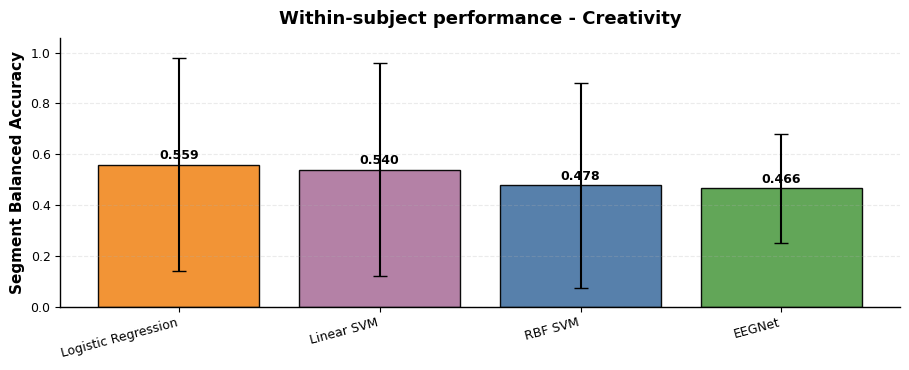

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/within_creativity_segment_bal_acc_pretty.png


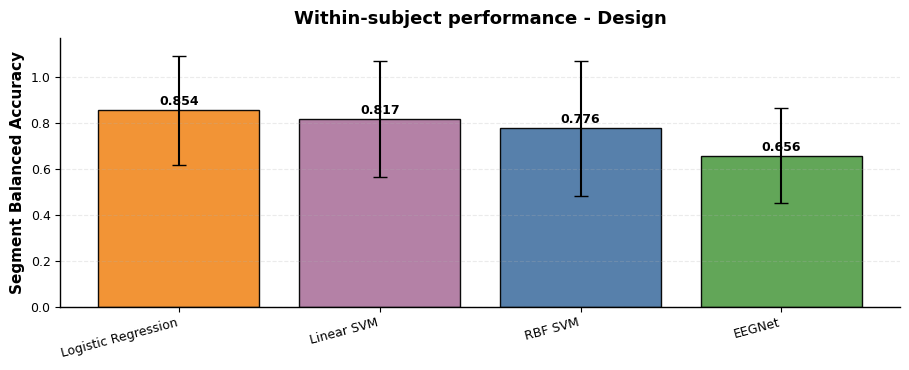

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/within_design_segment_bal_acc_pretty.png


In [103]:
# ============================================================
# Cell 78: Figure - Within-subject comparison
# Compact style + one different color per model
# ============================================================

for dataset_name in sorted(table_within_df["Dataset"].unique()):
    sub = table_within_df[table_within_df["Dataset"] == dataset_name].copy()

    plot_pretty_bar_chart(
        df=sub,
        category_col="Model",
        value_col="Segment Balanced Accuracy",
        std_col="STD",
        title=f"Within-subject performance - {dataset_name}",
        fig_path=FIGURES_DIR / f"within_{dataset_name.lower()}_segment_bal_acc_pretty.png",
        rotate=15,
    )

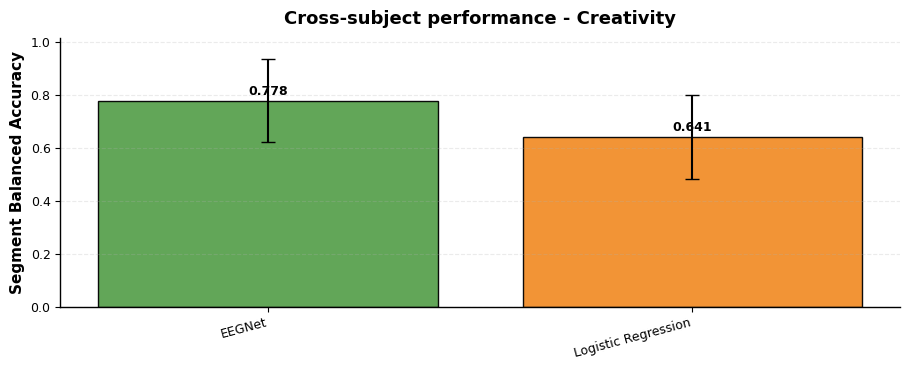

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/cross_creativity_segment_bal_acc_pretty.png


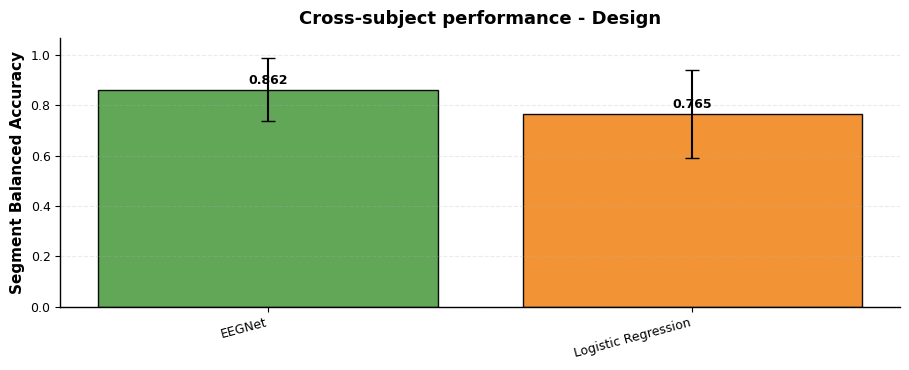

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/cross_design_segment_bal_acc_pretty.png


In [104]:
# ============================================================
# Cell 79: Figure - Cross-subject comparison
# Compact style + one different color per model
# ============================================================

for dataset_name in sorted(table_cross_df["Dataset"].unique()):
    sub = table_cross_df[table_cross_df["Dataset"] == dataset_name].copy()

    plot_pretty_bar_chart(
        df=sub,
        category_col="Model",
        value_col="Segment Balanced Accuracy",
        std_col="STD",
        title=f"Cross-subject performance - {dataset_name}",
        fig_path=FIGURES_DIR / f"cross_{dataset_name.lower()}_segment_bal_acc_pretty.png",
        rotate=15,
    )

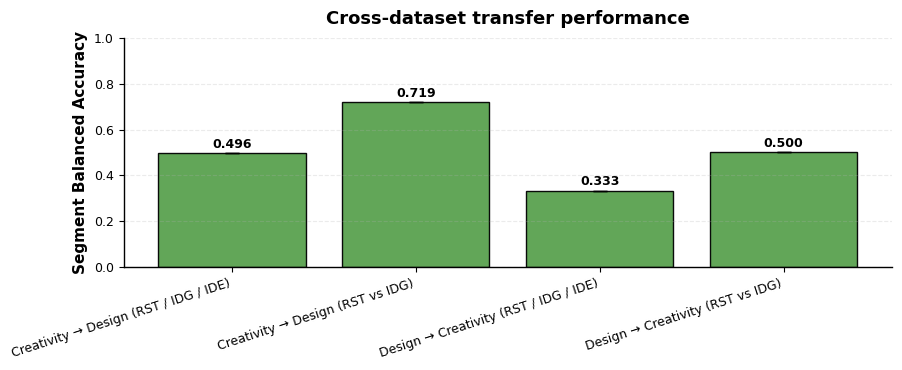

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/cross_dataset_transfer_segment_bal_acc_pretty.png


In [105]:
# ============================================================
# Cell 80: Figure - Cross-dataset transfer
# Compact style
# ============================================================

plot_df = table_transfer_df.copy()

plot_df["Label"] = (
    plot_df["Train Dataset"] + " → " +
    plot_df["Test Dataset"] + " (" +
    plot_df["Task"] + ")"
)

plot_pretty_bar_chart(
    df=plot_df,
    category_col="Label",
    value_col="Segment Balanced Accuracy",
    std_col="STD",
    title="Cross-dataset transfer performance",
    fig_path=FIGURES_DIR / "cross_dataset_transfer_segment_bal_acc_pretty.png",
    rotate=18,
)

In [106]:
# ============================================================
# Cell 81: Print exact report-ready tables
# ============================================================

print("\n=== TABLE 1: WITHIN-SUBJECT RESULTS (SEGMENT LEVEL) ===")
display(table_within_df)

print("\n=== TABLE 2: CROSS-SUBJECT RESULTS (SEGMENT LEVEL) ===")
display(table_cross_df)

print("\n=== TABLE 3: CROSS-DATASET TRANSFER RESULTS (SEGMENT LEVEL) ===")
display(table_transfer_df)

print("\n=== BEST MODEL SUMMARY (SEGMENT LEVEL) ===")
display(best_summary_df)


=== TABLE 1: WITHIN-SUBJECT RESULTS (SEGMENT LEVEL) ===


,Dataset,Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,n_folds,n_test_segments,n_test_subjects,Experiment
0,Creativity,Logistic Regression,0.5595,0.4189,0.5089,0.5130,140.0,224,28.0,creativity_within_logreg
1,Creativity,Linear SVM,0.5397,0.4198,0.4866,0.4715,140.0,224,28.0,creativity_within_linear_svm
2,Creativity,RBF SVM,0.4782,0.4037,0.4286,0.3888,140.0,224,28.0,creativity_within_rbf_svm
3,Creativity,EEGNet,0.4663,0.2145,0.4688,0.4601,56.0,224,NaN,creativity_within_eegnet
4,Design,Logistic Regression,0.8539,0.2361,0.8492,0.8680,135.0,378,27.0,design_within_logreg
5,Design,Linear SVM,0.8169,0.2532,0.8069,0.8327,135.0,378,27.0,design_within_linear_svm
6,Design,RBF SVM,0.7757,0.2941,0.7646,0.7945,135.0,378,27.0,design_within_rbf_svm
7,Design,EEGNet,0.6564,0.2071,0.7328,0.6712,54.0,378,NaN,design_within_eegnet



=== TABLE 2: CROSS-SUBJECT RESULTS (SEGMENT LEVEL) ===


,Dataset,Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,n_folds,n_test_segments,n_test_subjects,Experiment
0,Creativity,EEGNet,0.7778,0.1571,0.7545,0.7763,28.0,224,28.0,creativity_cross_eegnet
1,Creativity,Logistic Regression,0.6409,0.1596,0.5982,0.5542,28.0,224,28.0,creativity_cross_logreg
2,Design,EEGNet,0.8621,0.1255,0.8386,0.8451,27.0,378,27.0,design_cross_eegnet
3,Design,Logistic Regression,0.7654,0.1732,0.7196,0.7713,27.0,378,27.0,design_cross_logreg



=== TABLE 3: CROSS-DATASET TRANSFER RESULTS (SEGMENT LEVEL) ===


,Train Dataset,Test Dataset,Task,Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,n_folds,n_test_segments,n_test_subjects,Experiment
0,Creativity,Design,RST / IDG / IDE,EEGNet,0.4959,NaN,0.5159,0.4903,NaN,378,27.0,creativity_to_design_eegnet
1,Creativity,Design,RST vs IDG,EEGNet,0.7191,NaN,0.8009,0.7259,NaN,216,27.0,creativity_to_design_rest_ig_eegnet
2,Design,Creativity,RST / IDG / IDE,EEGNet,0.3333,NaN,0.2500,0.1333,NaN,224,28.0,design_to_creativity_eegnet
3,Design,Creativity,RST vs IDG,EEGNet,0.5000,NaN,0.4000,0.2857,NaN,140,28.0,design_to_creativity_rest_ig_eegnet



=== BEST MODEL SUMMARY (SEGMENT LEVEL) ===


,Setting,Dataset,Best Model,Segment Balanced Accuracy,STD,Segment Accuracy,Segment Macro F1,Experiment
0,Within-subject,Creativity,Logistic Regression,0.5595,0.4189,0.5089,0.5130,creativity_within_logreg
1,Within-subject,Design,Logistic Regression,0.8539,0.2361,0.8492,0.8680,design_within_logreg
2,Cross-subject,Creativity,EEGNet,0.7778,0.1571,0.7545,0.7763,creativity_cross_eegnet
3,Cross-subject,Design,EEGNet,0.8621,0.1255,0.8386,0.8451,design_cross_eegnet



=== BEST CONFUSION MATRIX: Creativity | Within-subject ===
Experiment: creativity_within_logreg
Model     : Logistic Regression


/tmp/ipykernel_1788/3163327212.py:308: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return mpl_cm.get_cmap(cmap_name)


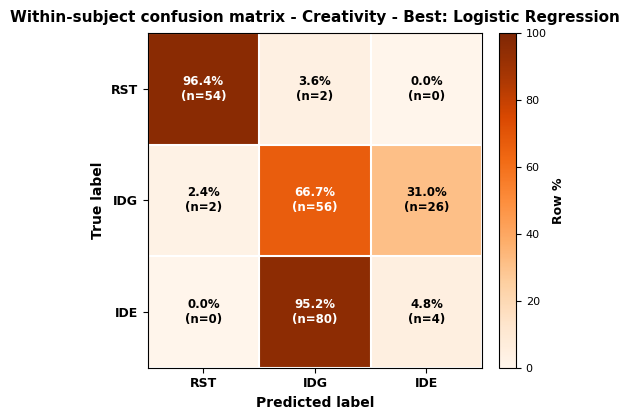

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/creativity_within_subject_best_confusion_matrix_creativity_within_logreg.png
Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/creativity_within_subject_best_confusion_matrix_creativity_within_logreg.csv


,RST,IDG,IDE
RST,54 (96.4%),2 (3.6%),0 (0.0%)
IDG,2 (2.4%),56 (66.7%),26 (31.0%)
IDE,0 (0.0%),80 (95.2%),4 (4.8%)



=== BEST CONFUSION MATRIX: Design | Within-subject ===
Experiment: design_within_logreg
Model     : Logistic Regression


/tmp/ipykernel_1788/3163327212.py:308: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return mpl_cm.get_cmap(cmap_name)


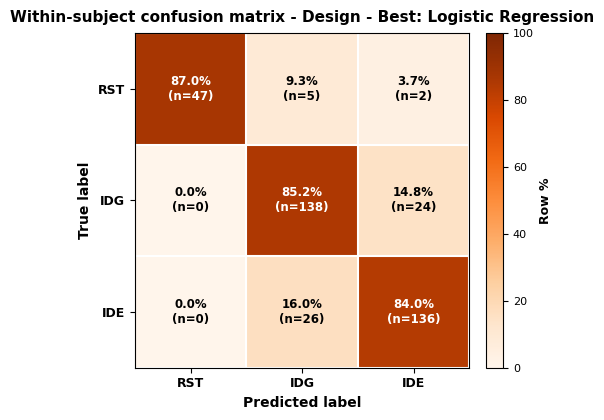

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/design_within_subject_best_confusion_matrix_design_within_logreg.png
Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/design_within_subject_best_confusion_matrix_design_within_logreg.csv


,RST,IDG,IDE
RST,47 (87.0%),5 (9.3%),2 (3.7%)
IDG,0 (0.0%),138 (85.2%),24 (14.8%)
IDE,0 (0.0%),26 (16.0%),136 (84.0%)



=== BEST CONFUSION MATRIX: Creativity | Cross-subject ===
Experiment: creativity_cross_eegnet
Model     : EEGNet


/tmp/ipykernel_1788/3163327212.py:308: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return mpl_cm.get_cmap(cmap_name)


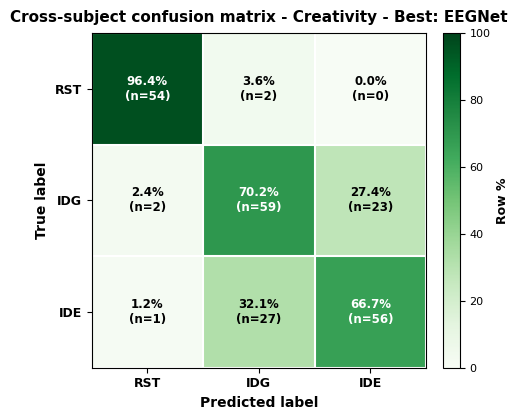

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/creativity_cross_subject_best_confusion_matrix_creativity_cross_eegnet.png
Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/creativity_cross_subject_best_confusion_matrix_creativity_cross_eegnet.csv


,RST,IDG,IDE
RST,54 (96.4%),2 (3.6%),0 (0.0%)
IDG,2 (2.4%),59 (70.2%),23 (27.4%)
IDE,1 (1.2%),27 (32.1%),56 (66.7%)



=== BEST CONFUSION MATRIX: Design | Cross-subject ===
Experiment: design_cross_eegnet
Model     : EEGNet


/tmp/ipykernel_1788/3163327212.py:308: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return mpl_cm.get_cmap(cmap_name)


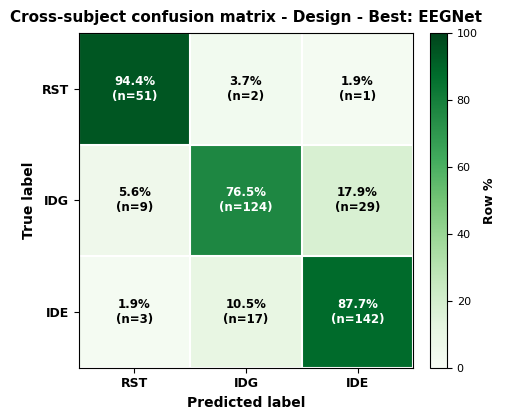

Saved: /content/drive/MyDrive/EEG_ML_Final_Project/figures/design_cross_subject_best_confusion_matrix_design_cross_eegnet.png
Saved: /content/drive/MyDrive/EEG_ML_Final_Project/summary/design_cross_subject_best_confusion_matrix_design_cross_eegnet.csv


,RST,IDG,IDE
RST,51 (94.4%),2 (3.7%),1 (1.9%)
IDG,9 (5.6%),124 (76.5%),29 (17.9%)
IDE,3 (1.9%),17 (10.5%),142 (87.7%)


In [107]:
# ============================================================
# New cell: Best confusion matrix per dataset and setting
# ============================================================

def export_best_confusion_per_dataset(table_df, setting_name, title_prefix):
    if len(table_df) == 0:
        print(f"No rows found for {setting_name}")
        return

    for dataset_name in sorted(table_df["Dataset"].dropna().unique()):
        sub = table_df[table_df["Dataset"] == dataset_name].copy()

        if len(sub) == 0:
            continue

        best_row = sub.sort_values(
            by=["Segment Balanced Accuracy", "Segment Accuracy", "Segment Macro F1"],
            ascending=[False, False, False]
        ).iloc[0]

        best_exp = best_row["Experiment"]
        best_model = best_row["Model"]
        best_result = loaded_results[best_exp]
        best_cm = best_result["confusion_matrix"]

        print(f"\n=== BEST CONFUSION MATRIX: {dataset_name} | {setting_name} ===")
        print("Experiment:", best_exp)
        print("Model     :", best_model)

        safe_dataset = dataset_name.lower().replace(" ", "_")
        safe_setting = setting_name.lower().replace(" ", "_").replace("-", "_")

        fig_path = FIGURES_DIR / f"{safe_dataset}_{safe_setting}_best_confusion_matrix_{best_exp}.png"
        csv_path = SUMMARY_DIR / f"{safe_dataset}_{safe_setting}_best_confusion_matrix_{best_exp}.csv"

        plot_confusion_matrix_with_percentages(
            exp_name=best_exp,
            cm=best_cm,
            title=f"{title_prefix} - {dataset_name} - Best: {best_model}",
            fig_path=fig_path,
            csv_path=csv_path,
        )


# ------------------------------------------------------------
# Best per dataset for within-subject
# ------------------------------------------------------------
export_best_confusion_per_dataset(
    table_df=table_within_df,
    setting_name="Within-subject",
    title_prefix="Within-subject confusion matrix"
)

# ------------------------------------------------------------
# Best per dataset for cross-subject
# ------------------------------------------------------------
export_best_confusion_per_dataset(
    table_df=table_cross_df,
    setting_name="Cross-subject",
    title_prefix="Cross-subject confusion matrix"
)